# [LAB-06] 캡스톤 (1) - MPG 데이터셋 (ADsP 기출)

1. 각 문제의 질문을 읽고, **어떤 그래프가 답을 찾기에 적절한지 스스로 판단**하여 직접 시각화하세요.
2. 그래프를 보고 객관식 보기 중 정답을 고르세요.

## 준비작업

### 1. 라이브러리 참조

In [146]:
from jussam import load_data
from helpers import my_plot, my_qtcheck
from pandas import pivot_table
import numpy as np
import seaborn as sb
from matplotlib import pyplot as plt 


### 2. 데이터셋 불러오기

In [147]:
origin = load_data("mpg")
origin.head()

📚 1999년과 2008년에 미국 EPA에서 조사하여 발표한 자동차 주요 모델별 연비 데이터 (출처: ADsP 기출 / R 내장 데이터)

    field         description
--  ------------  -------------------------------------------------------------
 0  manufacturer  자동차 제조사 (문자열)
 1  model         자동차 모델명 (문자열)
 2  displ         자동차 배기량 (연속형)
 3  year          제조년도 (연속형)
 4  cyl           엔진 실린더 수 (범주형)
 5  trans         자동차 트랜스미션 종류 (범주형)
 6  drv           자동차 구동 방식 (범주형). f=전륜구동, r=후륜구동, 4=사륜구동
 7  cty           도심 연비 (마일/갤론)
 8  hwy           고속도로 연비 (마일/갤론)
 9  fl            연료 종류 (범주형)
10  class         자동차 분류 (범주형)



,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
id,,,,,,,,,,,
1,audi,a4,1.800,1999,4,auto(l5),f,18,29,p,compact
2,audi,a4,1.800,1999,4,manual(m5),f,21,29,p,compact
3,audi,a4,2.000,2008,4,manual(m6),f,20,31,p,compact
4,audi,a4,2.000,2008,4,auto(av),f,21,30,p,compact
5,audi,a4,2.800,1999,6,auto(l5),f,16,26,p,compact


In [148]:
origin.info()

<class 'pandas.DataFrame'>
RangeIndex: 234 entries, 1 to 234
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   manufacturer  234 non-null    str    
 1   model         234 non-null    str    
 2   displ         234 non-null    float64
 3   year          234 non-null    int64  
 4   cyl           234 non-null    int64  
 5   trans         234 non-null    str    
 6   drv           234 non-null    str    
 7   cty           234 non-null    int64  
 8   hwy           234 non-null    int64  
 9   fl            234 non-null    str    
 10  class         234 non-null    str    
dtypes: float64(1), int64(4), str(6)
memory usage: 27.9 KB


### 3. 데이터 전처리

- 구동방식 컬럼 값을 이해하기 쉬운 값으로 변환

In [149]:
df = origin.copy()
df["drv"] = df["drv"].map({"f": "전륜구동", "r": "후륜구동", "4": "4륜구동"})
df.head()

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
id,,,,,,,,,,,
1,audi,a4,1.800,1999,4,auto(l5),전륜구동,18,29,p,compact
2,audi,a4,1.800,1999,4,manual(m5),전륜구동,21,29,p,compact
3,audi,a4,2.000,2008,4,manual(m6),전륜구동,20,31,p,compact
4,audi,a4,2.000,2008,4,auto(av),전륜구동,21,30,p,compact
5,audi,a4,2.800,1999,6,auto(l5),전륜구동,16,26,p,compact


## 문제 1. 출시 차량 수가 가장 많은 제조사는?

① audi  ② dodge  ③ toyota  ④ volkswagen

> 💡 **힌트**: 막대그래프 (제조사별 빈도)

- 내 답 : dodge

In [150]:
# 응, 맞아. 막대그래프가 맞는 선택이야.
# 이유는 데이터 성격 때문이야.
# 제조사(manufacturer)는 범주형 데이터야. dodge, toyota, audi... 이런 카테고리들 사이에는 순서나 연속적인 흐름이 없어. "dodge 다음이 toyota"라는 게 의미 있는 순서가 아니라 그냥 정렬 방식(빈도순, 알파벳순 등)에 따라 바뀌는 거지.
# 선그래프(lineplot)가 어울리는 경우:

# x축이 연속형이거나 시간/순서 개념이 있을 때
# 예: 연도별 평균 연비 추이, 배기량에 따른 연비 변화
# 점과 점 사이를 선으로 잇는 게 "변화의 흐름"을 의미할 때 자연스러움

# 막대그래프(barplot/countplot)가 어울리는 경우:

# x축이 범주형일 때 (제조사, 연료 종류, 구동방식 등)
# 각 카테고리가 독립적이고, 카테고리 간 크기 비교가 목적일 때
# 지금처럼 "제조사별 몇 대씩 있나"를 비교하는 상황

# 지금 문제(제조사별 차량 수 비교)는 딱 두 번째 케이스니까:
# pythonsns.countplot(data=df, x='manufacturer', 
#               order=df['manufacturer'].value_counts().index)
# plt.xticks(rotation=45)
# plt.show()
# 이게 제일 적합한 선택이야. lineplot으로 억지로 그려도 되긴 하지만, 제조사 사이를 선으로 잇는 순간 "마치 연속적인 변화가 있는 것처럼" 보이는 착시를 줄 수 있어서 통계적으로는 오해의 소지가 있어. 이런 뉘앙스는 ADsP나 실무에서도 종종 물어보는 포인트니까 기억해두면 좋아.

In [151]:
# 제조사로 묶고, 
# 행이 몇개 있는지 세서, 차량 수가 몇개인지 알면 되나? 

In [152]:
order = df["manufacturer"].value_counts().sort_values(ascending=False)
order

manufacturer
dodge         37
toyota        34
volkswagen    27
ford          25
chevrolet     19
audi          18
hyundai       14
subaru        14
nissan        13
honda          9
jeep           8
pontiac        5
land rover     4
mercury        4
lincoln        3
Name: count, dtype: int64

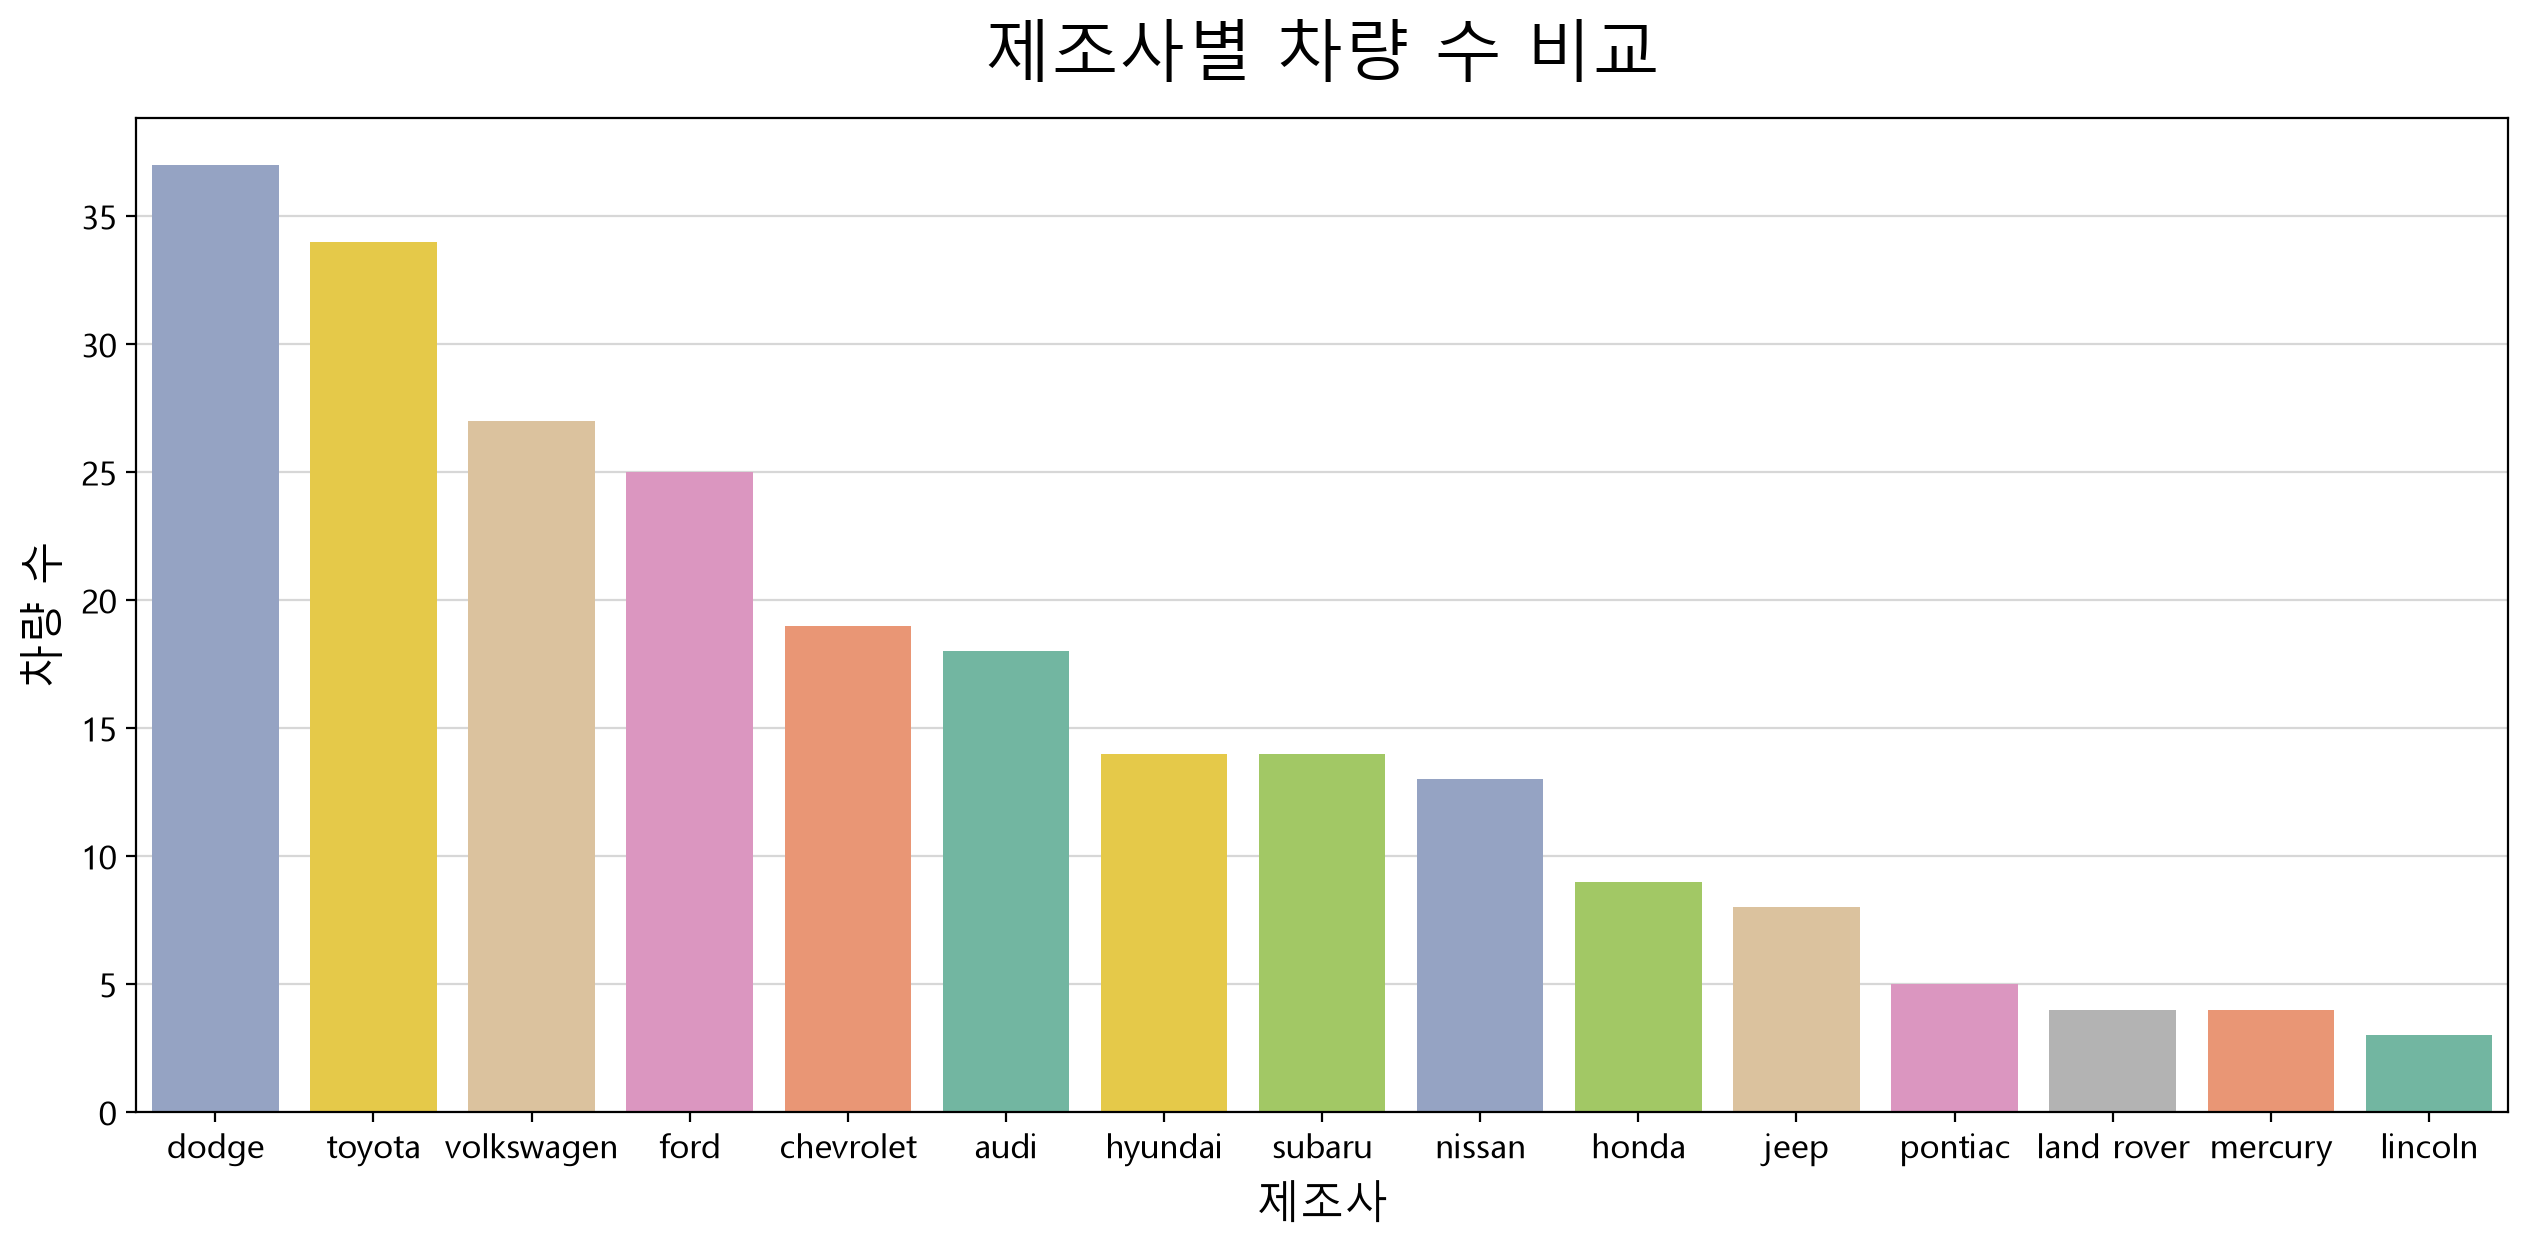

In [153]:
my_plot.countplot(data=df, x="manufacturer", order=order.index,
                  hue="manufacturer", palette="Set2", 
                  title="제조사별 차량 수 비교", xlabel="제조사", ylabel="차량 수")

## 문제 2. 차종(`class`) 중 가장 많은 비중을 차지하는 종류는?

① compact  ② midsize  ③ suv  ④ pickup

> 💡 **힌트**: 막대그래프 또는 원그래프 (차종별 빈도)

- 내 답 : suv

In [154]:
# 판단 기준
# **"이 값, 이 셀 말고 다른 데서도 또 쓸까?"**를 스스로 물어보시면 돼요.

# 또 쓸 것 같다 → 변수로 담아두기 (counts = ...)
# 이번 셀 한 번뿐이다 → 인라인으로 바로 써도 무방

In [155]:
# 제조사 별로 차종을 보려는건가? 
# 차종만 보려는건가? 

In [156]:
counts = df["class"].value_counts()
counts

class
suv           62
compact       47
midsize       41
subcompact    35
pickup        33
minivan       11
2seater        5
Name: count, dtype: int64

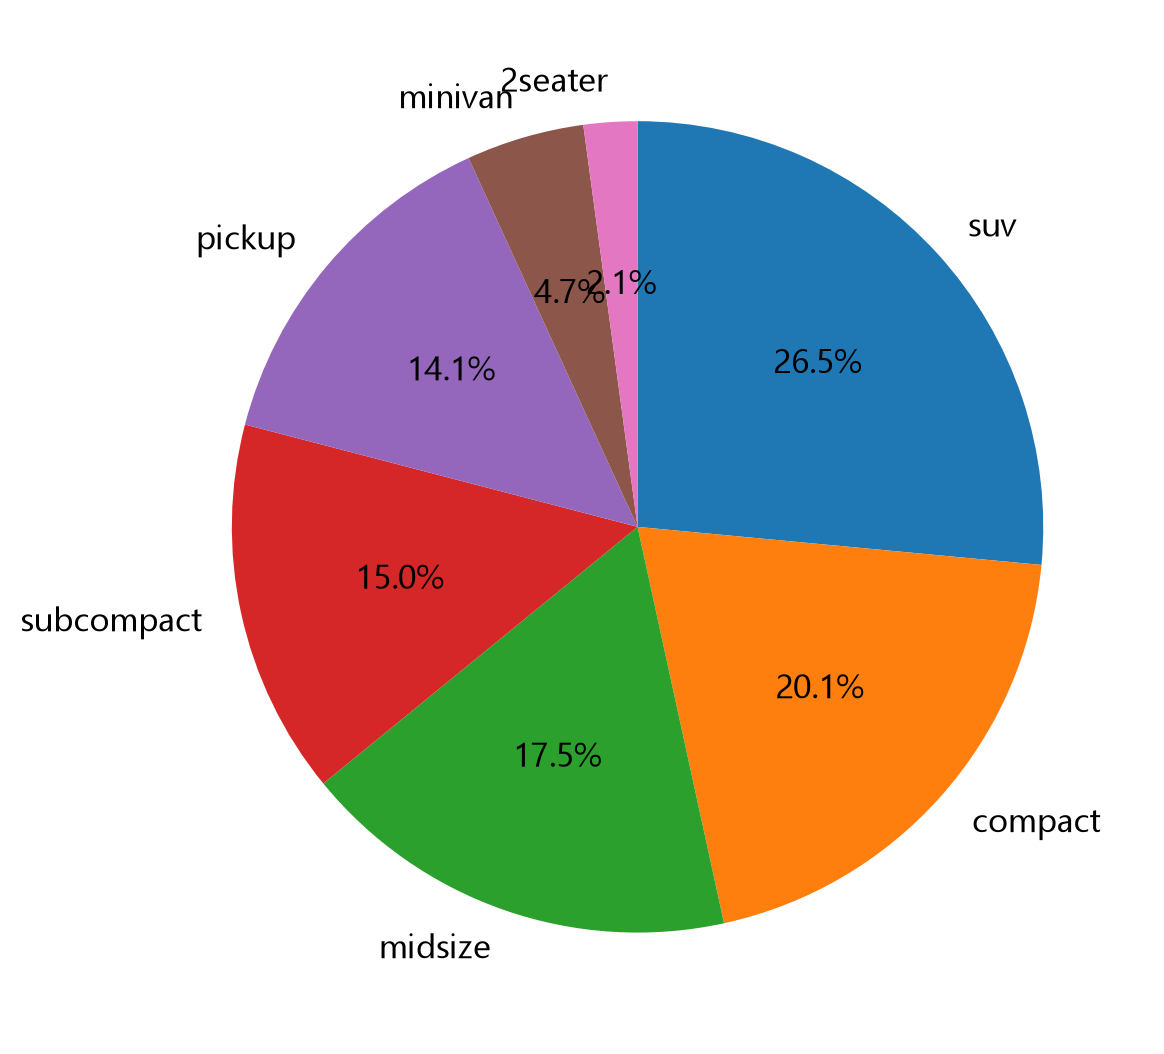

In [157]:
my_plot.pieplot(x=counts.values, labels=counts.index,
                width=600, height=600)

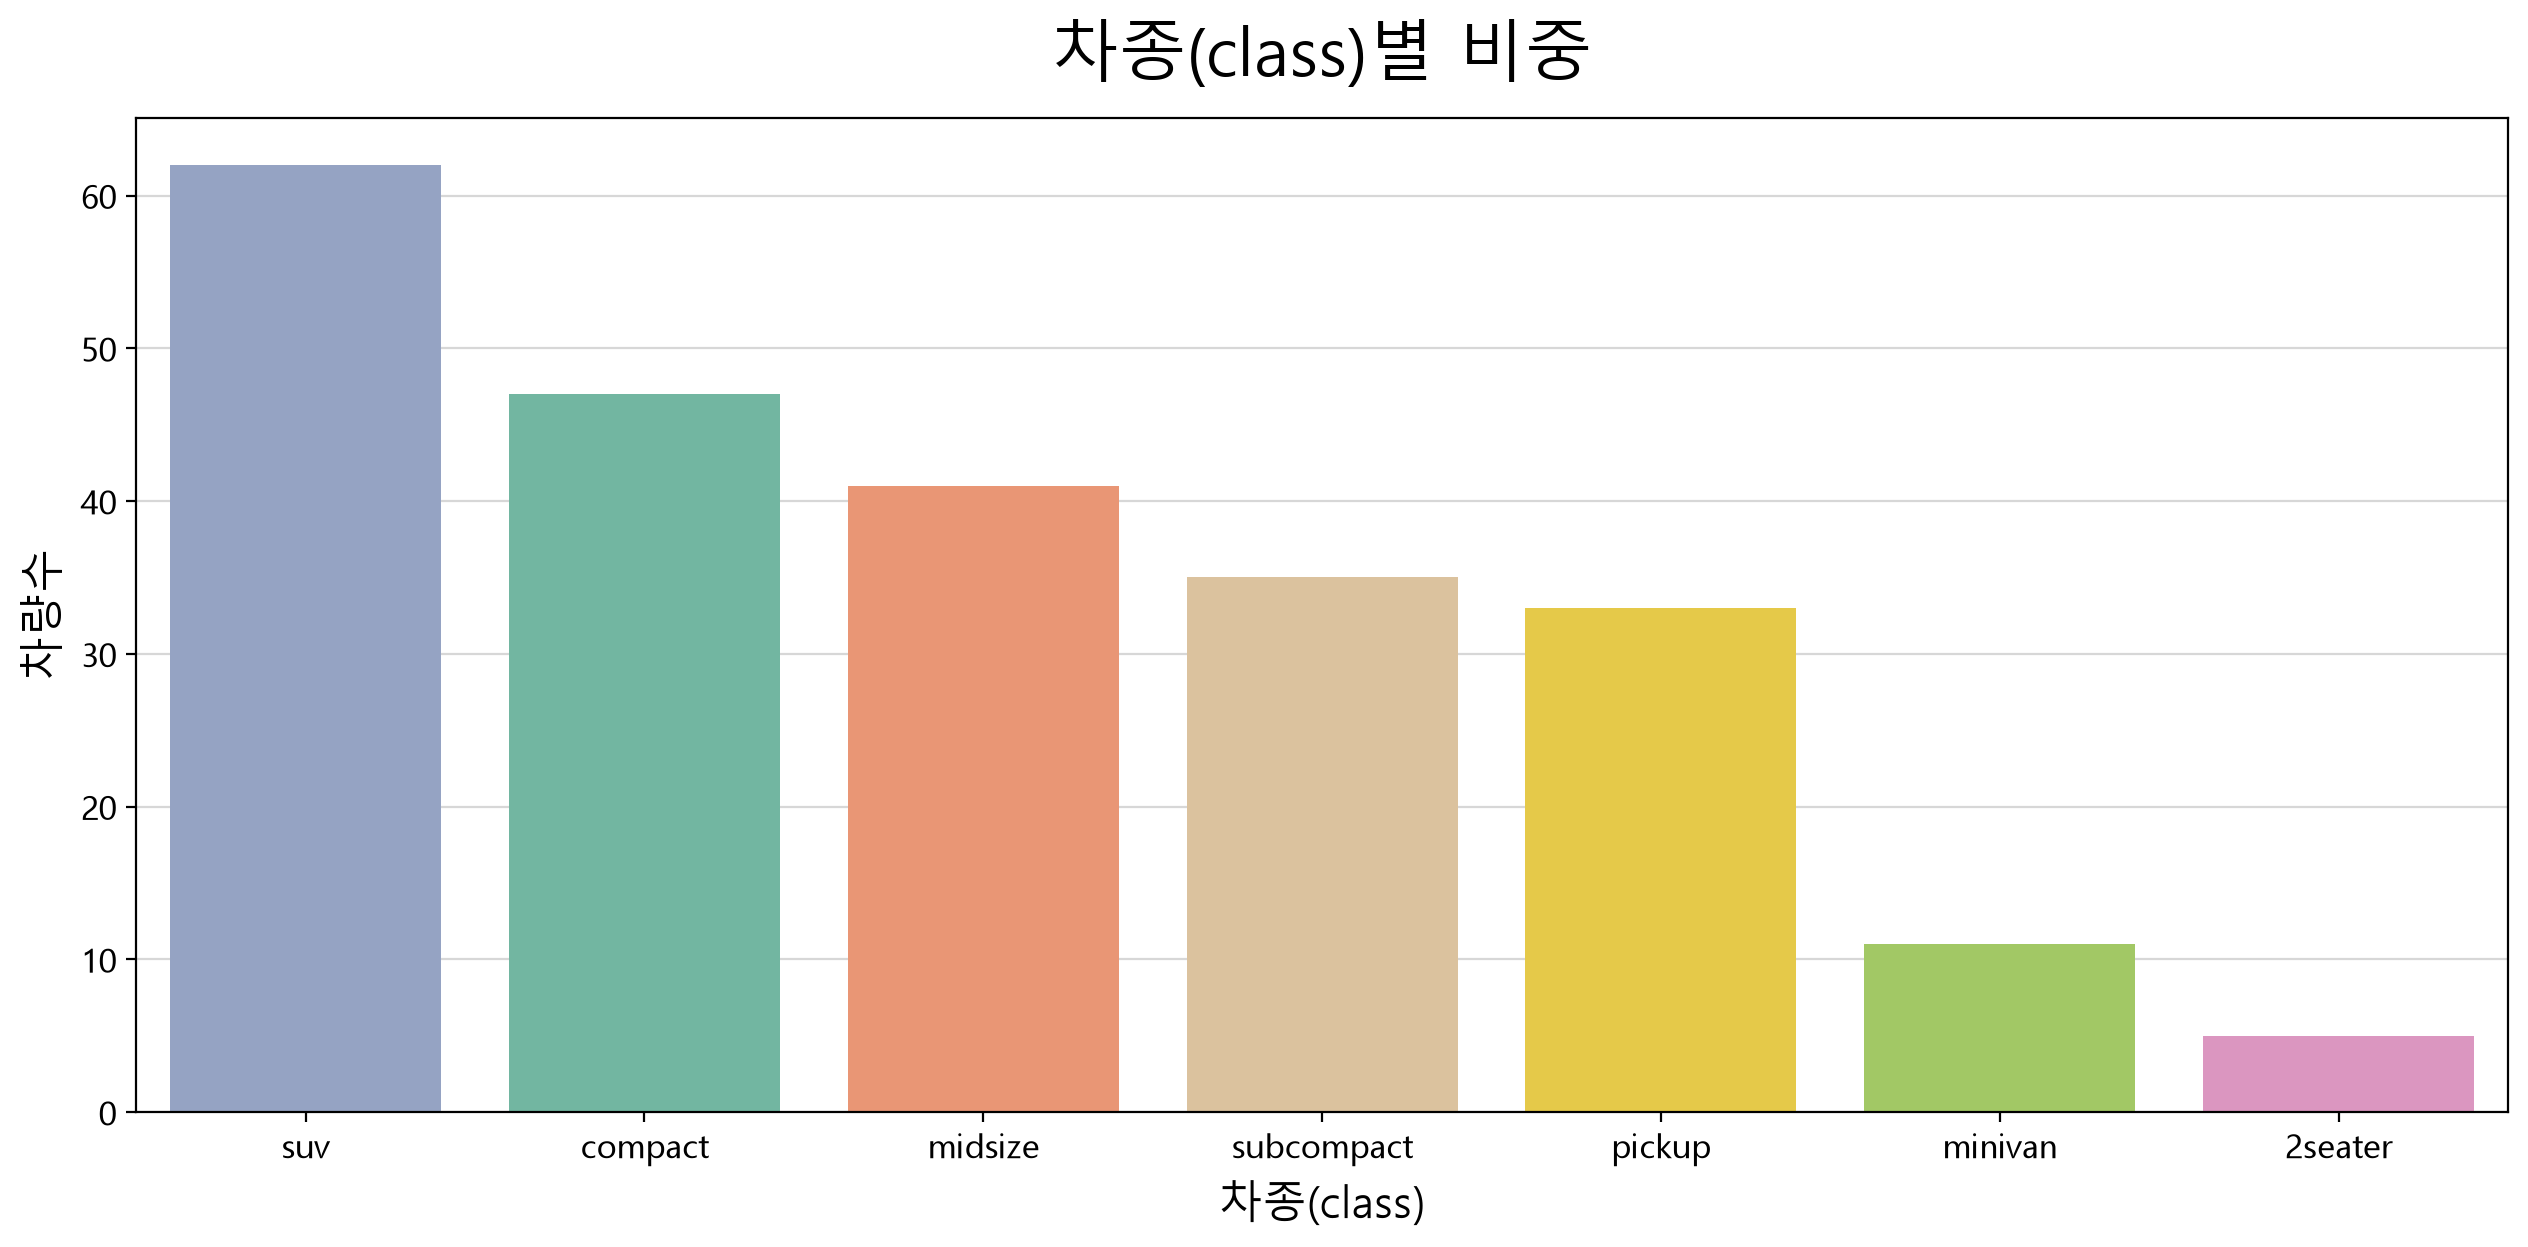

In [158]:
my_plot.countplot(data=df, x='class', hue='class', 
                  order=counts.index, palette="Set2", 
                  title="차종(class)별 비중", xlabel="차종(class)", 
                  ylabel="차량수")

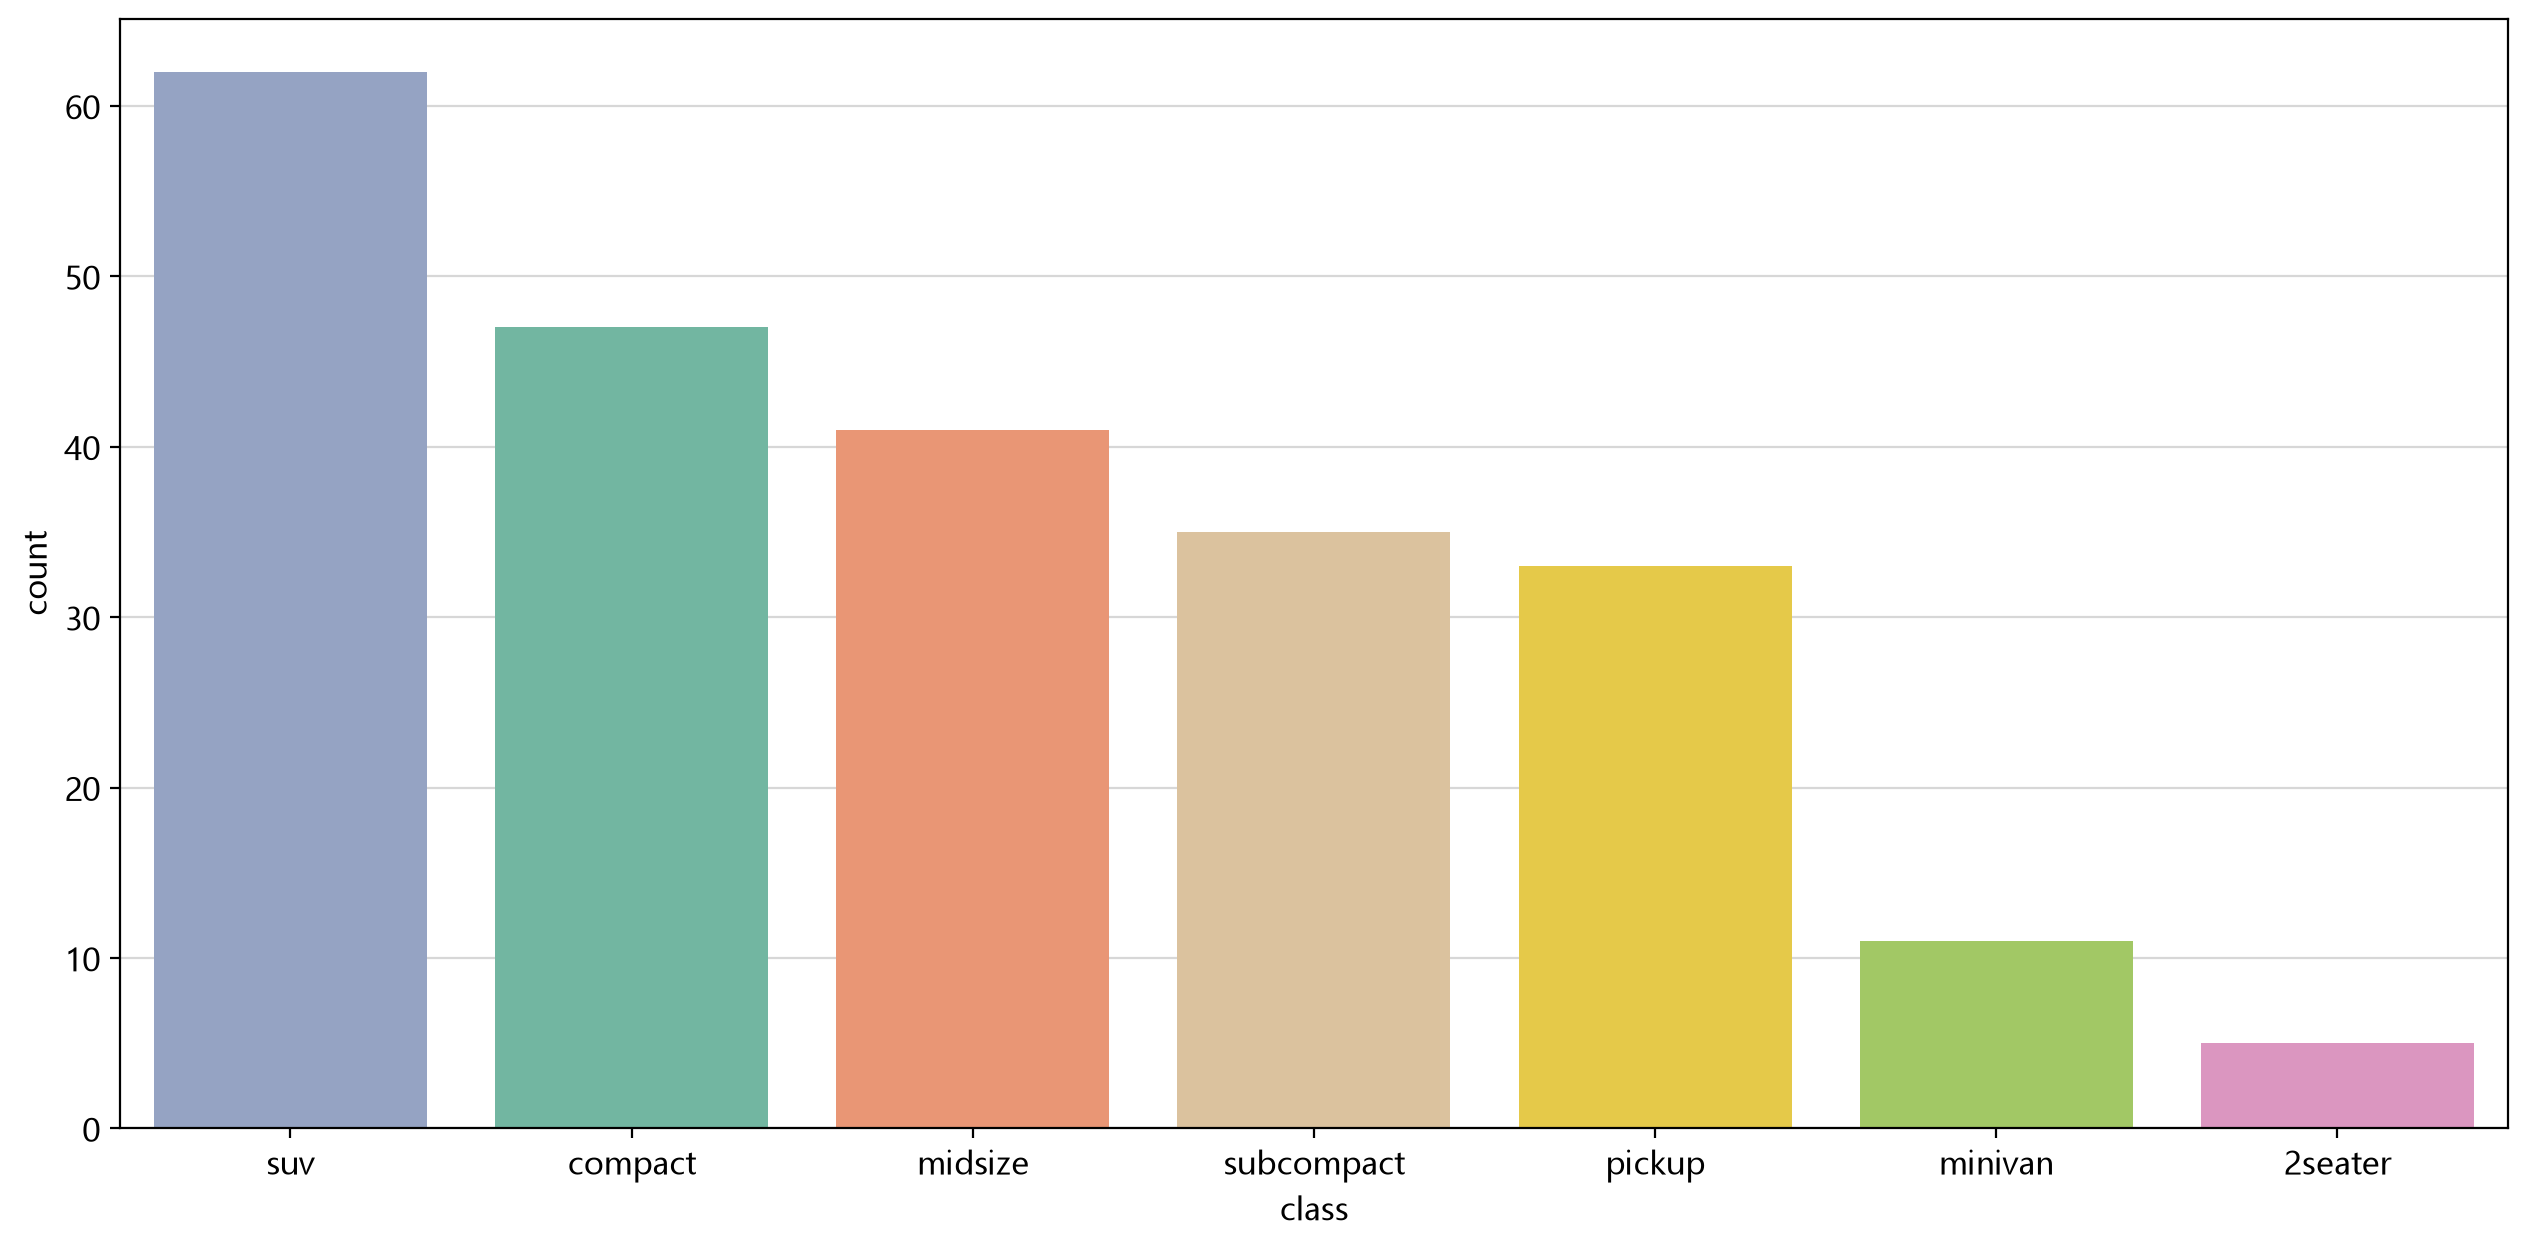

In [159]:
my_plot.countplot(data=df, x="class", hue="class", palette="Set2",
                order=df['class'].value_counts().index # 내림차순으로 보고 싶을때
                  )

## 문제 3. 구동방식(`drv`) 중 차량 수가 가장 적은 방식은?

① 전륜구동  ② 4륜구동  ③ 후륜구동  ④ 모두 동일

> 💡 **힌트**: 막대그래프 (구동방식별 빈도)

In [160]:
# 왜 이 문제는 order가 필요한가
# 3번 문제는 "가장 적은 방식"을 찾는 문제예요. order 없이 그냥 countplot을 그리면 x축 순서가 데이터에 등장하는 순서 혹은 알파벳/카테고리 순으로 나와요. 그러면:

# 막대 3개가 뒤죽박죽 순서로 나열됨
# "어느 게 제일 낮지?"를 눈으로 일일이 높이 비교해야 함

# 반면 order=df['drv'].value_counts().index를 넣으면 막대가 빈도 내림차순으로 정렬돼서, 그래프 맨 오른쪽 막대가 자동으로 "가장 적은 것"이 돼요. 즉 이 문제처럼 "최댓값/최솟값을 찾아라"는 유형에서는 order가 장식이 아니라 답을 빨리 읽어내기 위한 필수 장치예요.
# 판단 기준 (일반화)

# "가장 많은/적은 게 뭐야?"류 문제 → order 필수급. 정렬 안 하면 눈으로 비교하는 데 시간 걸리고 실수 위험도 커요 (9번 문제처럼 compact 28.30 vs subcompact 28.14, 근소한 차이면 정렬 안 하면 아예 순위 파악 자체가 어려워요).
# "경향/분포가 어떻게 생겼어?"류 문제 (예: displ 분포, 상관관계) → order가 딱히 의미 없거나 오히려 자연스러운 순서(숫자 오름차순 등)가 나을 수도 있어요.

- 내 답 : 후륜구동

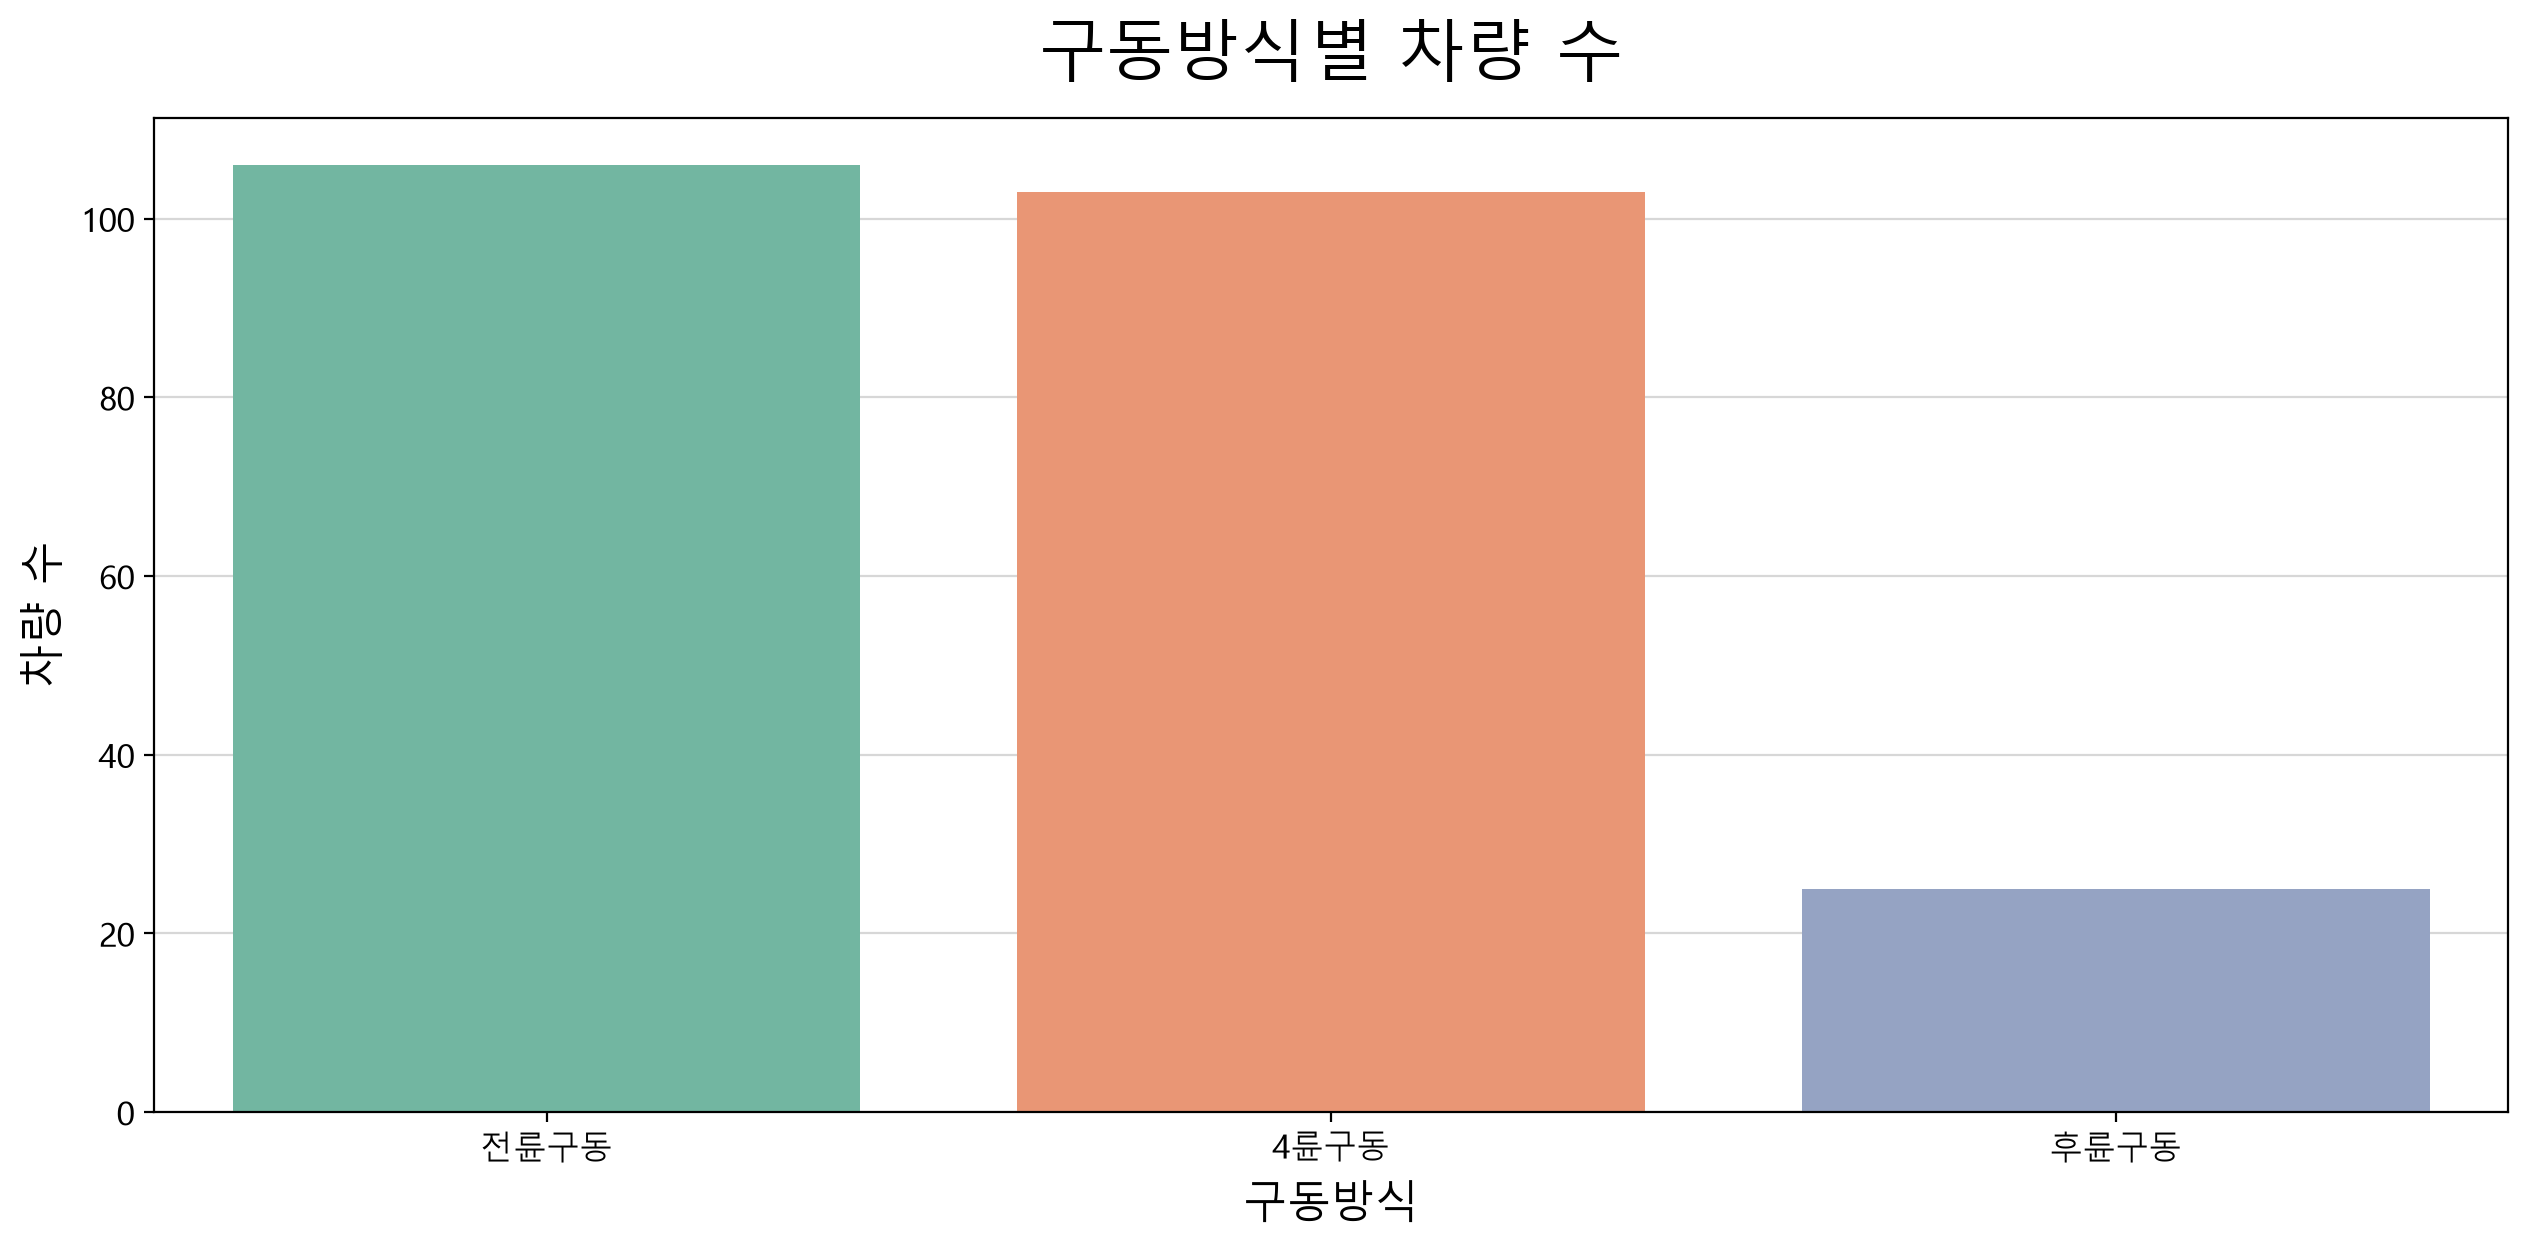

In [161]:
my_plot.countplot(data=df, x="drv", order=df['drv'].value_counts().index, 
                  hue="drv",palette="Set2", title="구동방식별 차량 수", xlabel="구동방식", ylabel="차량 수")

## 문제 4. 도심 연비(`cty`) 평균이 가장 높은 구동방식은?

① 전륜구동  ② 4륜구동  ③ 후륜구동  ④ 모두 비슷

> 💡 **힌트**: 막대그래프 (구동방식별 cty 평균)

- 내 답 : 전륜구동

In [162]:
help(my_plot.barplot)

Help on function barplot in module helpers.my_plot:

barplot(
    data=None,
    x=None,
    y=None,
    hue=None,
    estimator=<function mean at 0x000002927F51E770>,
    order=None,
    palette=None,
    title=None,
    xlabel=None,
    ylabel=None,
    width=1280,
    height=640,
    save_path=None,
    ax=None
)
    막대그래프를 그린다.

    Args:
        data : 시각화할 데이터 (2차원 배열 또는 DataFrame )
        x : x축 범주 컬럼명
        y : y축 값 컬럼명
        hue : 범주 구분 컬럼명
        estimator : 막대 높이 계산 함수 (기본값 : np.mean)
        order : 정렬순서를 의미하는 연속형 자료형
        palette : 색상 팔레트 이름
        title : 그래프 제목
        xlabel : x축 레이블
        ylabel : y축 레이블
        width : 캔버스 가로 픽셀
        height : 캔버스 세로 픽셀
        save_path : 이미지 저장 경로



In [163]:
import inspect
print(inspect.signature(my_plot.barplot))

(data=None, x=None, y=None, hue=None, estimator=<function mean at 0x000002927F51E770>, order=None, palette=None, title=None, xlabel=None, ylabel=None, width=1280, height=640, save_path=None, ax=None)


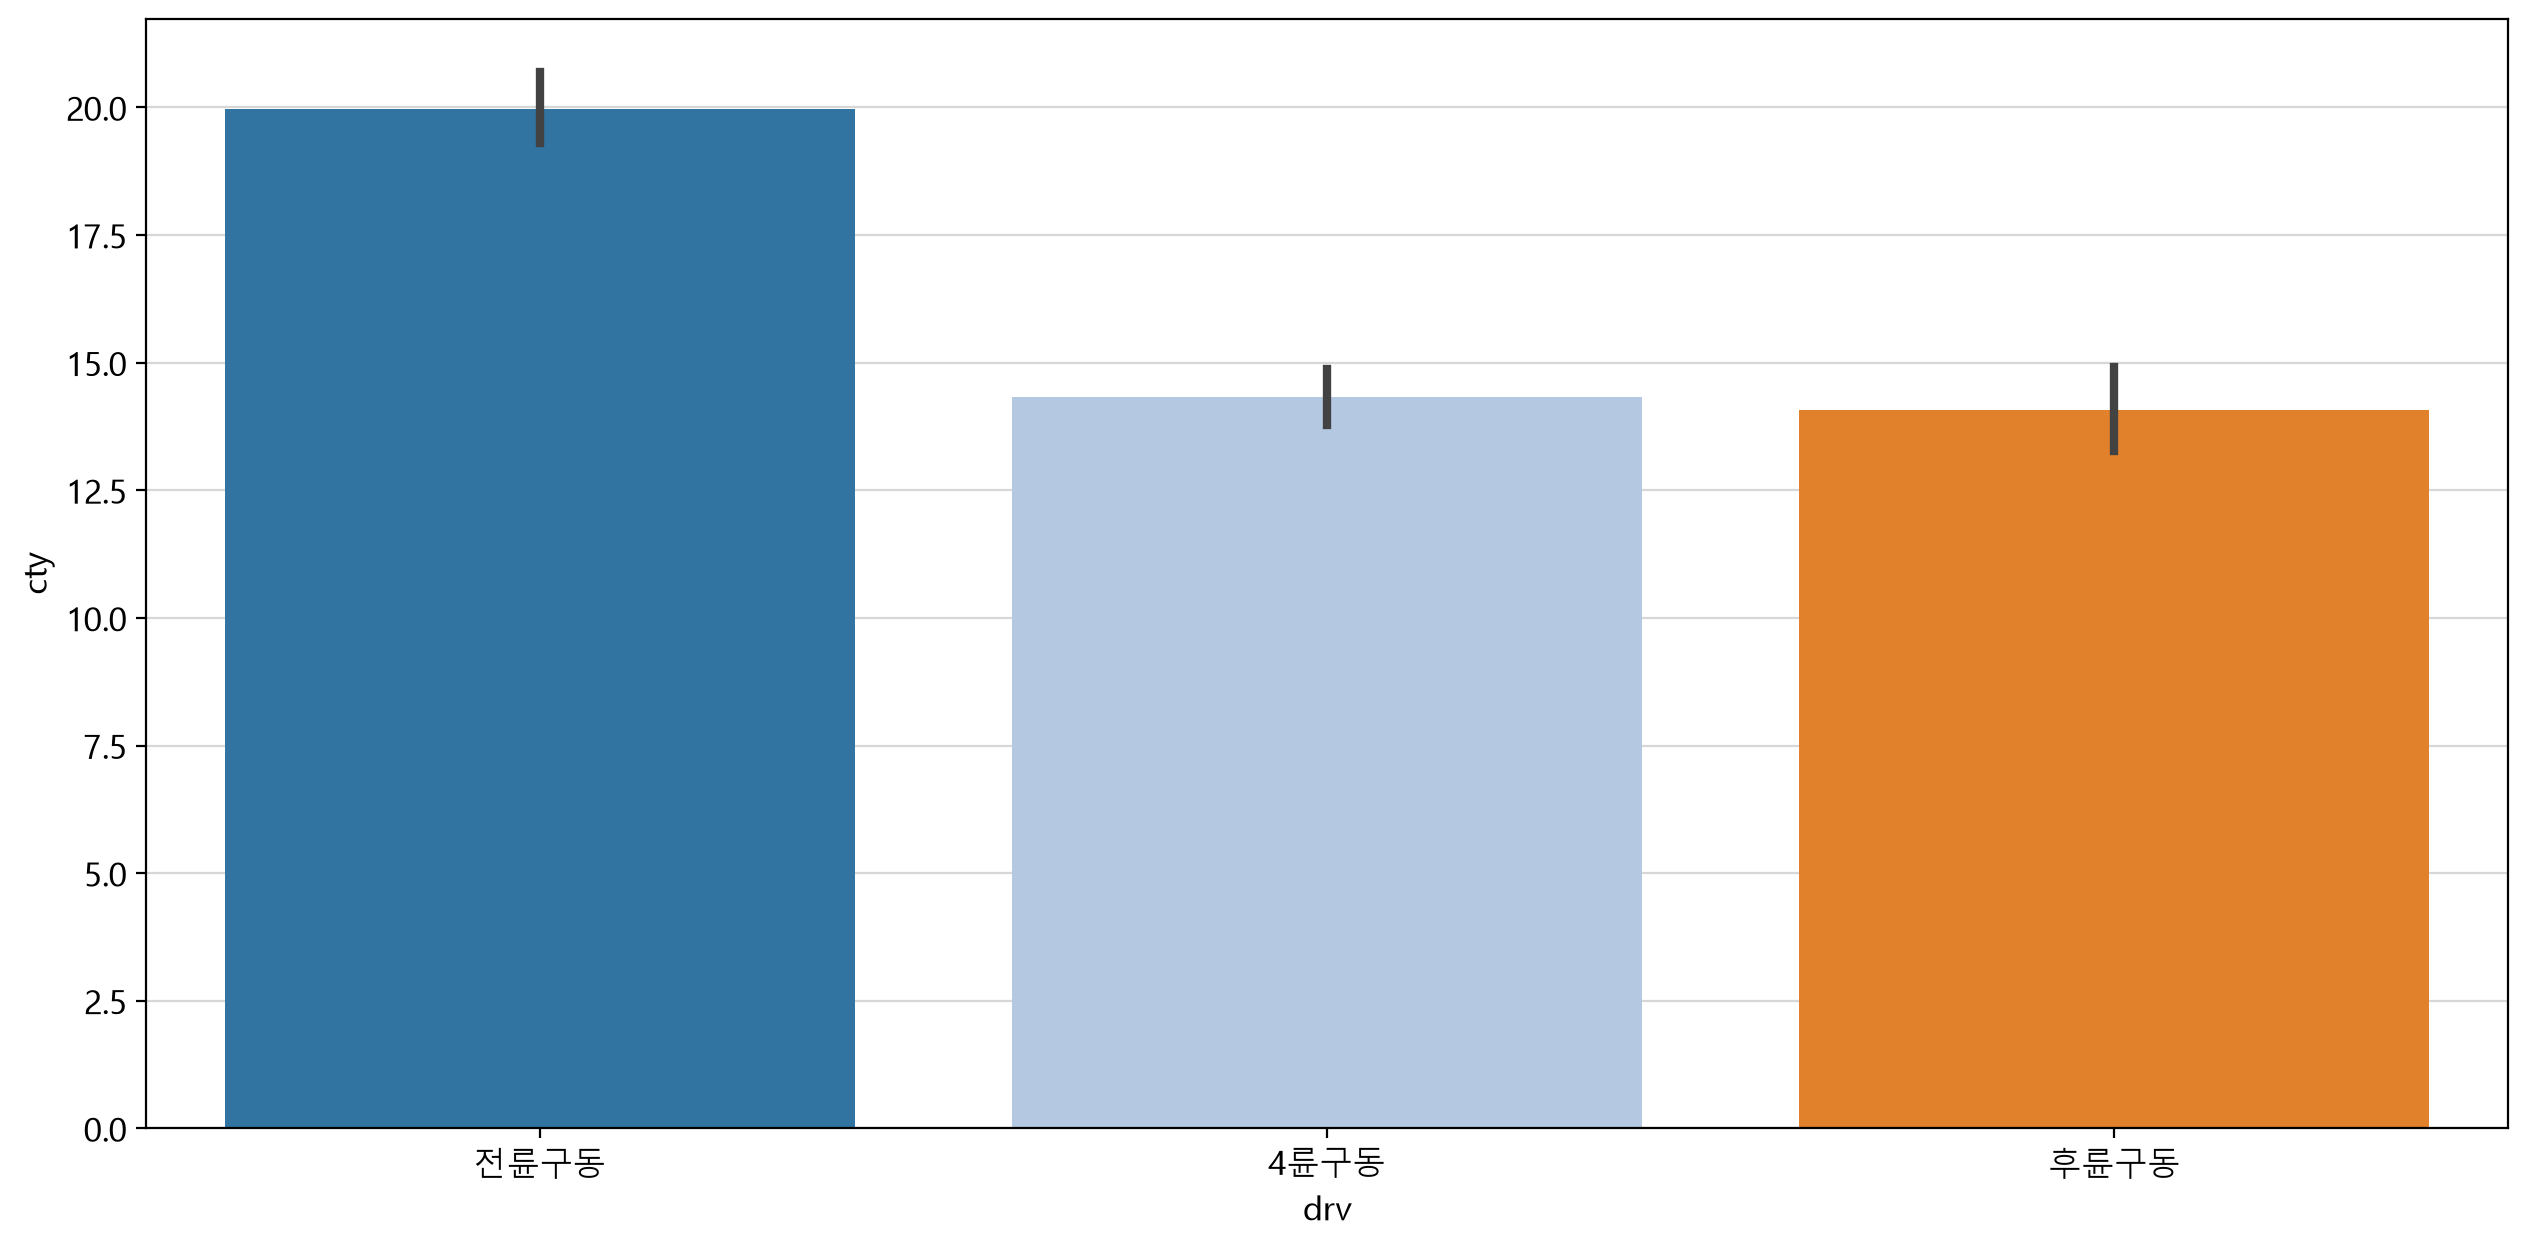

In [164]:
my_plot.barplot(data=df, x="drv", y='cty', estimator="mean", hue="drv", palette="tab20")

## 문제 5. 실린더 수(`cyl`)가 많아질수록 고속도로 연비(`hwy`)는 어떤 경향을 보이는가?

① 증가한다  ② 감소한다  ③ 관계가 없다  ④ U자 형태

> 💡 **힌트**: 막대그래프 (실린더 수별 hwy 평균)

- 내 답 : 감소한다.

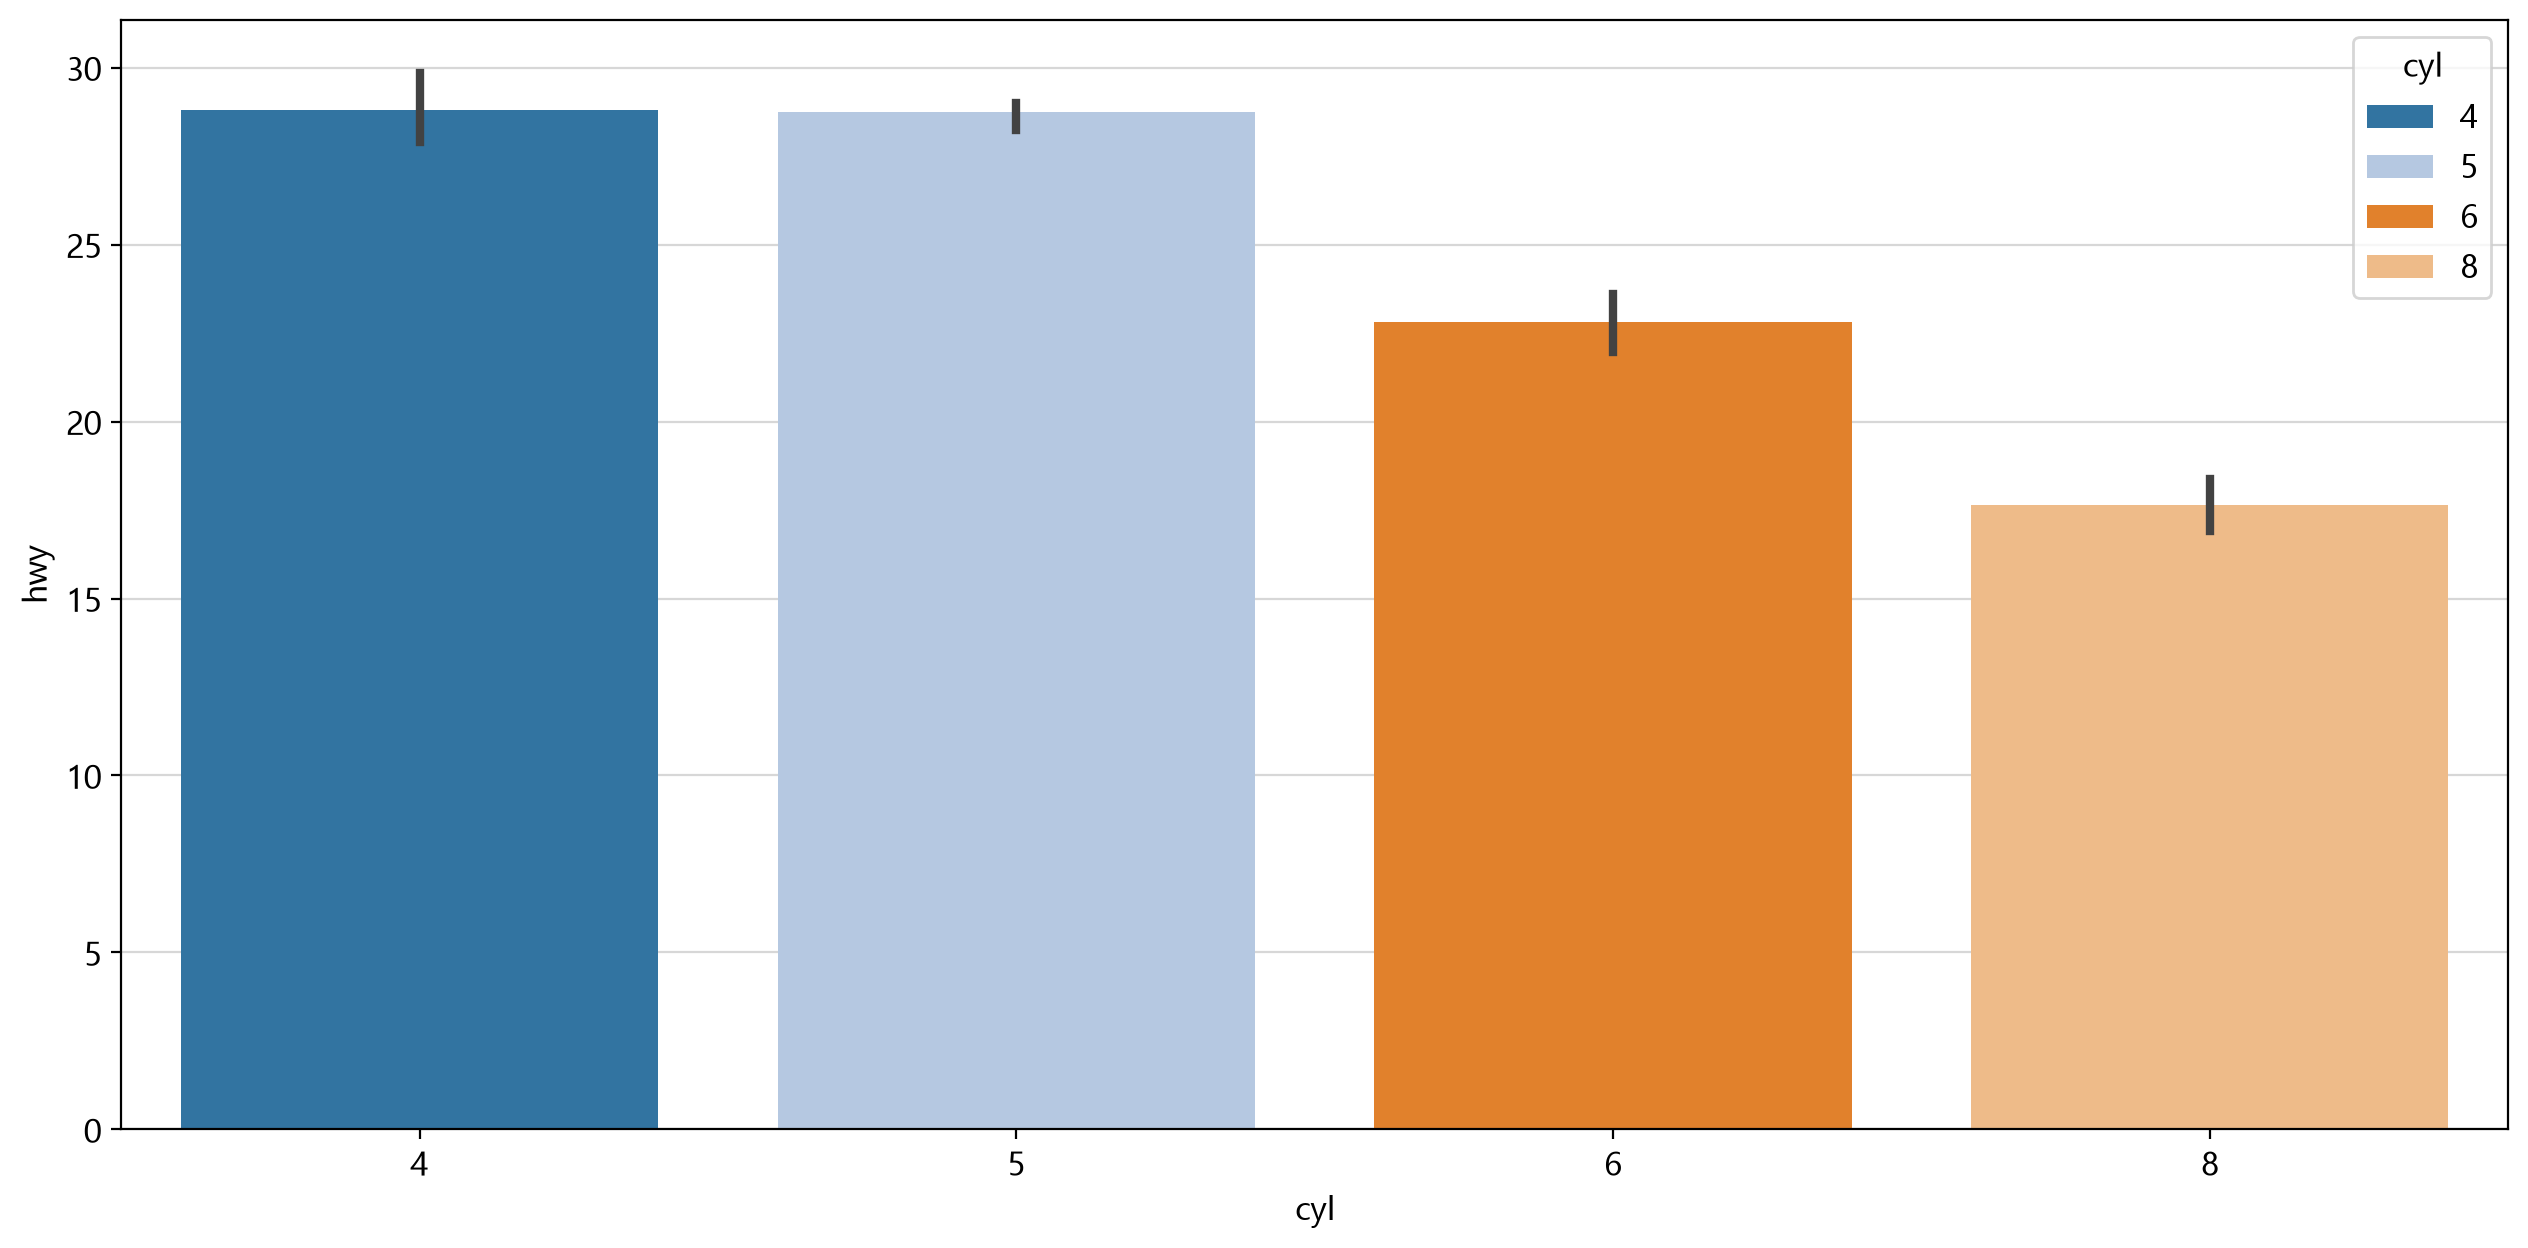

In [165]:
my_plot.barplot(data=df, x="cyl", y='hwy',estimator="mean", hue="cyl",palette="tab20")

## 문제 6. 배기량(`displ`)과 고속도로 연비(`hwy`)는 어떤 상관관계를 가지는가?

① 양(+)의 상관  ② 음(−)의 상관  ③ 상관 없음  ④ 곡선(2차) 관계

> 💡 **힌트**: 산점도 (+ 추세선)

- 내 답 : 음의 상관 

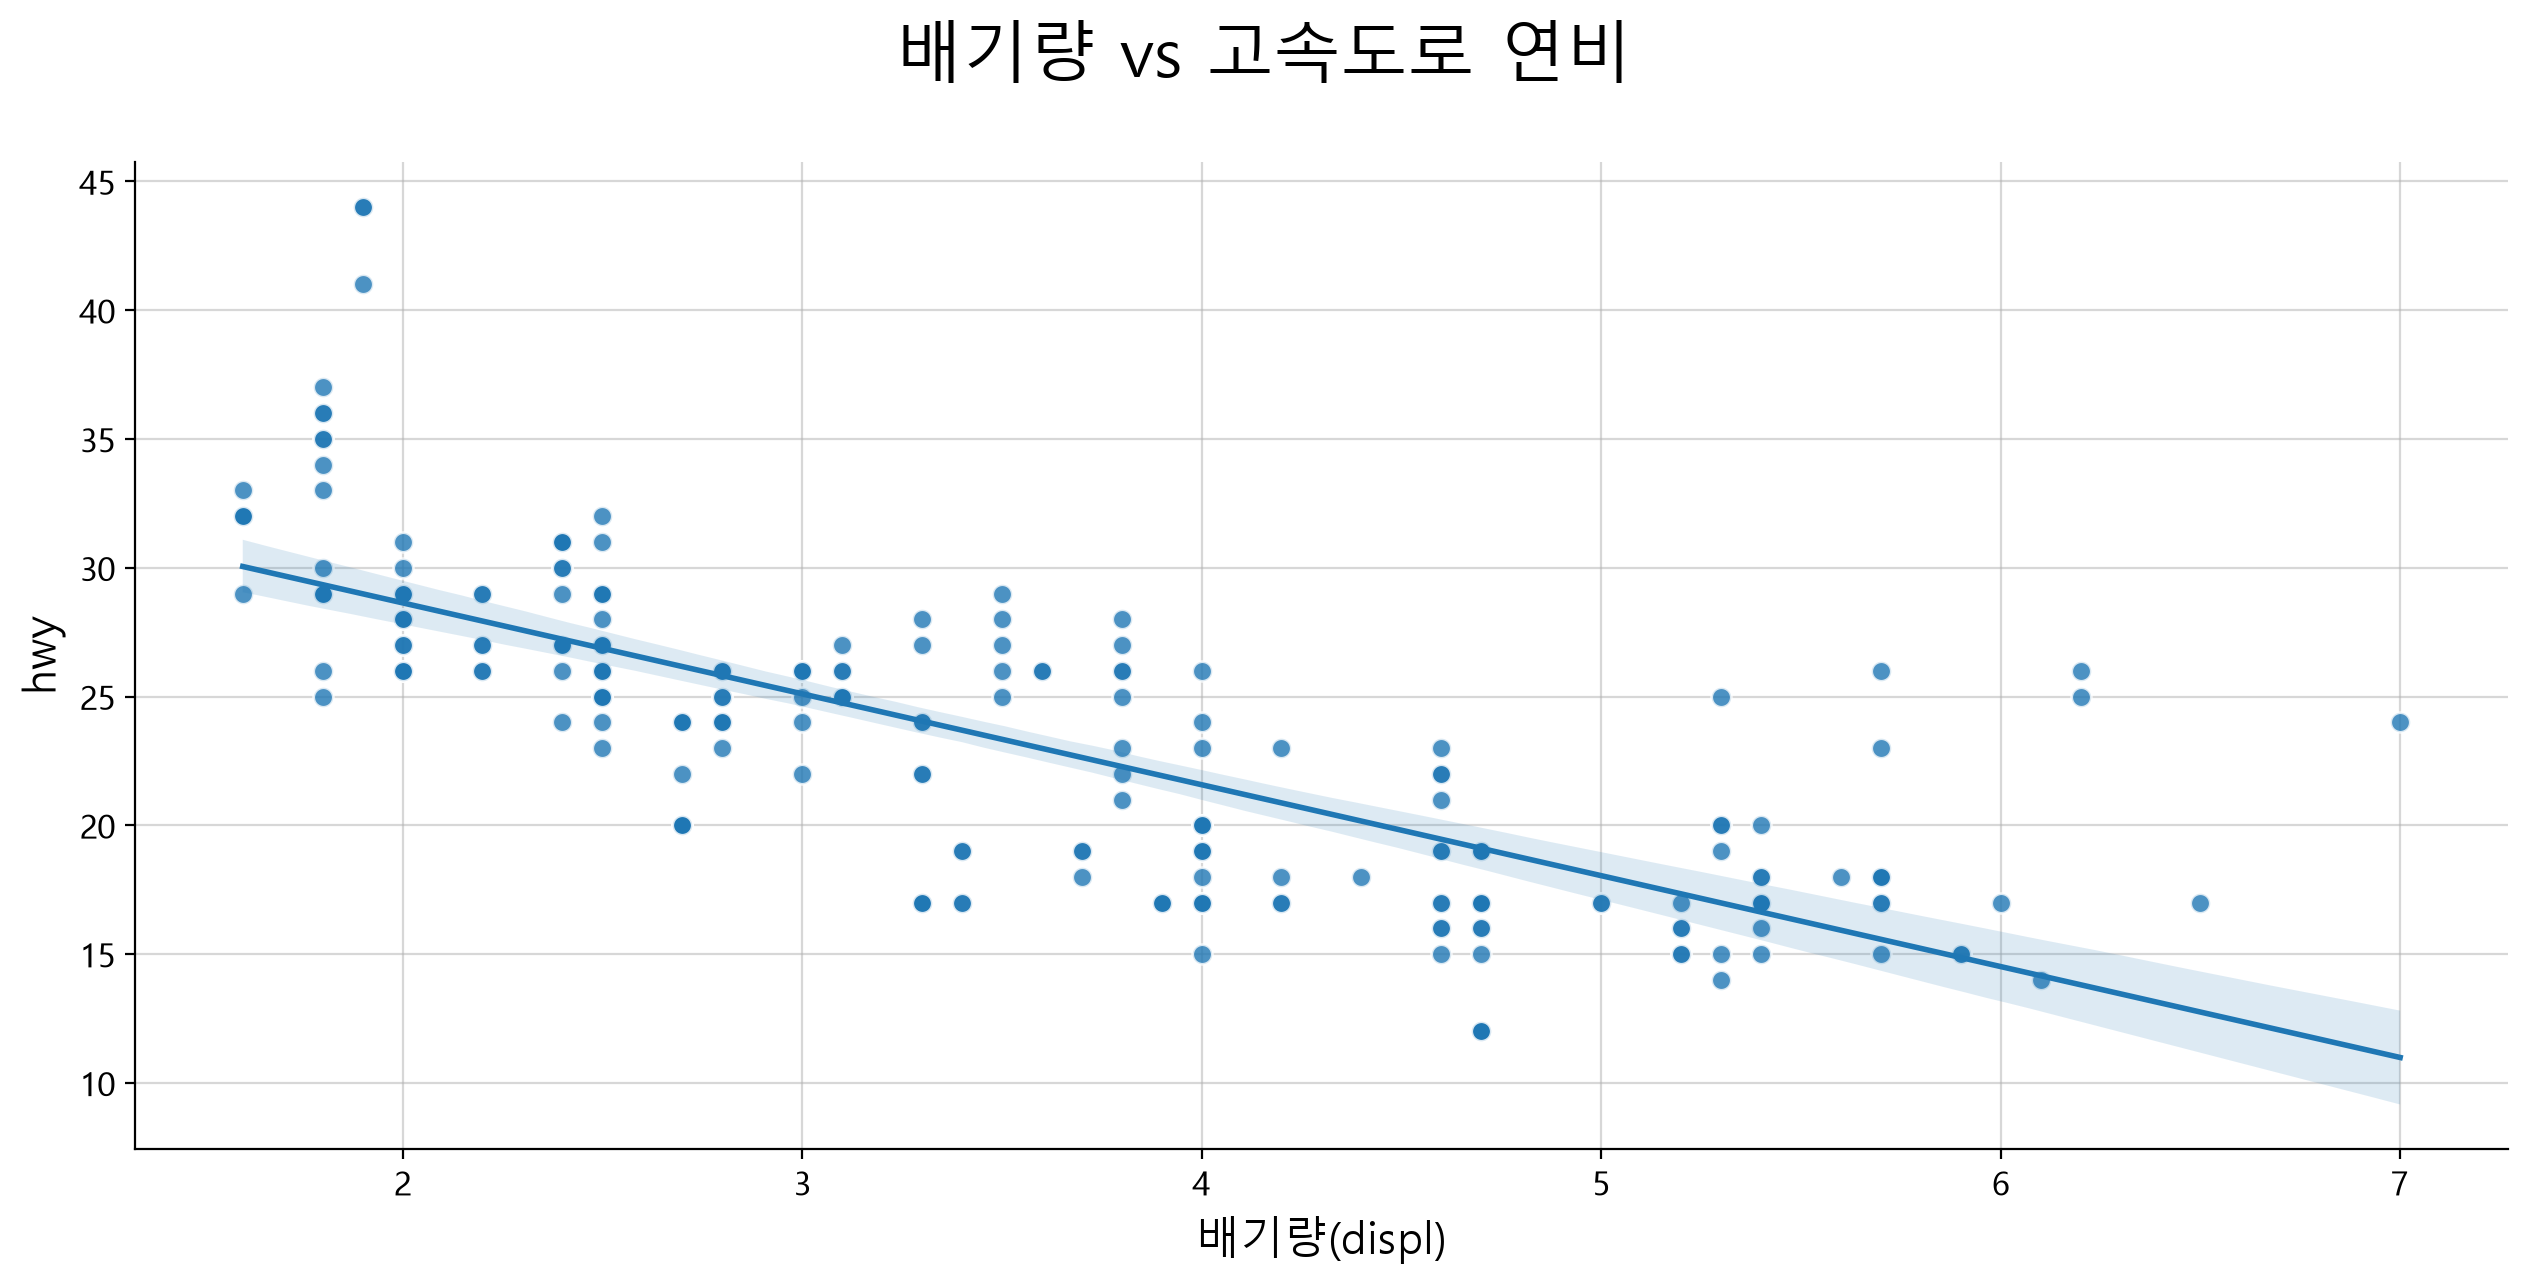

In [166]:
my_plot.lmplot(data=df, x='displ', y='hwy',
               title="배기량 vs 고속도로 연비", xlabel="배기량(displ)", ylabel="hwy")

## 문제 7. 배기량(`displ`)과 더 강한(추세션의 기울기가 큰) 상관관계를 가지는 연비는?

① 도심 연비(cty)  ② 고속도로 연비(hwy)  ③ 둘이 완전히 동일  ④ 둘 다 상관 없음

> 💡 **힌트**: 산점도 2개를 비교 (+ 추세선)

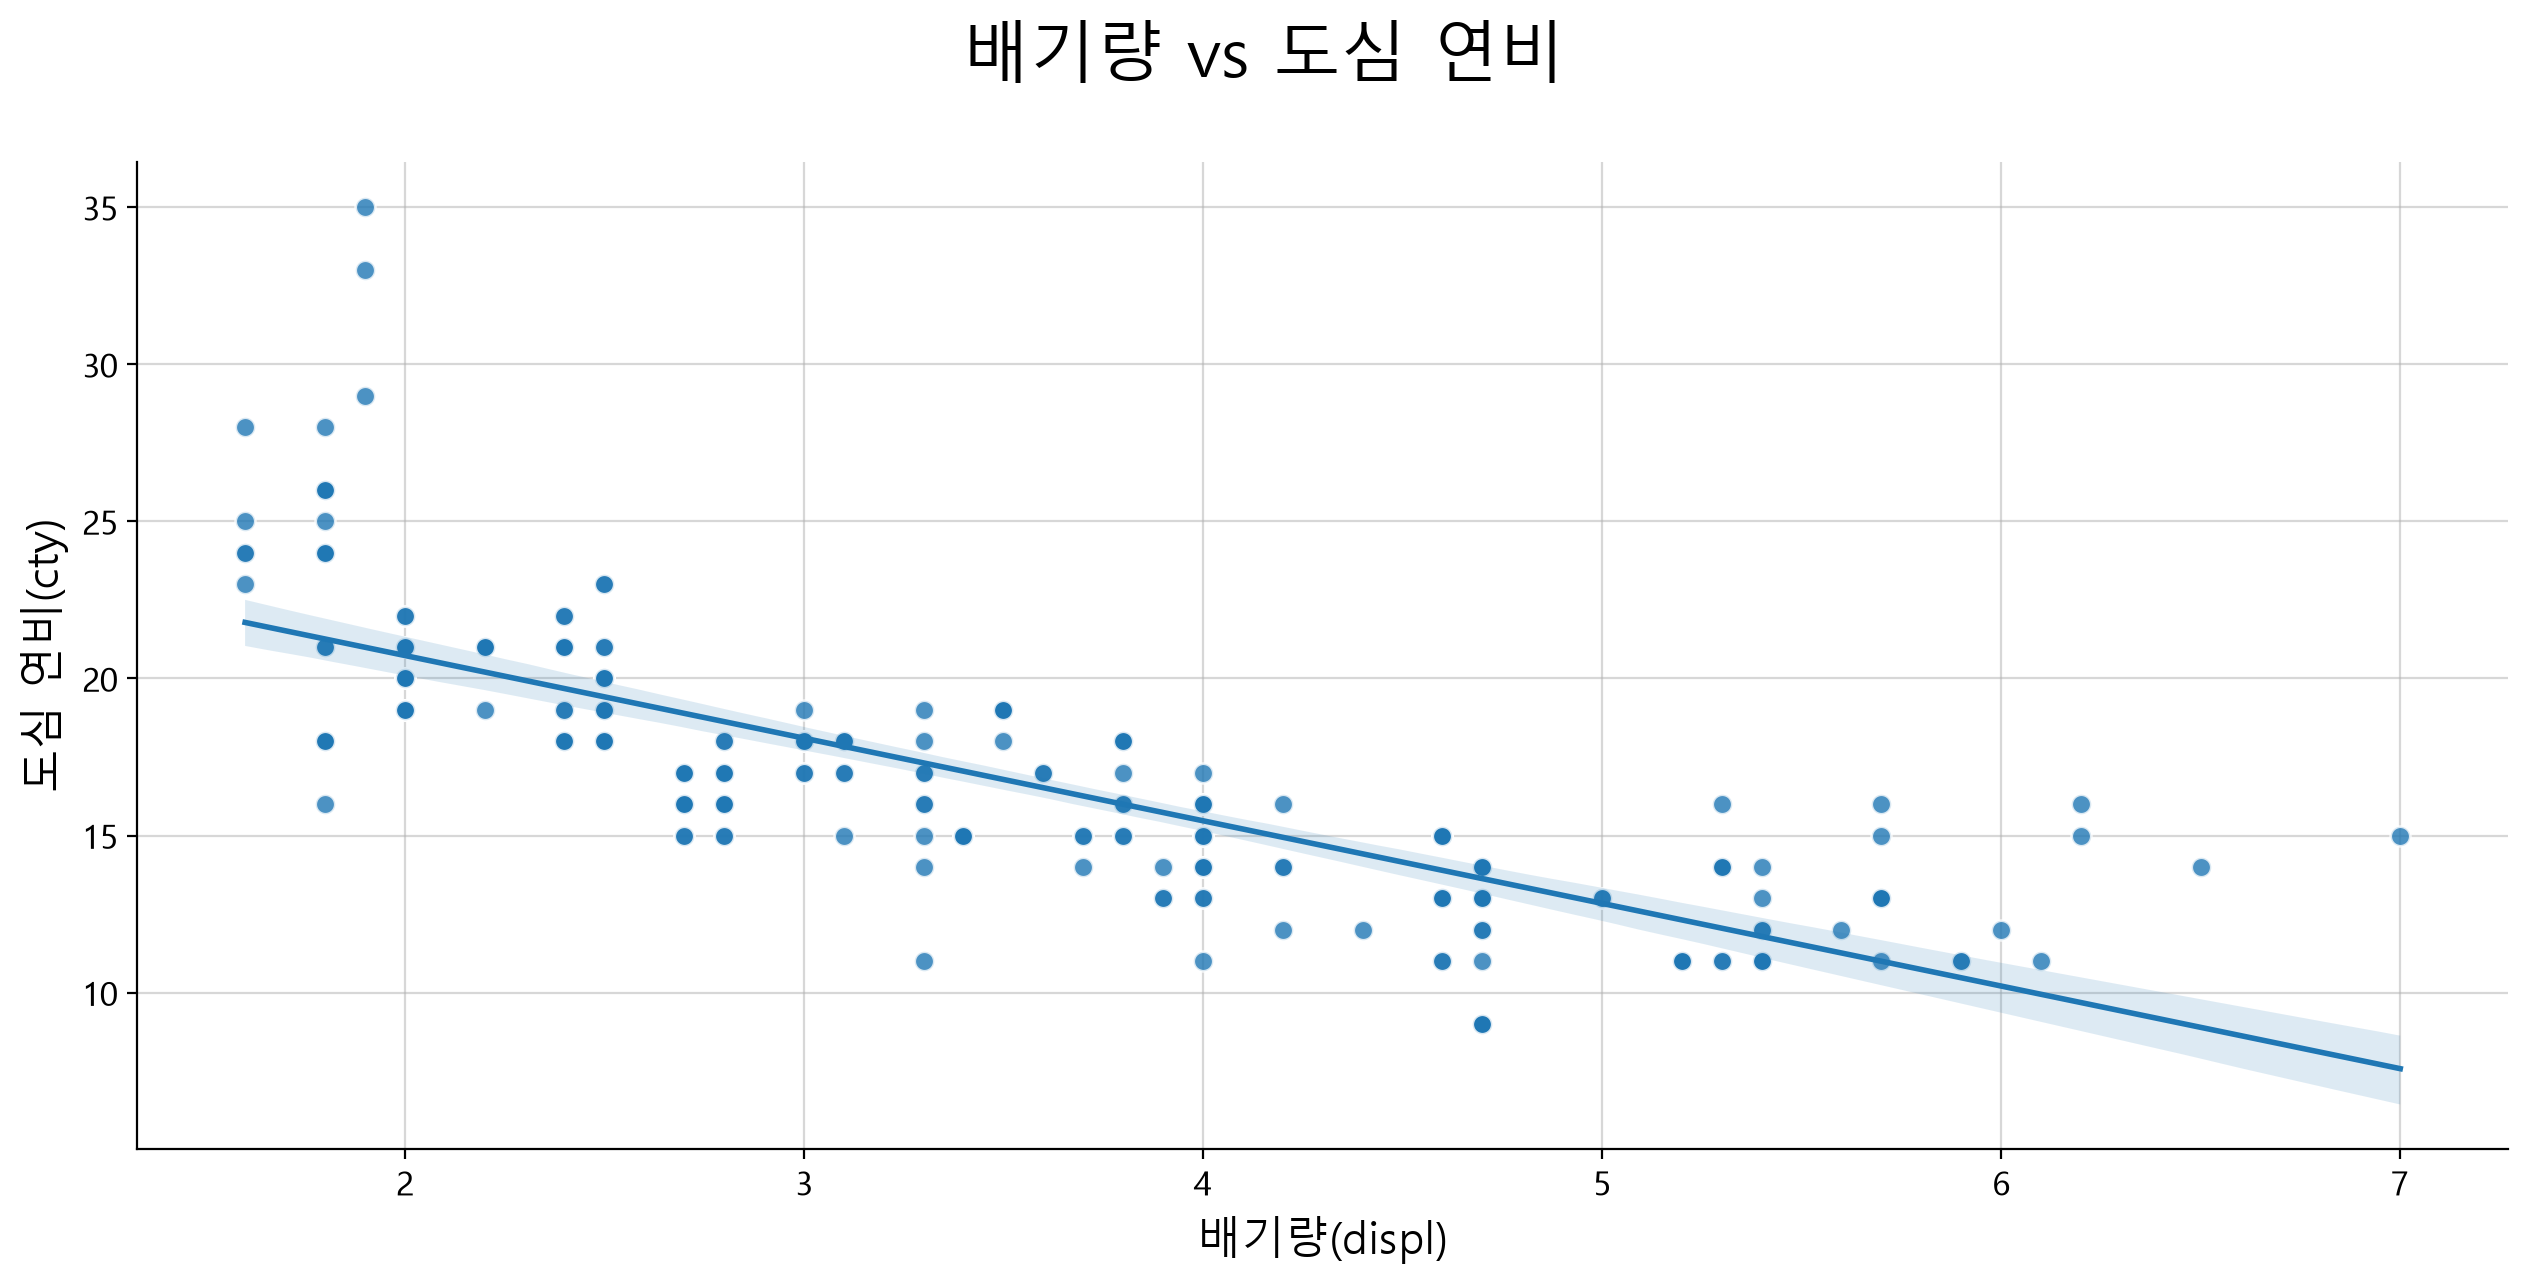

In [167]:
my_plot.lmplot(data=df, x='displ', y='cty', 
               title="배기량 vs 도심 연비", 
               xlabel="배기량(displ)", ylabel="도심 연비(cty)")

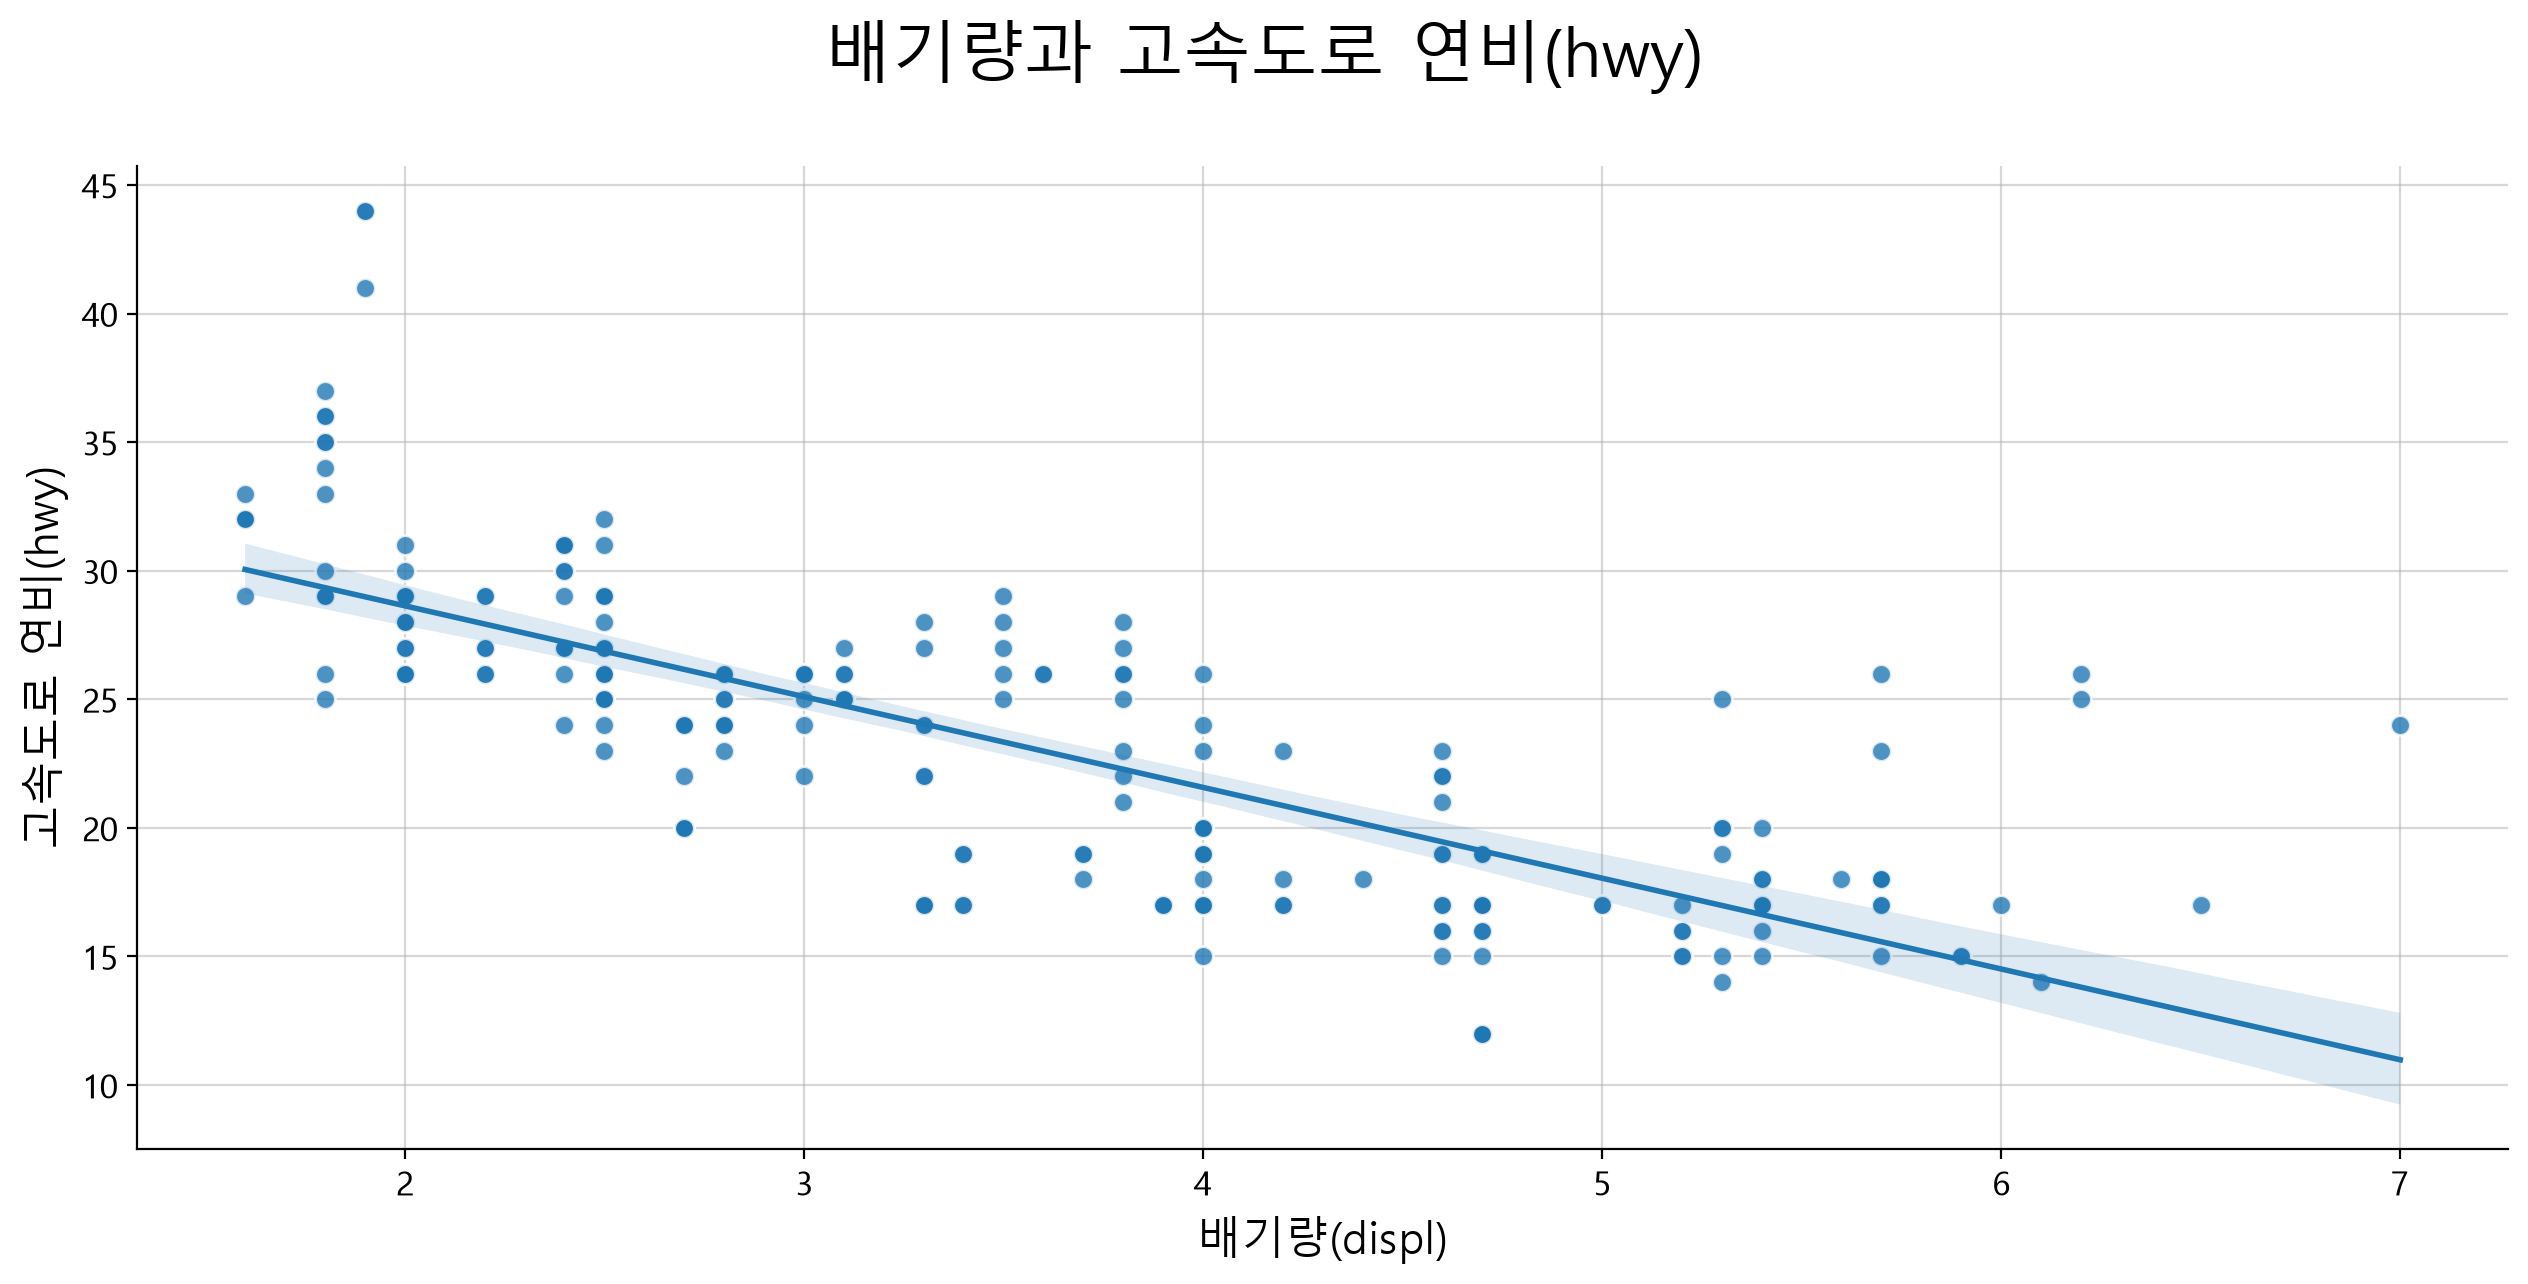

In [168]:
# (2) 배기량 - 고속도로 연비
my_plot.lmplot(data=df, x="displ", y="hwy",
               title="배기량과 고속도로 연비(hwy)", 
               xlabel="배기량(displ)", ylabel="고속도로 연비(hwy)")

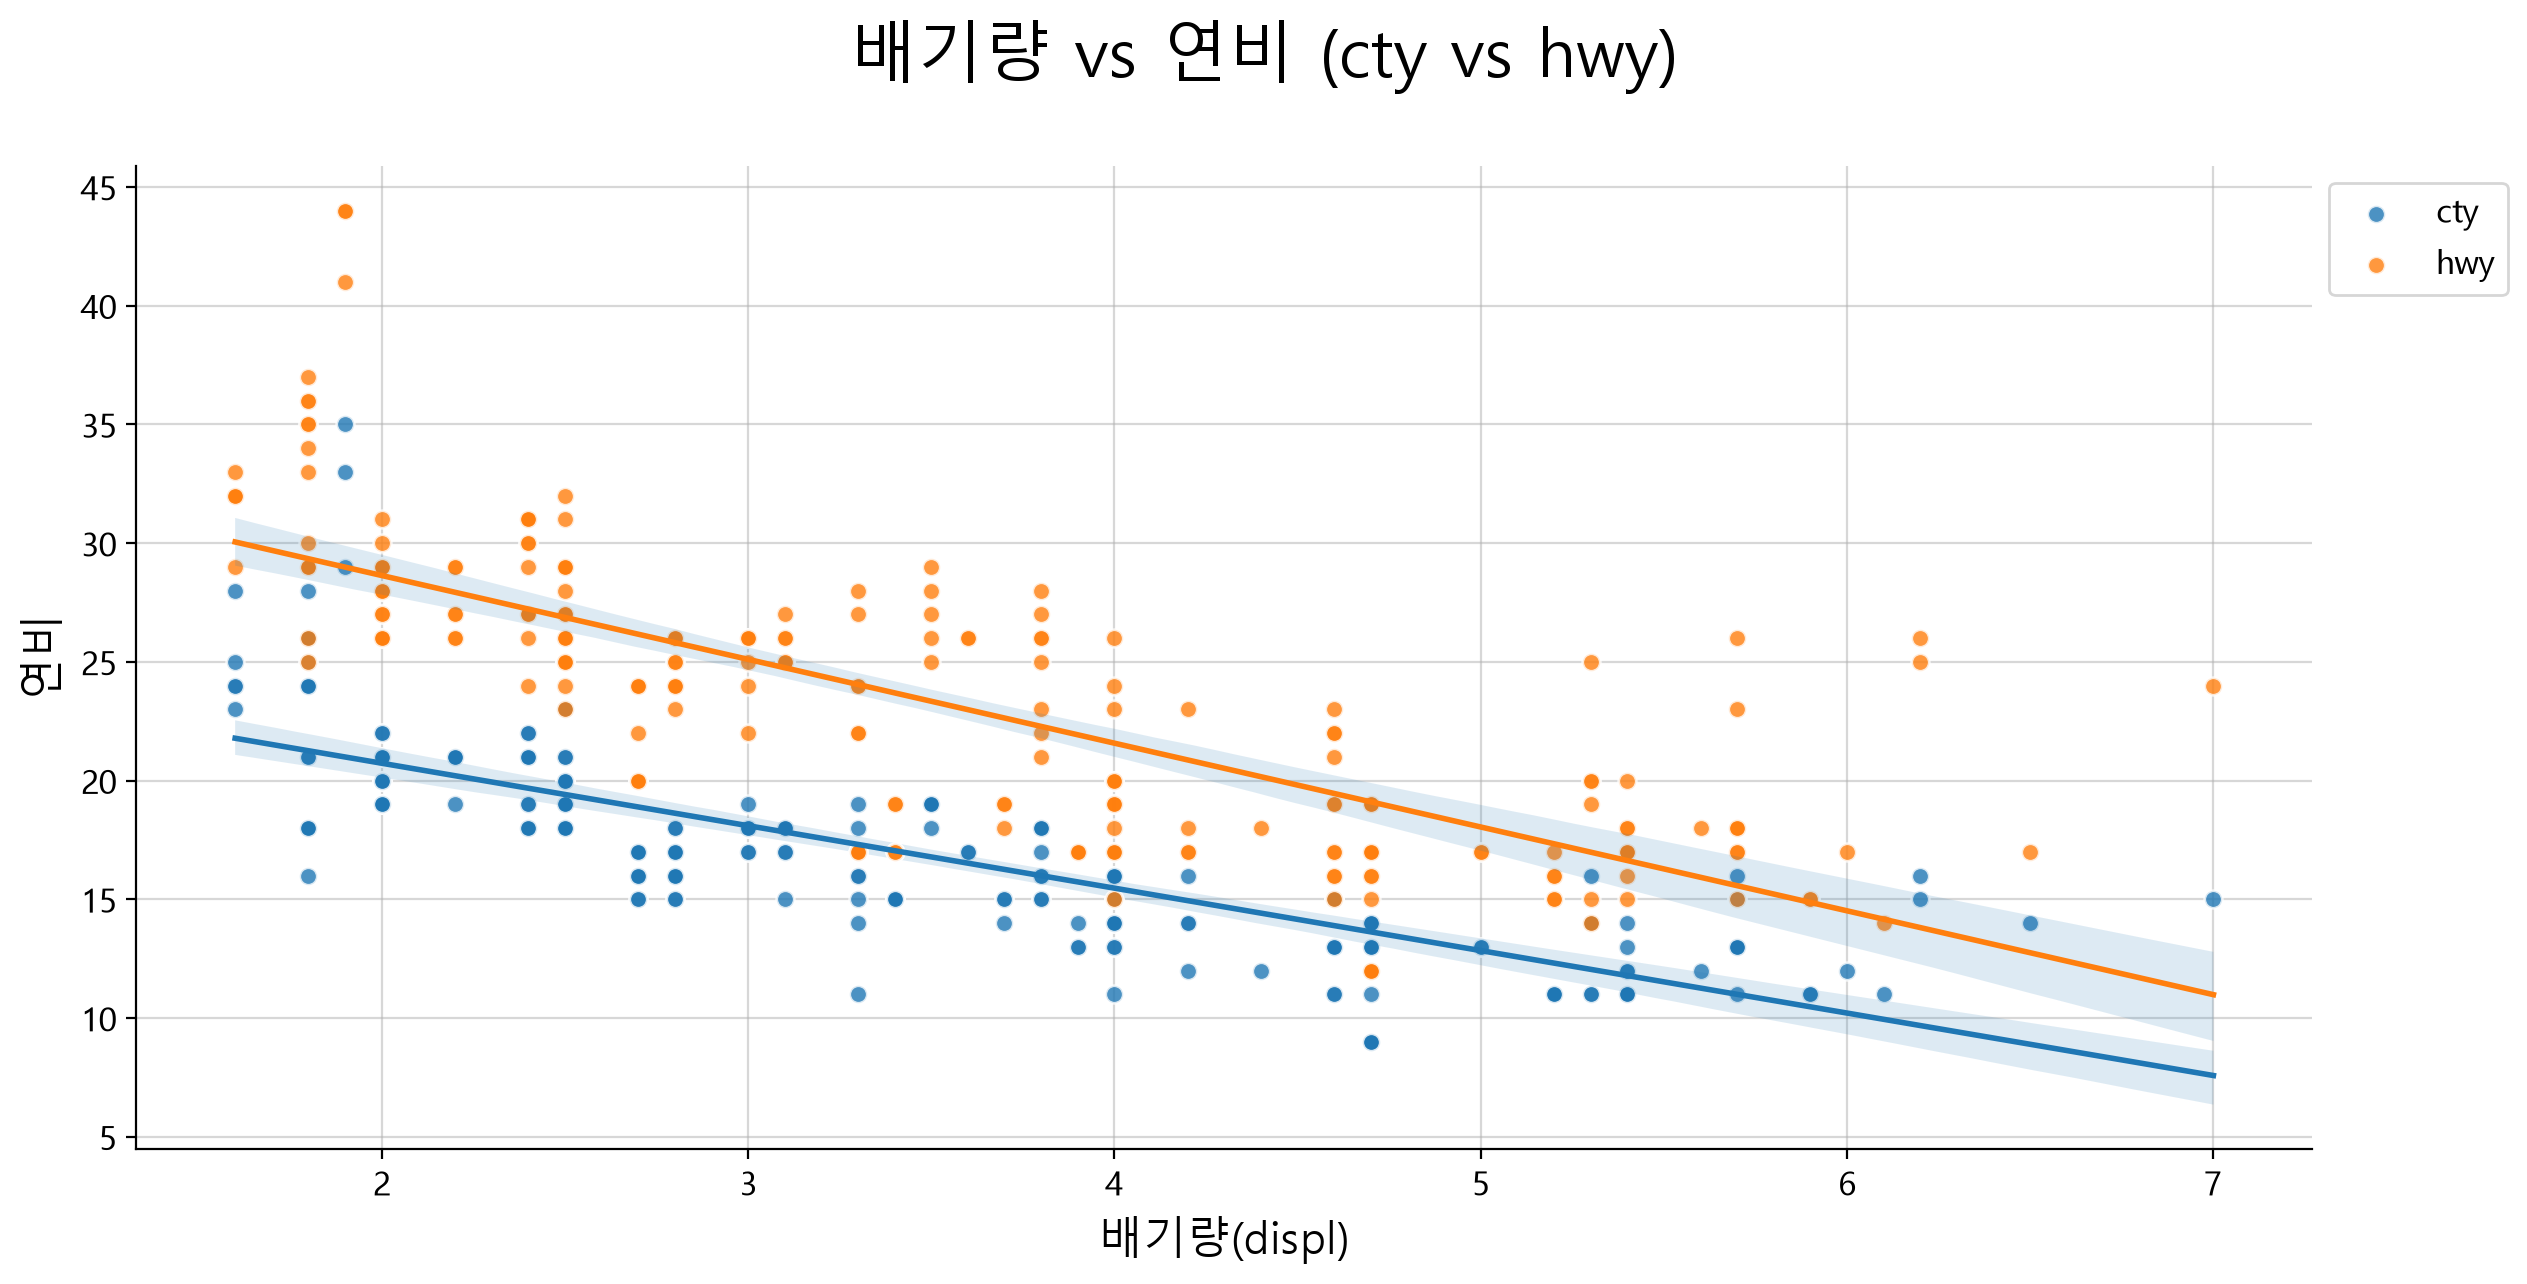

In [169]:
import pandas as pd

df_long = df.melt(id_vars='displ', value_vars=['cty', 'hwy'], 
                   var_name='연비종류', value_name='연비')

my_plot.lmplot(data=df_long, x='displ', y='연비', hue='연비종류',
               scatter_size=40, title="배기량 vs 연비 (cty vs hwy)",
               xlabel="배기량(displ)", ylabel="연비")

## 문제 8. 차종(`class`) 중 고속도로 연비(`hwy`) 평균이 가장 낮은 종류는?

① suv  ② pickup  ③ minivan  ④ midsize

> 💡 **힌트**: 막대그래프 (차종별 hwy 평균)

- 내 답 : pickup

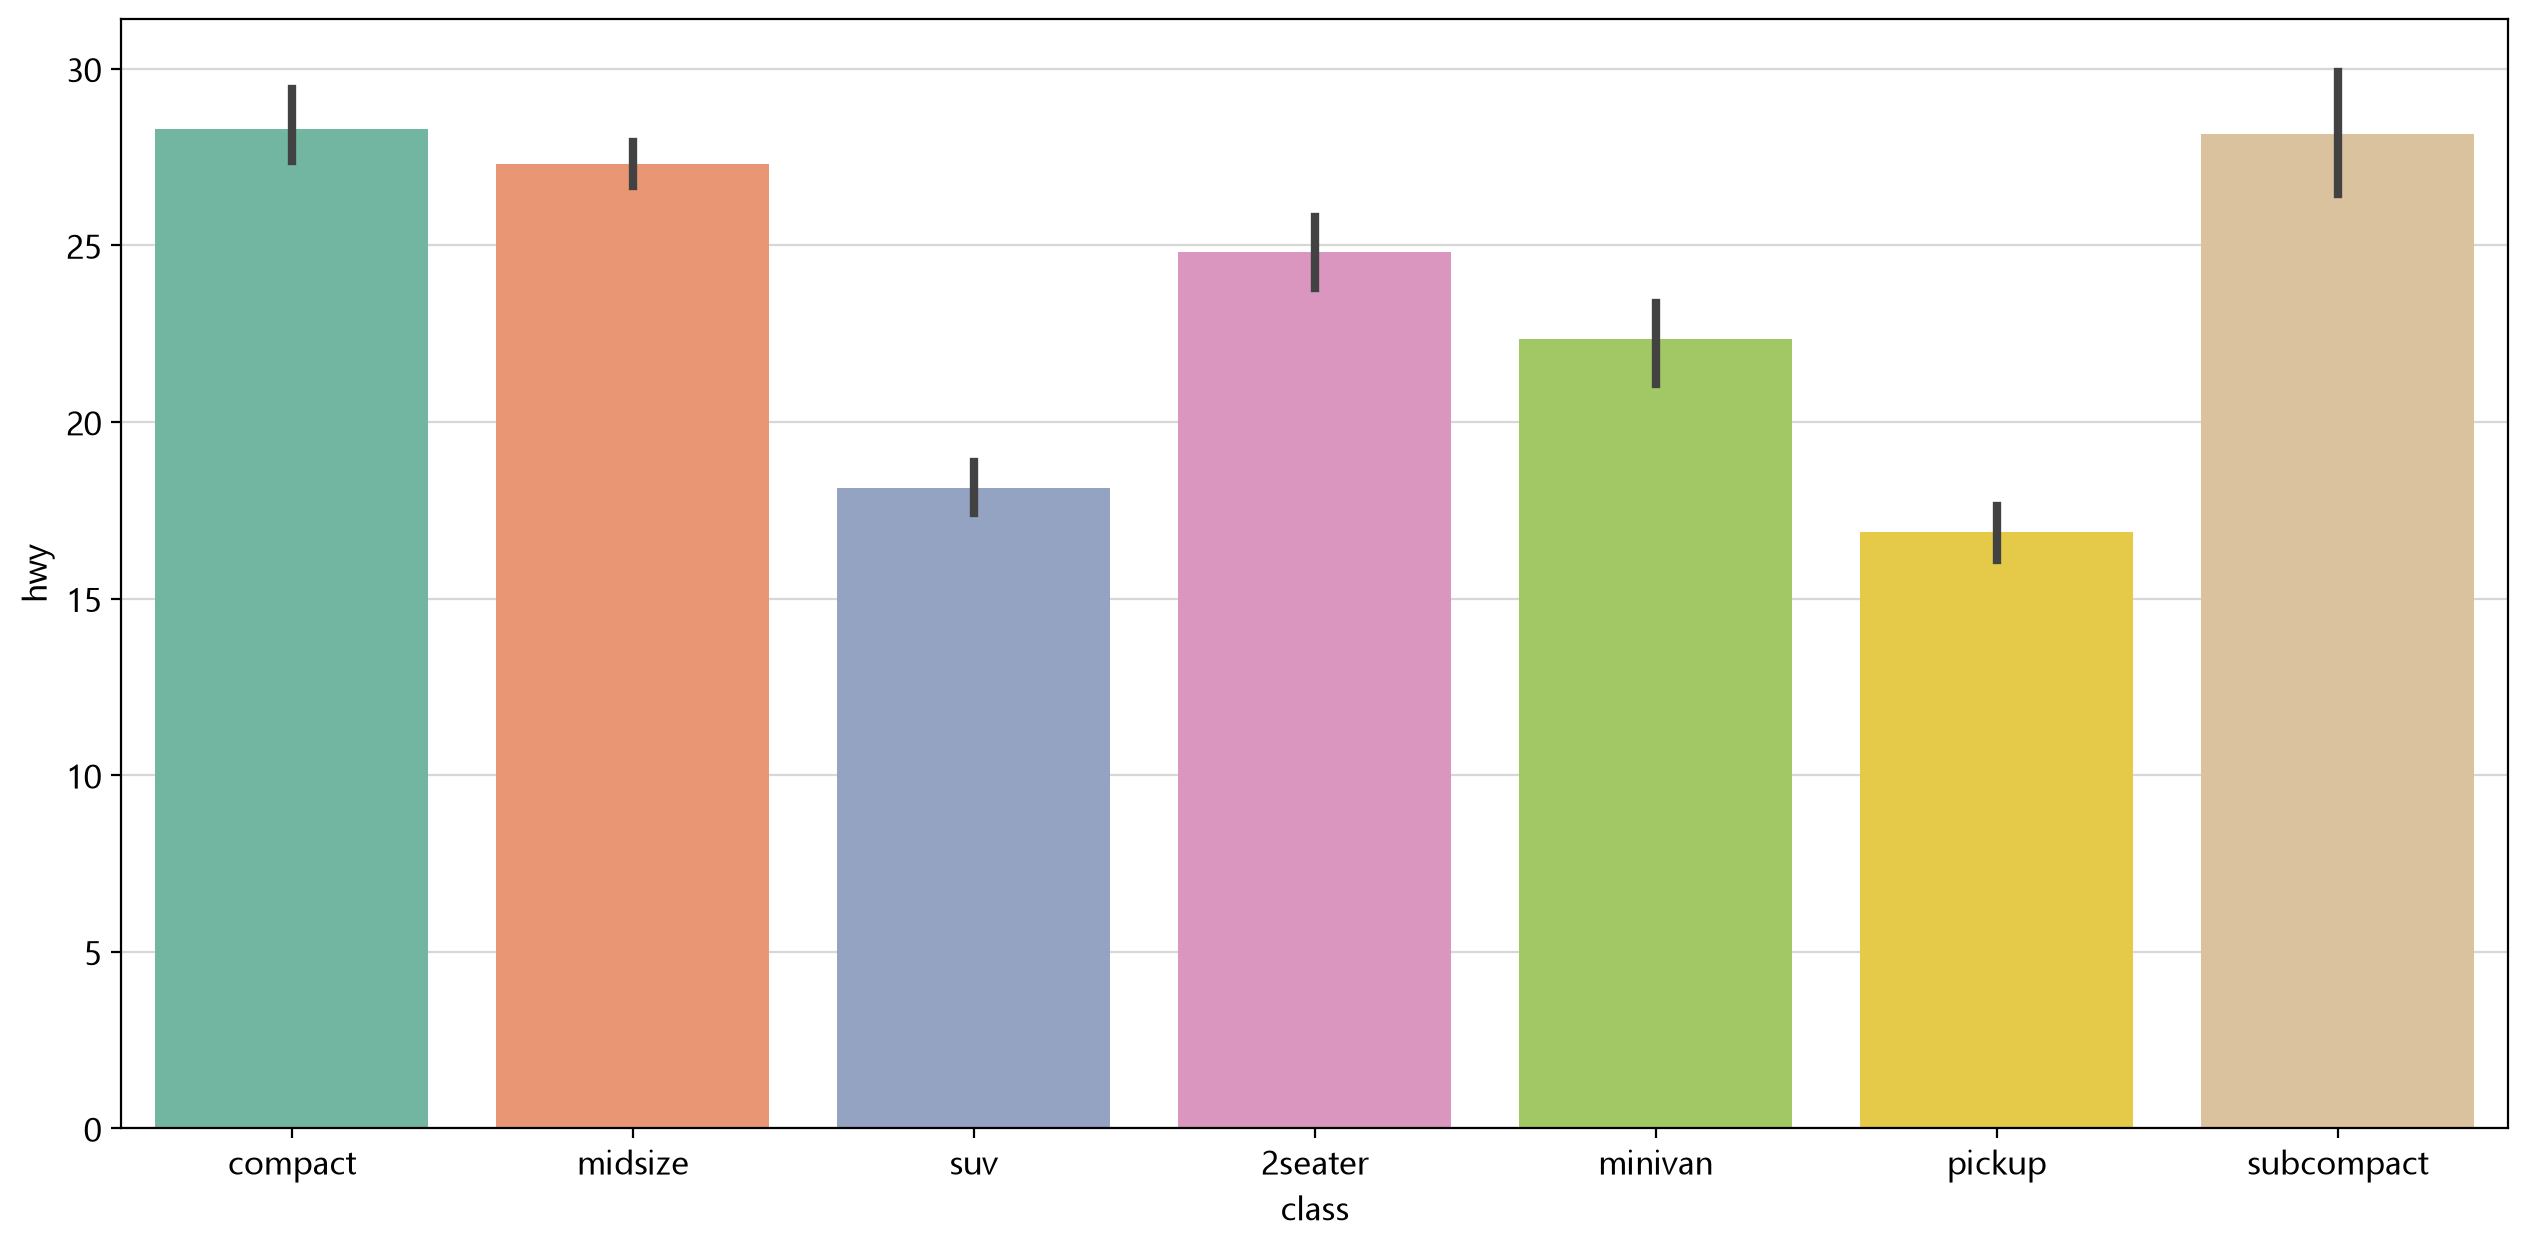

In [170]:
my_plot.barplot(data=df, x='class', y='hwy', hue='class', palette='Set2')

In [171]:
# 4) sorted라는 변수명 — 이건 짚고 넘어갈 만해요
# 강사님 코드가 sorted = df.groupby(...)...처럼 변수명을 sorted로 쓰셨는데, 사실 이건 파이썬 내장 함수 sorted()를 그대로 가리는(shadowing) 이름이에요. 이 셀 이후에 코드에서 sorted(...)라는 내장 함수를 쓰려고 하면 에러가 나거나 예상과 다르게 동작해요. 강사님 코드 스타일 중 유일하게 따라 하지 않는 게 나은 부분이니, 연주님이 비슷한 패턴 쓰실 땐 sorted_hwy, hwy_order 같은 이름을 추천해요

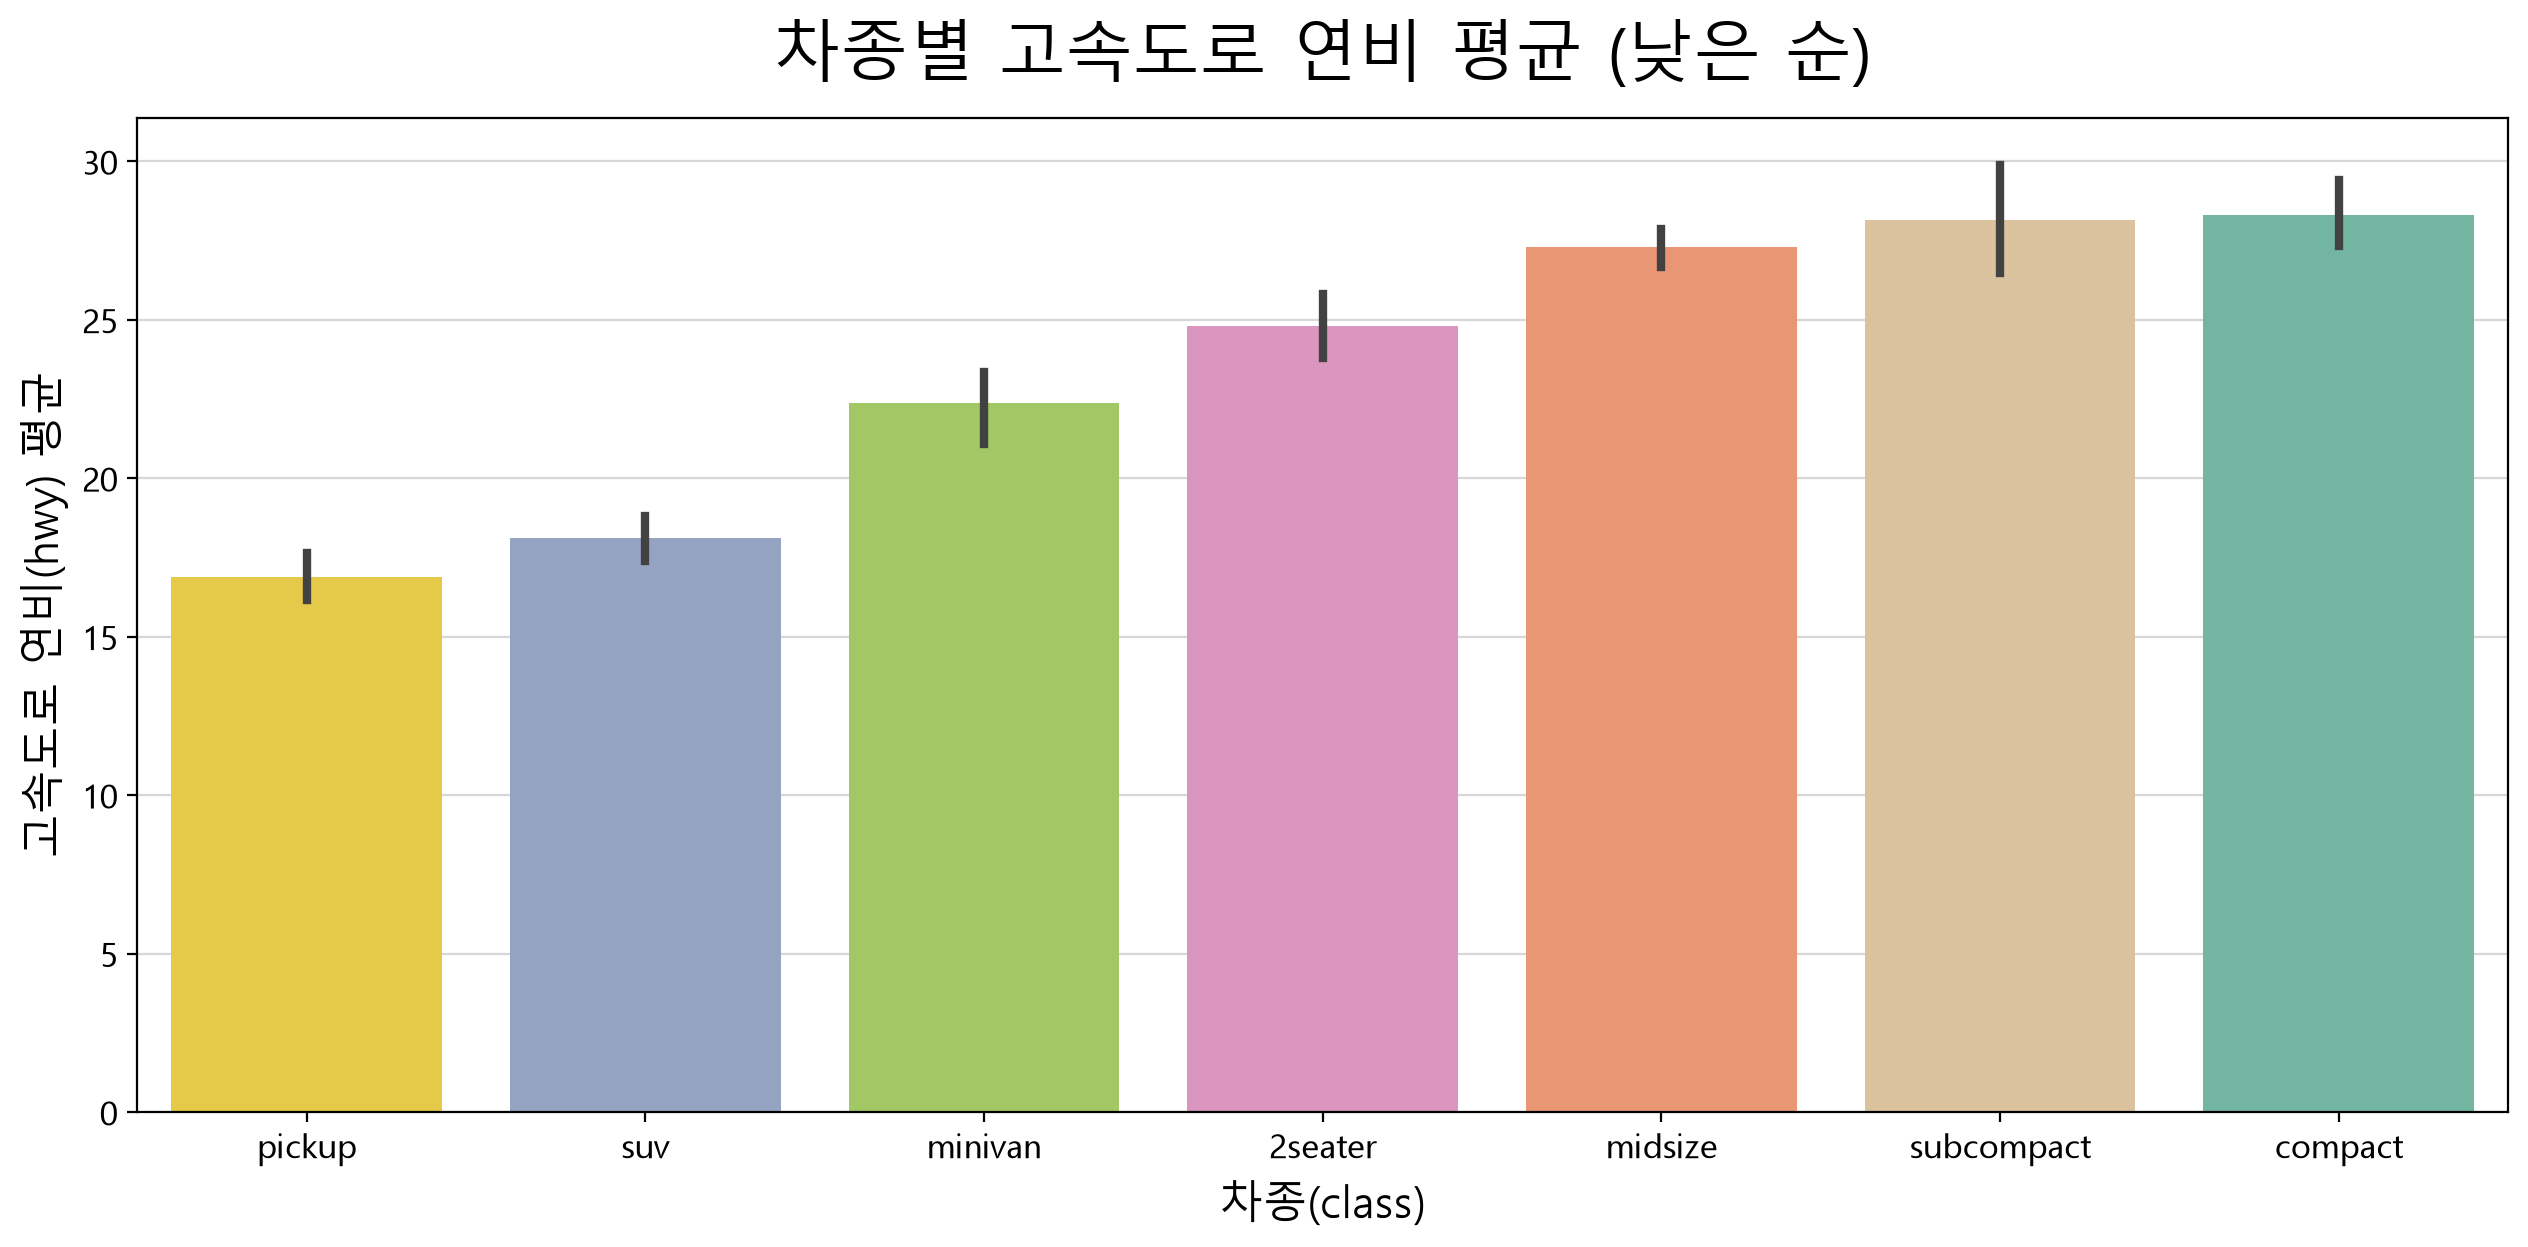

In [172]:
sorted = df.groupby("class")["hwy"].mean().sort_values(ascending=True)

my_plot.barplot(data=df, x="class", y="hwy", estimator="mean", hue="class", palette="Set2", order=sorted.index, title="차종별 고속도로 연비 평균 (낮은 순)", xlabel="차종(class)", ylabel="고속도로 연비(hwy) 평균")

## 문제 9. 차종(`class`) 중 고속도로 연비(`hwy`) 평균이 가장 높은 종류는?

① compact  ② subcompact  ③ midsize  ④ 2seater

> 💡 **힌트**: 막대그래프 (차종별 hwy 평균, 내림차순 정렬)

- 내 답 : compact

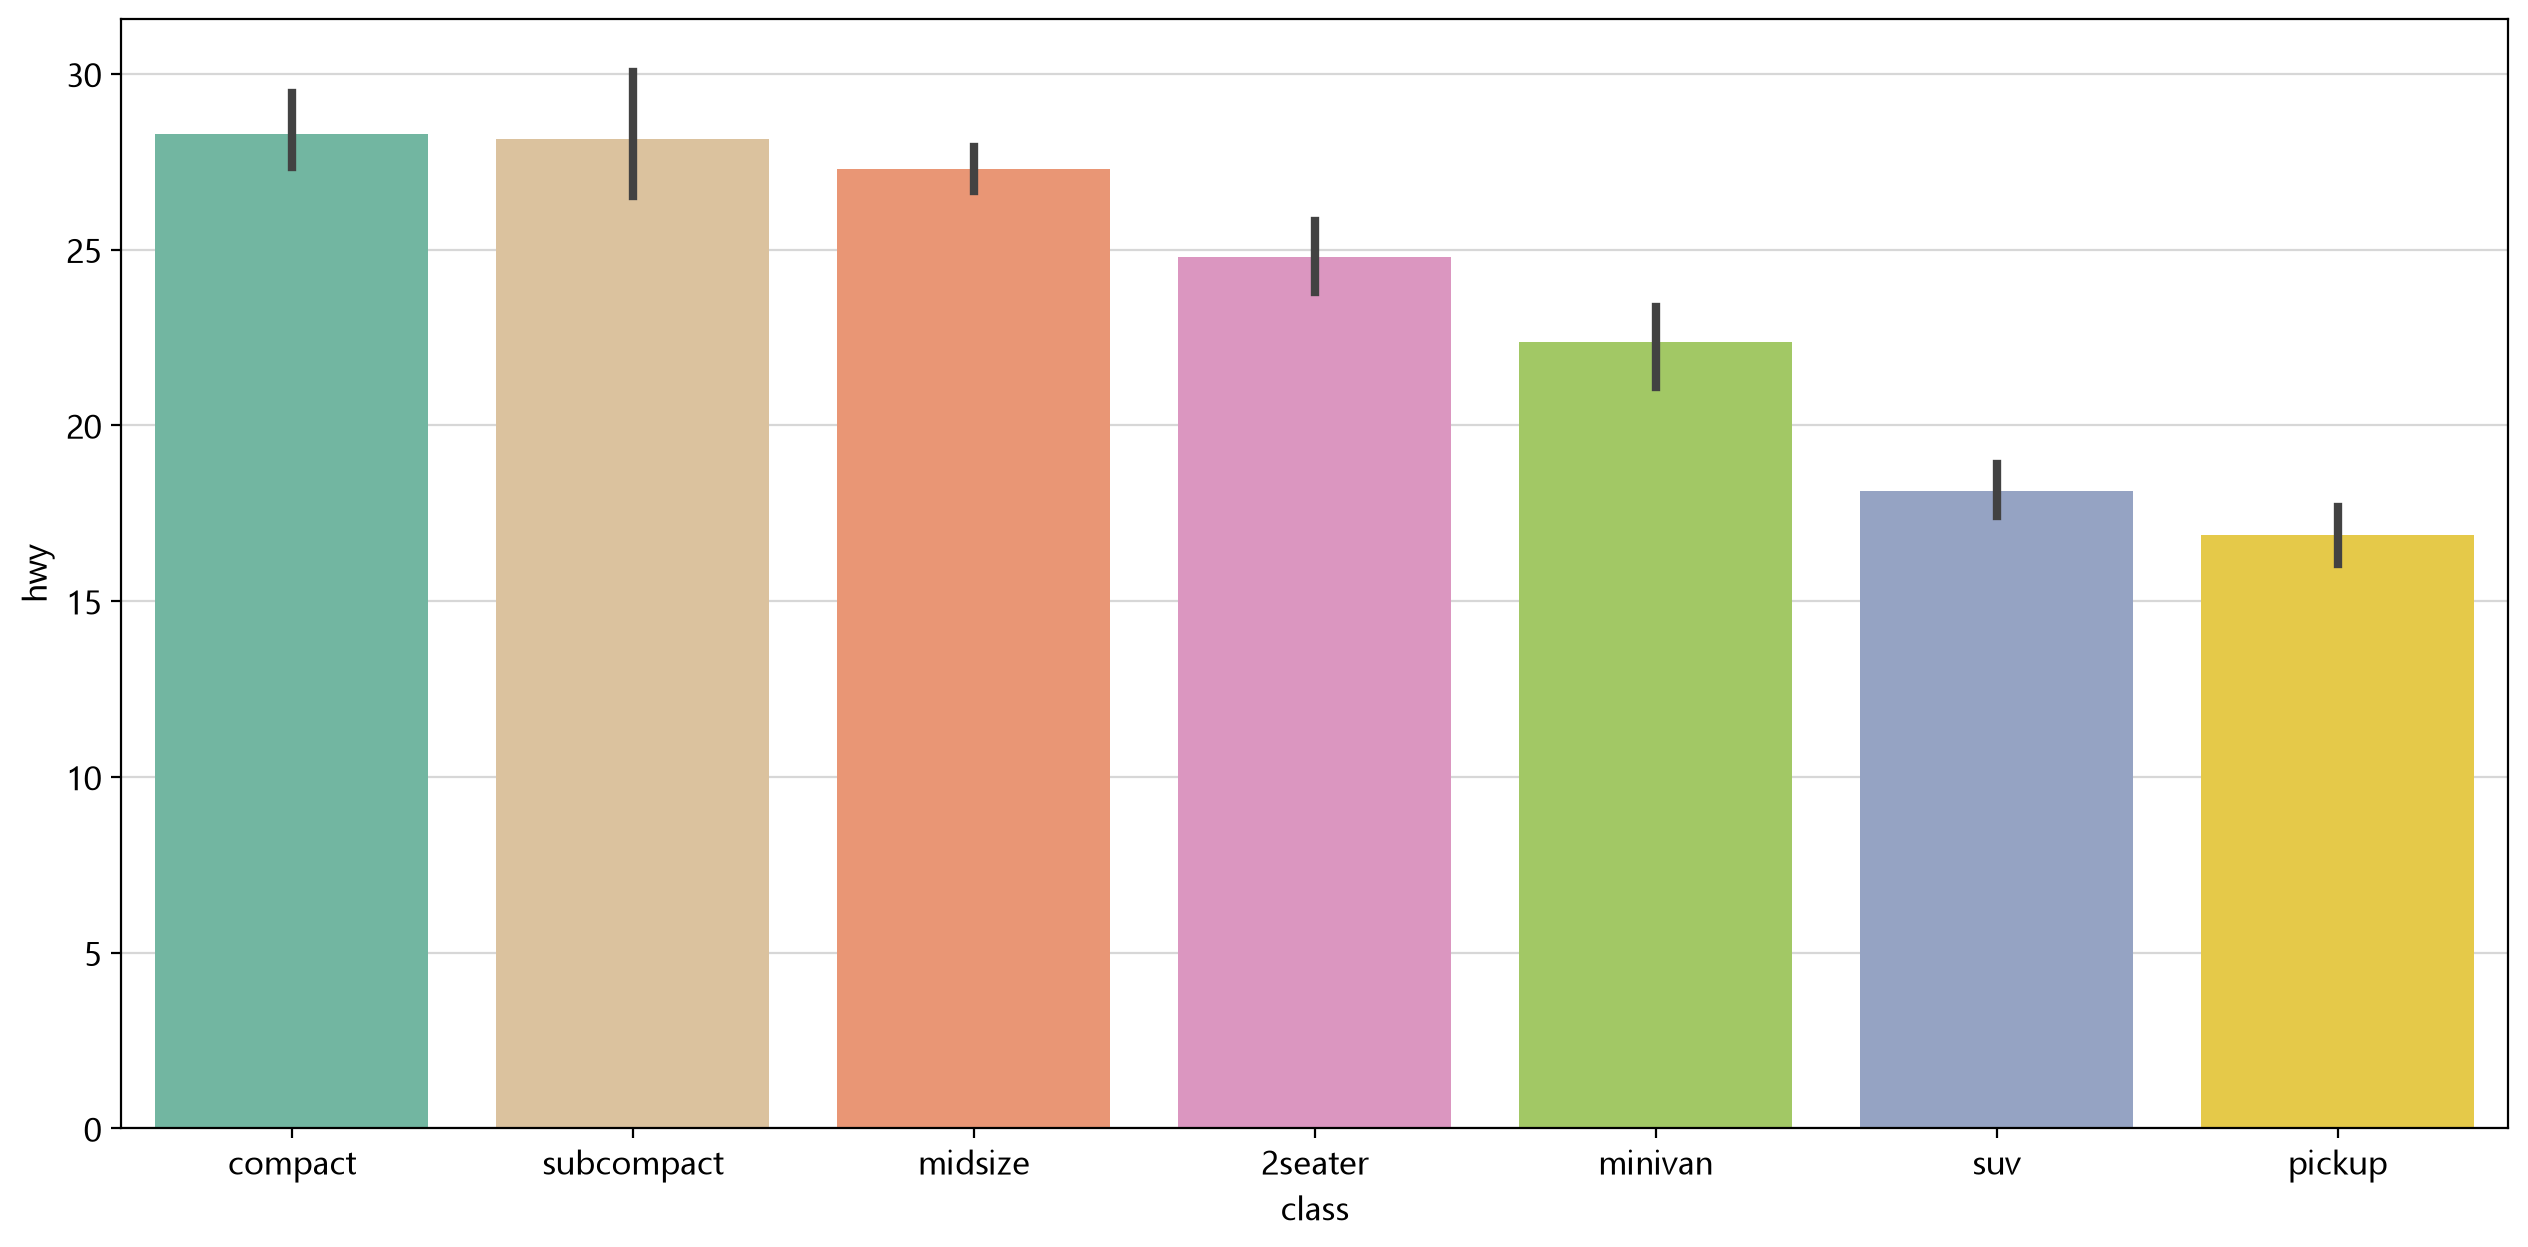

In [173]:
order = df.groupby('class')['hwy'].mean().sort_values(ascending=False).index
my_plot.barplot(data=df, x='class', y='hwy', hue='class', palette='Set2', order=order)

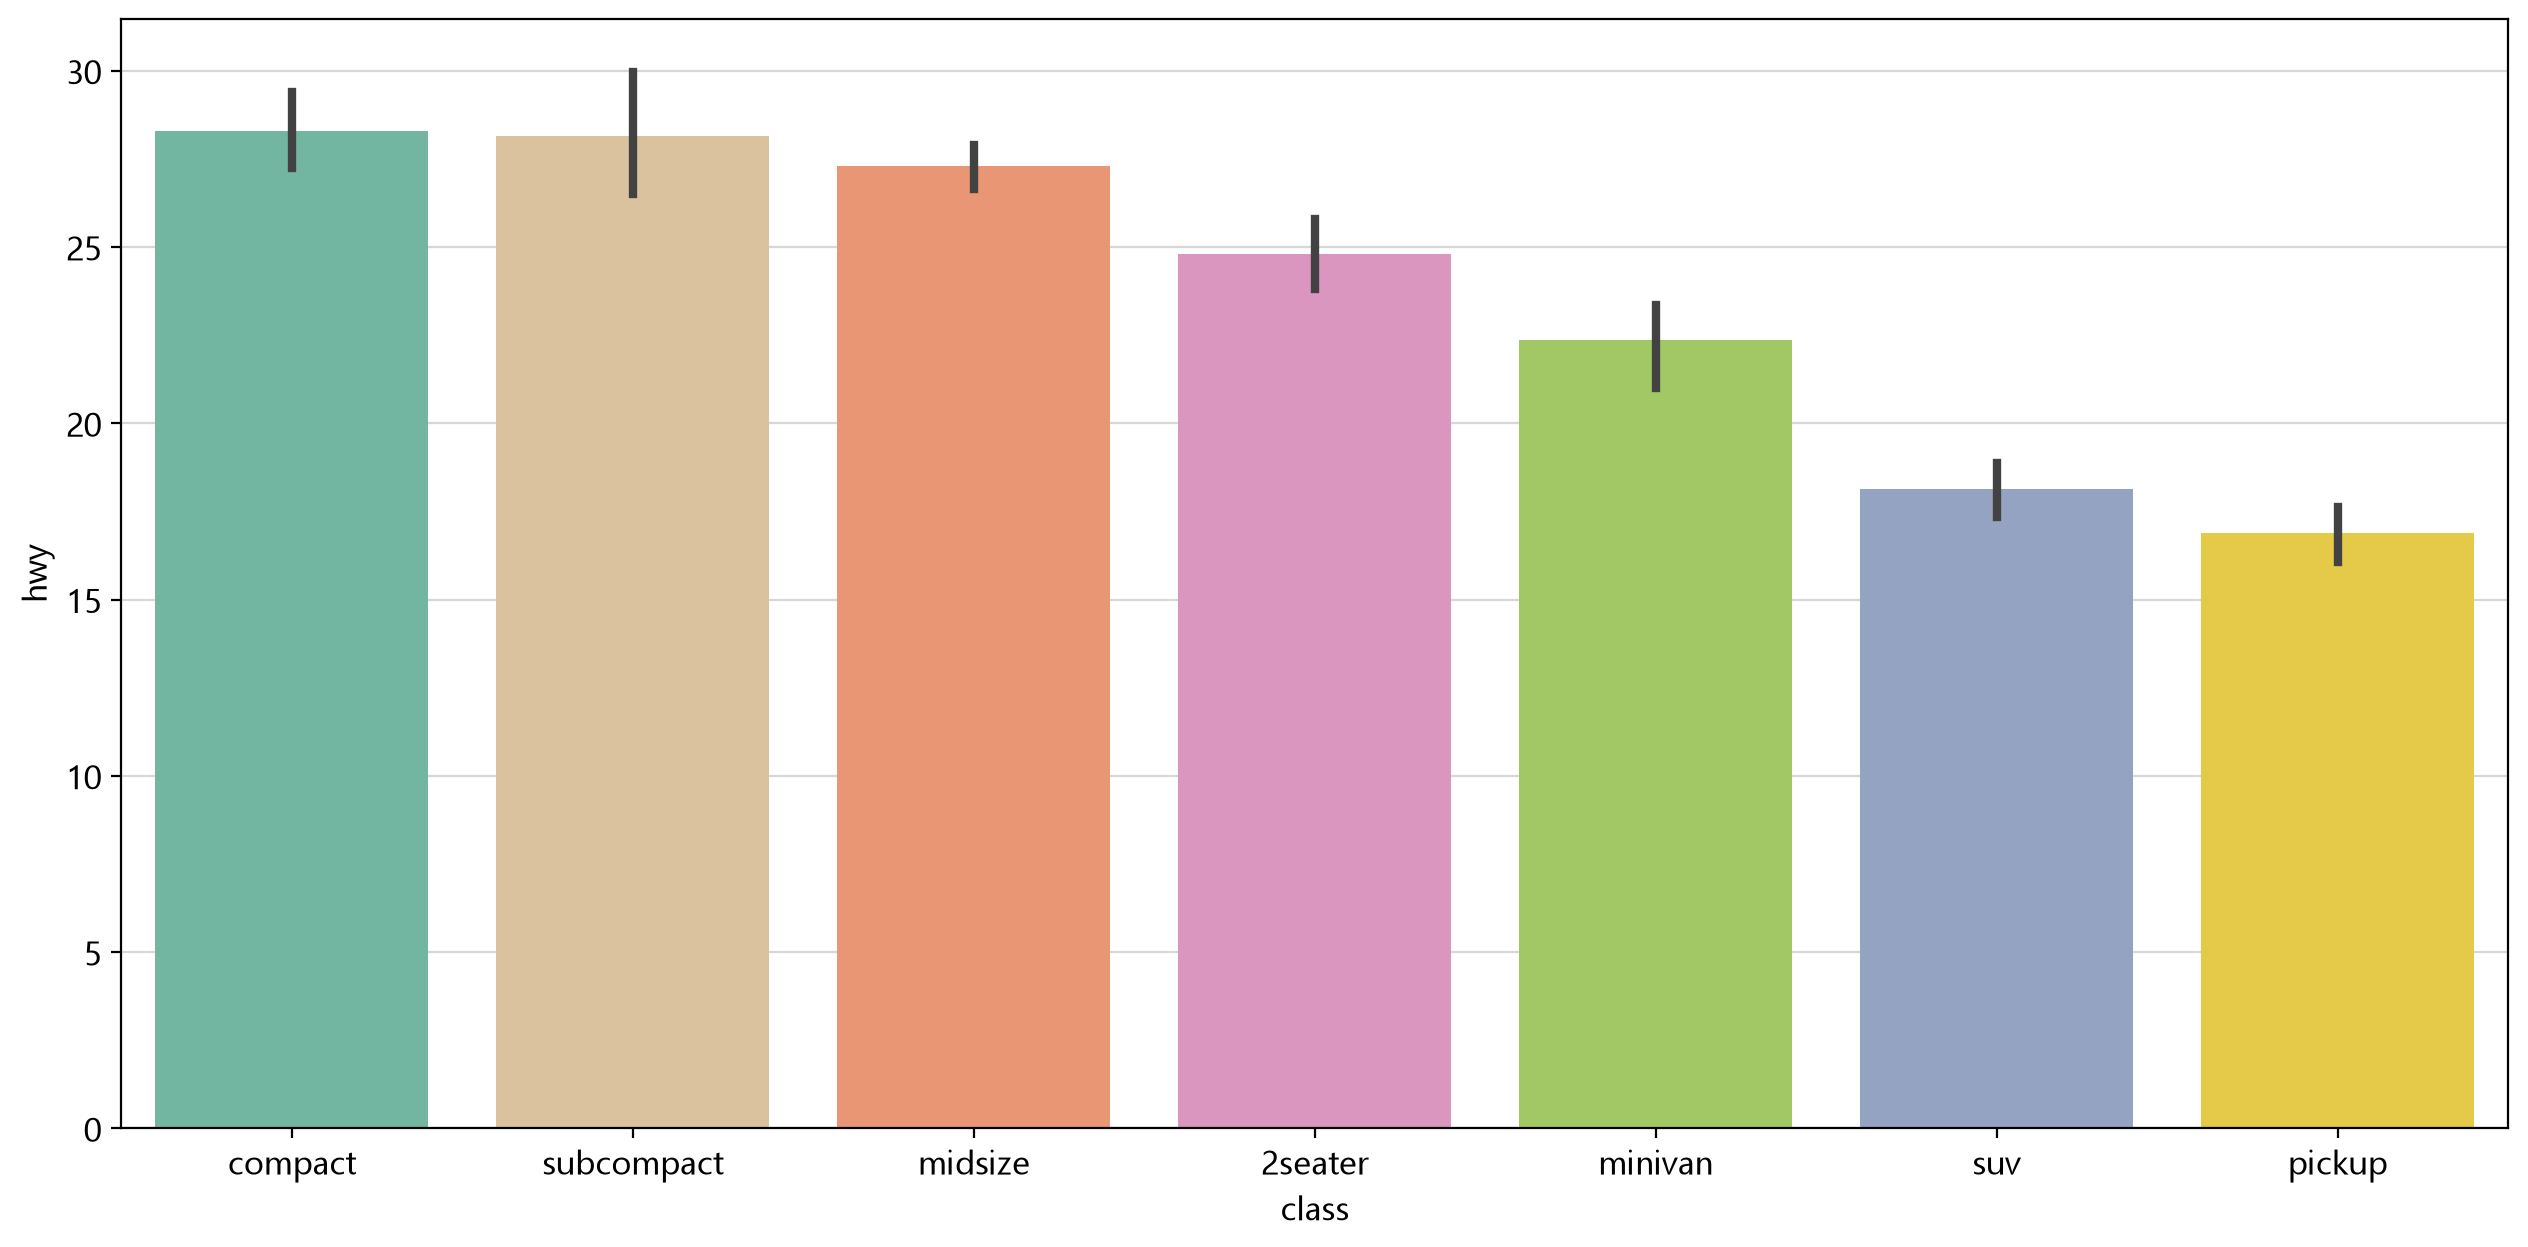

In [174]:
my_plot.barplot(data=df, x='class', y='hwy', hue='class', palette='Set2', order = df.groupby('class')['hwy'].mean().sort_values(ascending=False).index
)

## 문제 10. 도심 연비(`cty`) 평균이 가장 높은 제조사는?

① volkswagen  ② honda  ③ subaru  ④ hyundai

> 💡 **힌트**: 막대그래프 (제조사별 cty 평균)

- 내 답 : honda

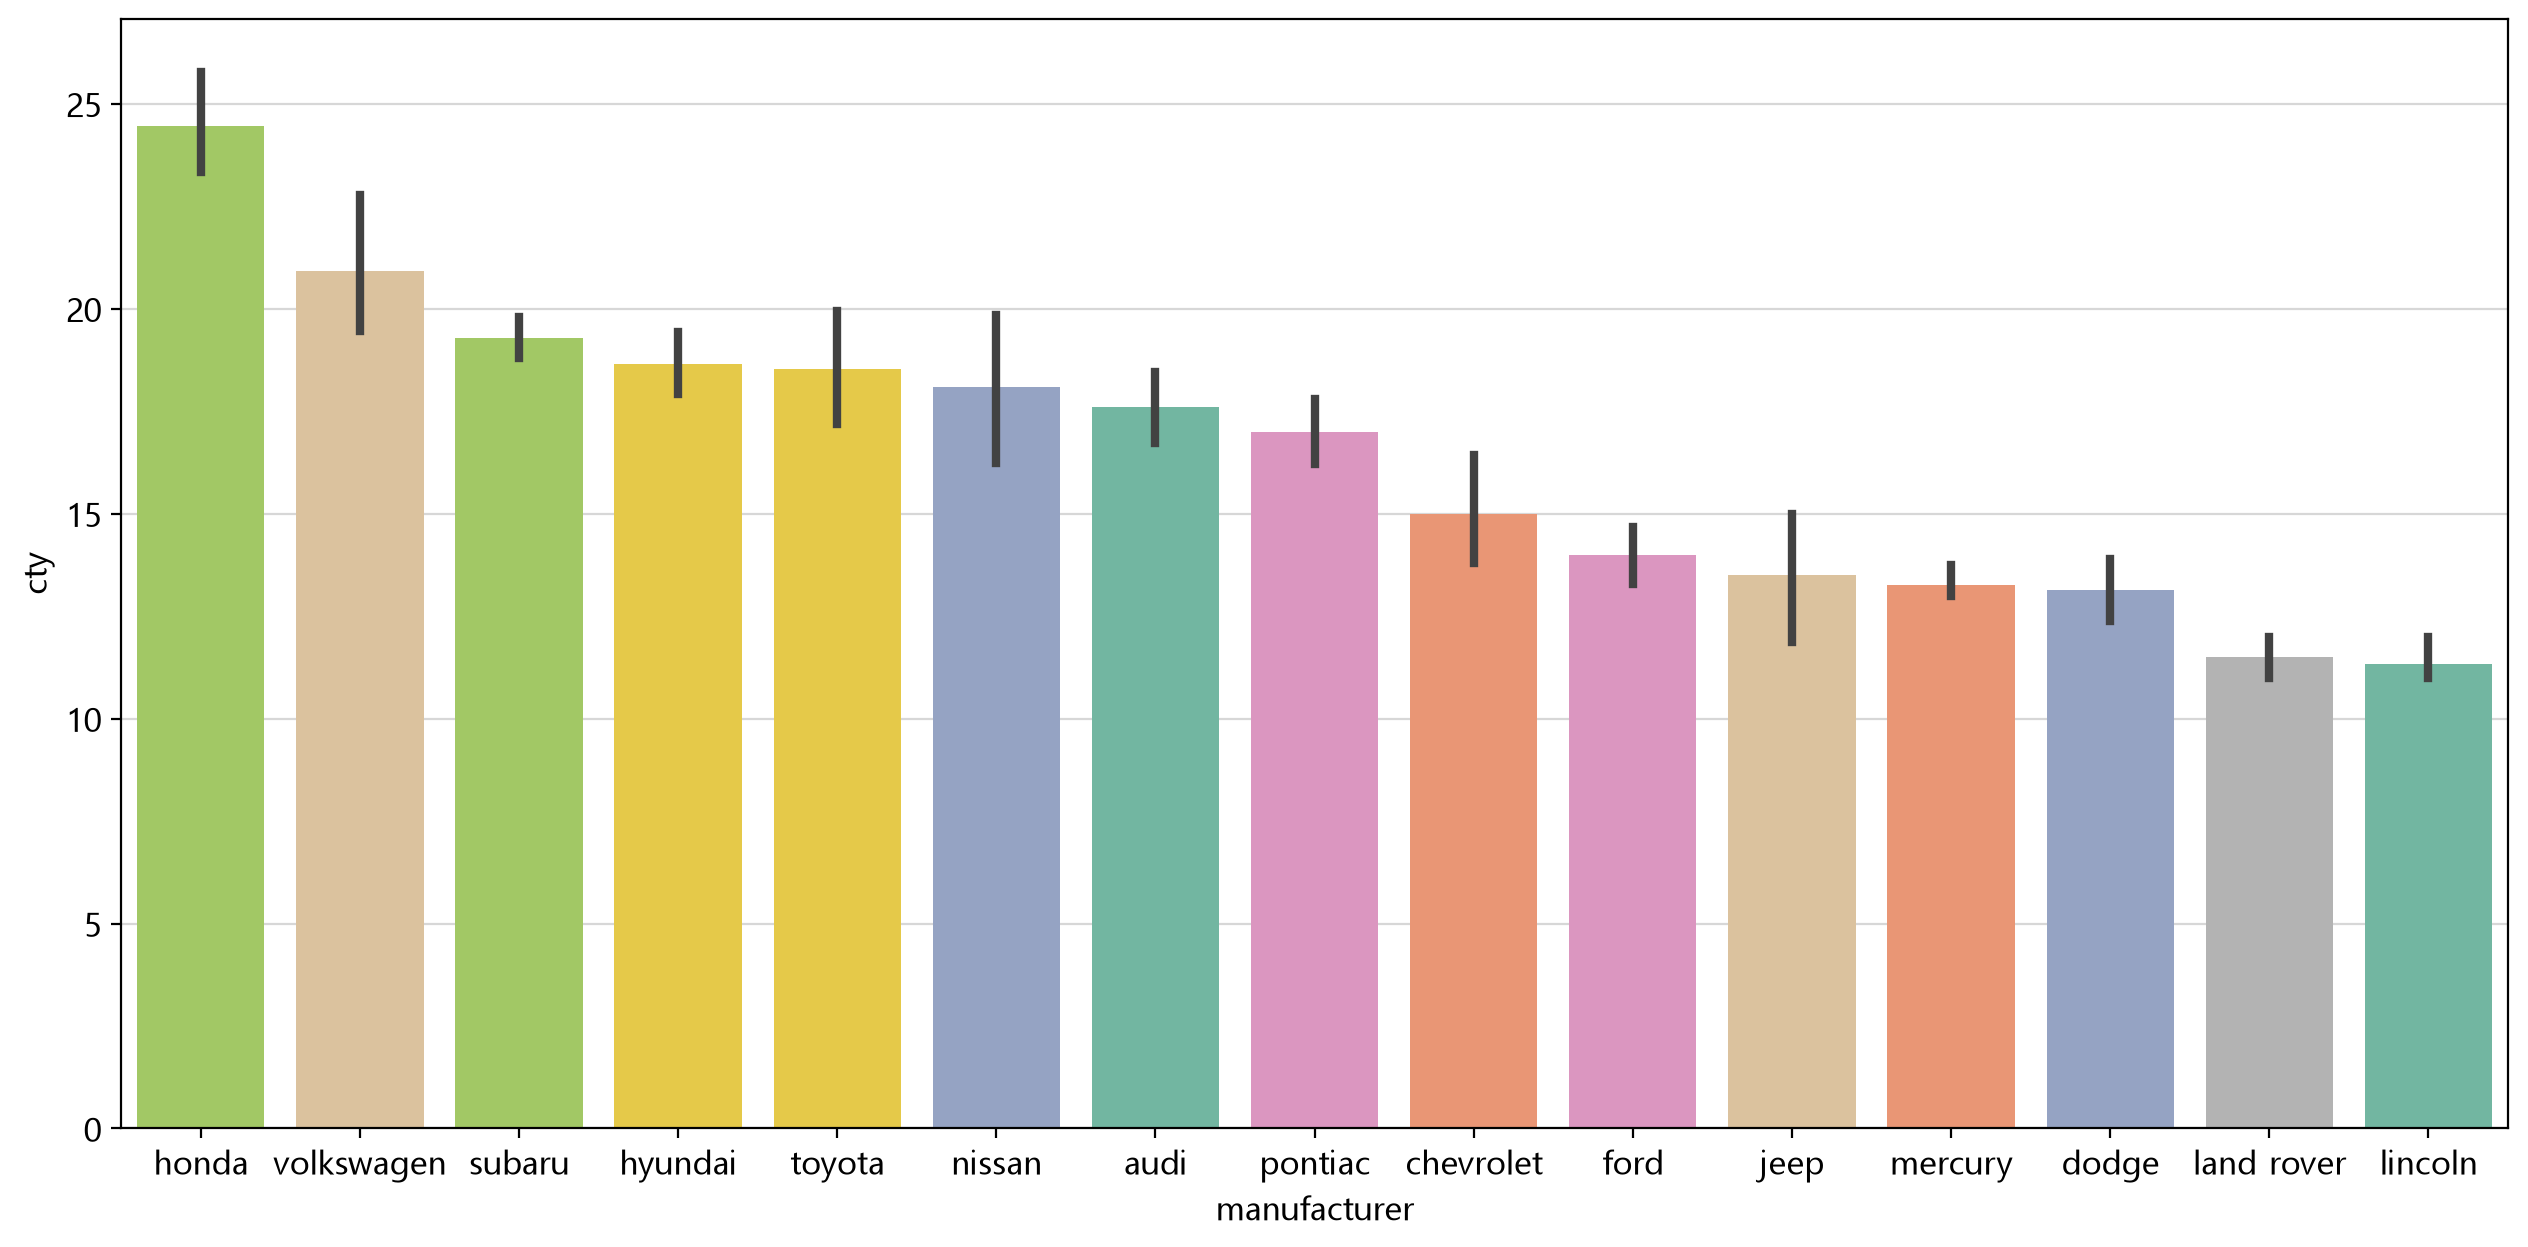

In [175]:
my_plot.barplot(data=df, x='manufacturer', y='cty', 
                hue='manufacturer', palette='Set2', 
                order = df.groupby('manufacturer')['cty'].mean().sort_values(ascending=False).index
)

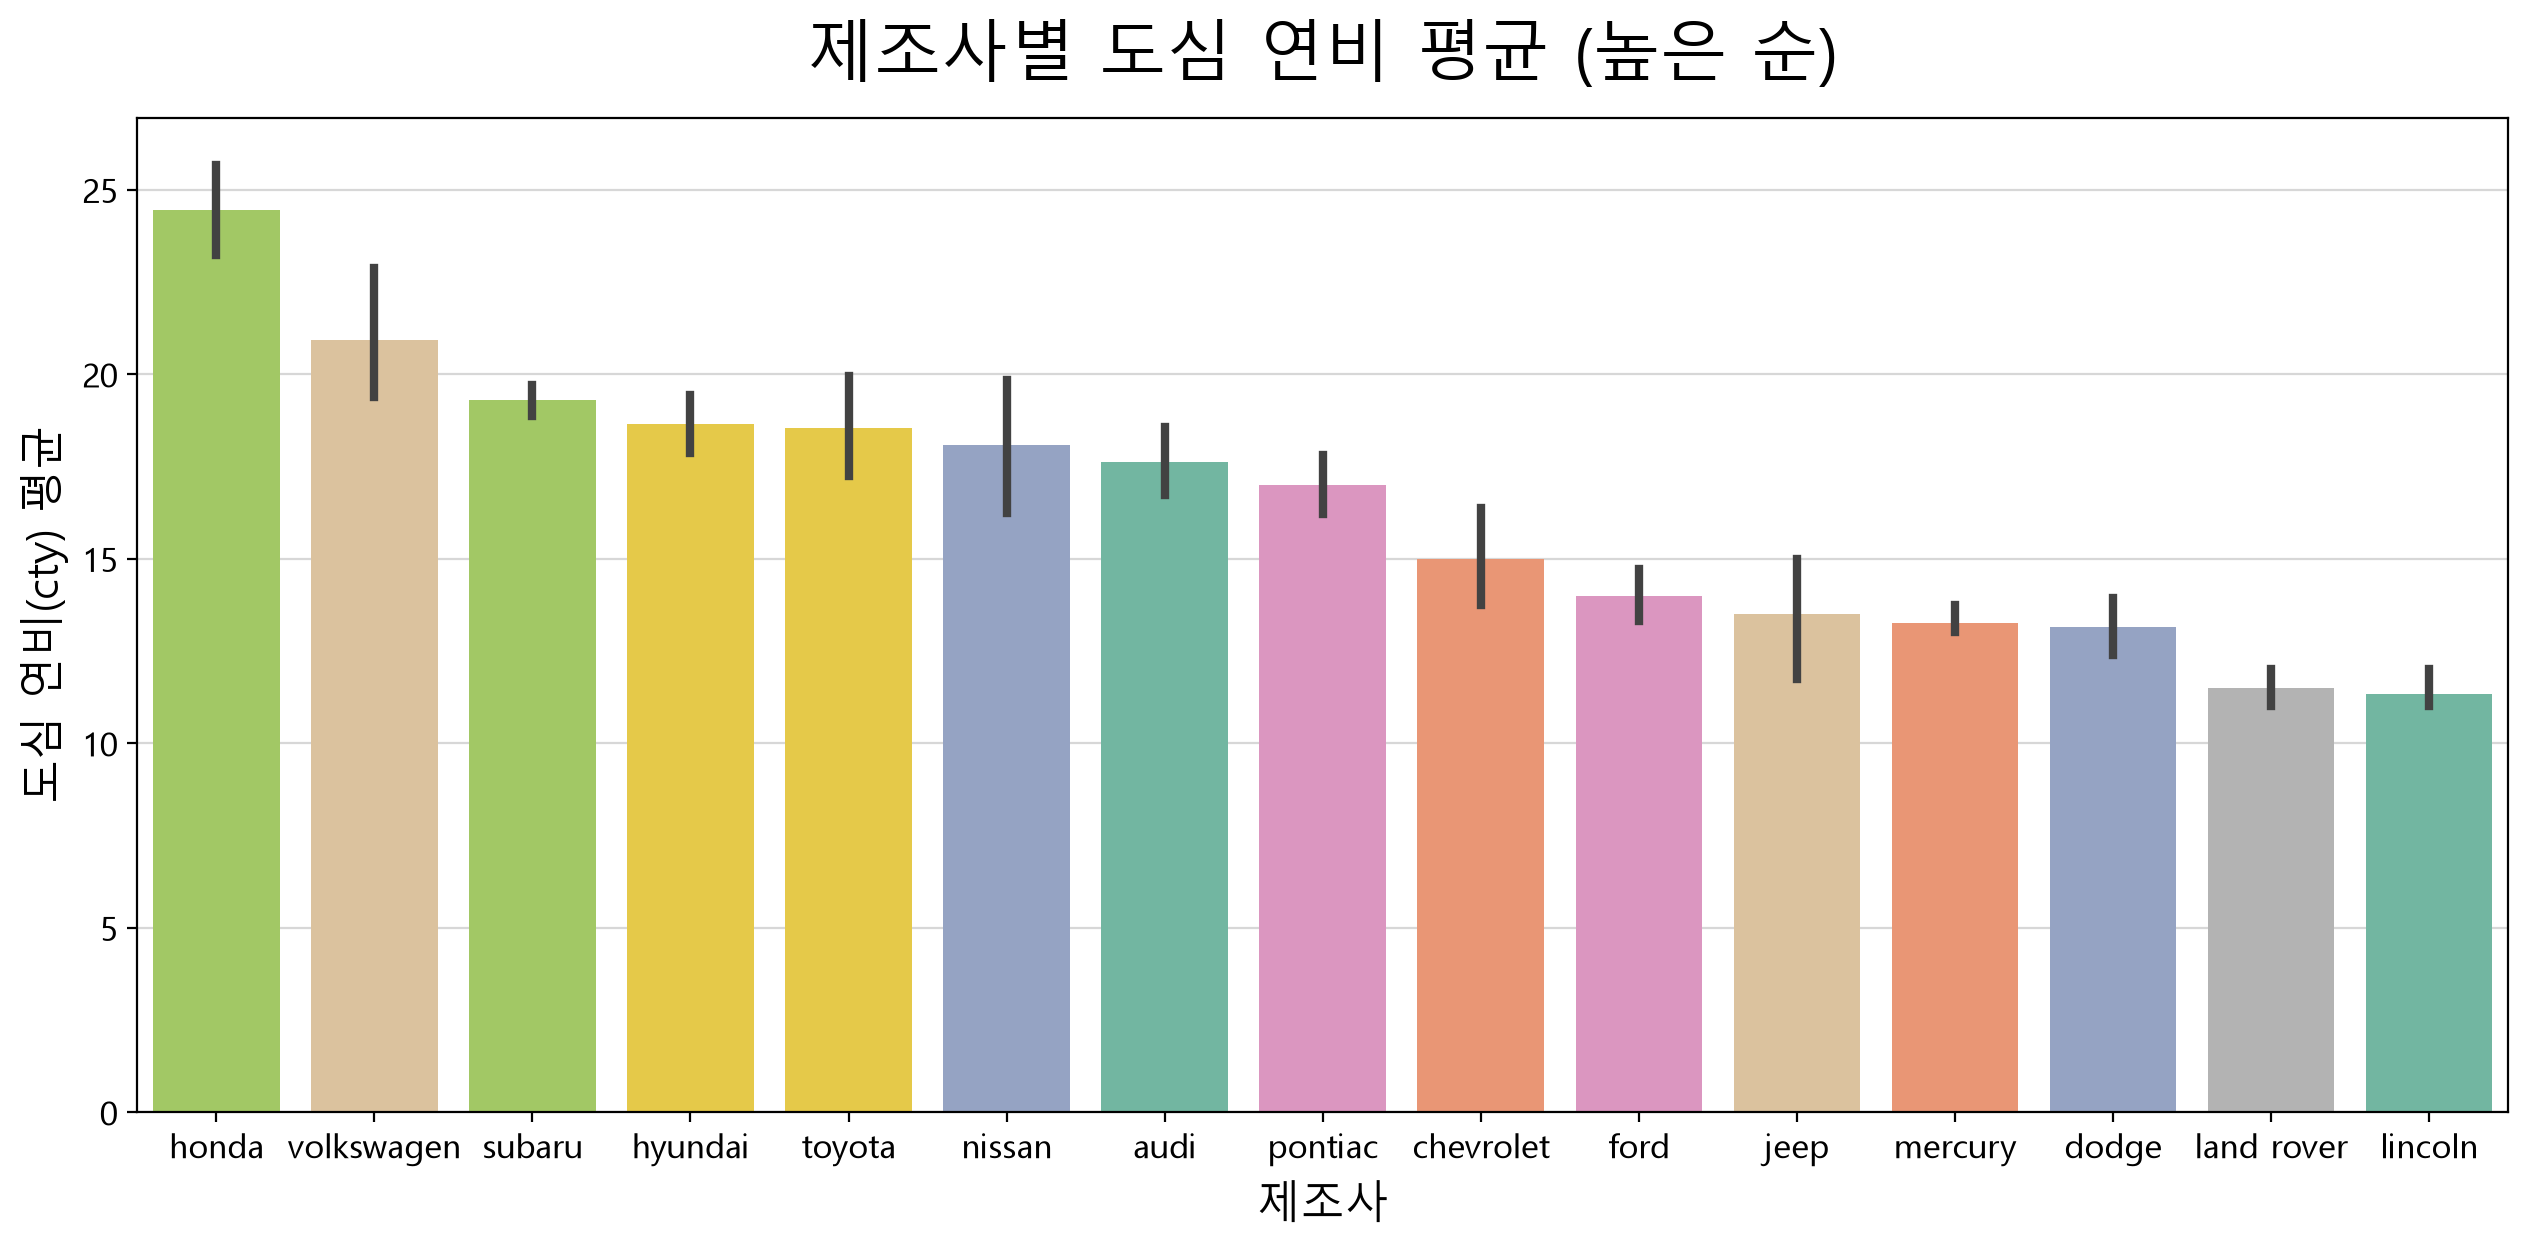

In [176]:
sorted = df.groupby("manufacturer")["cty"].mean().sort_values(ascending=False)

my_plot.barplot(data=df, x="manufacturer", y="cty",
                estimator="mean", hue="manufacturer", palette="Set2",
                order=sorted.index,
                title="제조사별 도심 연비 평균 (높은 순)", 
                xlabel="제조사", ylabel="도심 연비(cty) 평균")

## 문제 11. 고속도로 연비(`hwy`) 평균이 가장 낮은 제조사는?

① dodge  ② lincoln  ③ land rover  ④ jeep

> 💡 **힌트**: 막대그래프 (제조사별 hwy 평균)

- 내 답 : land rover

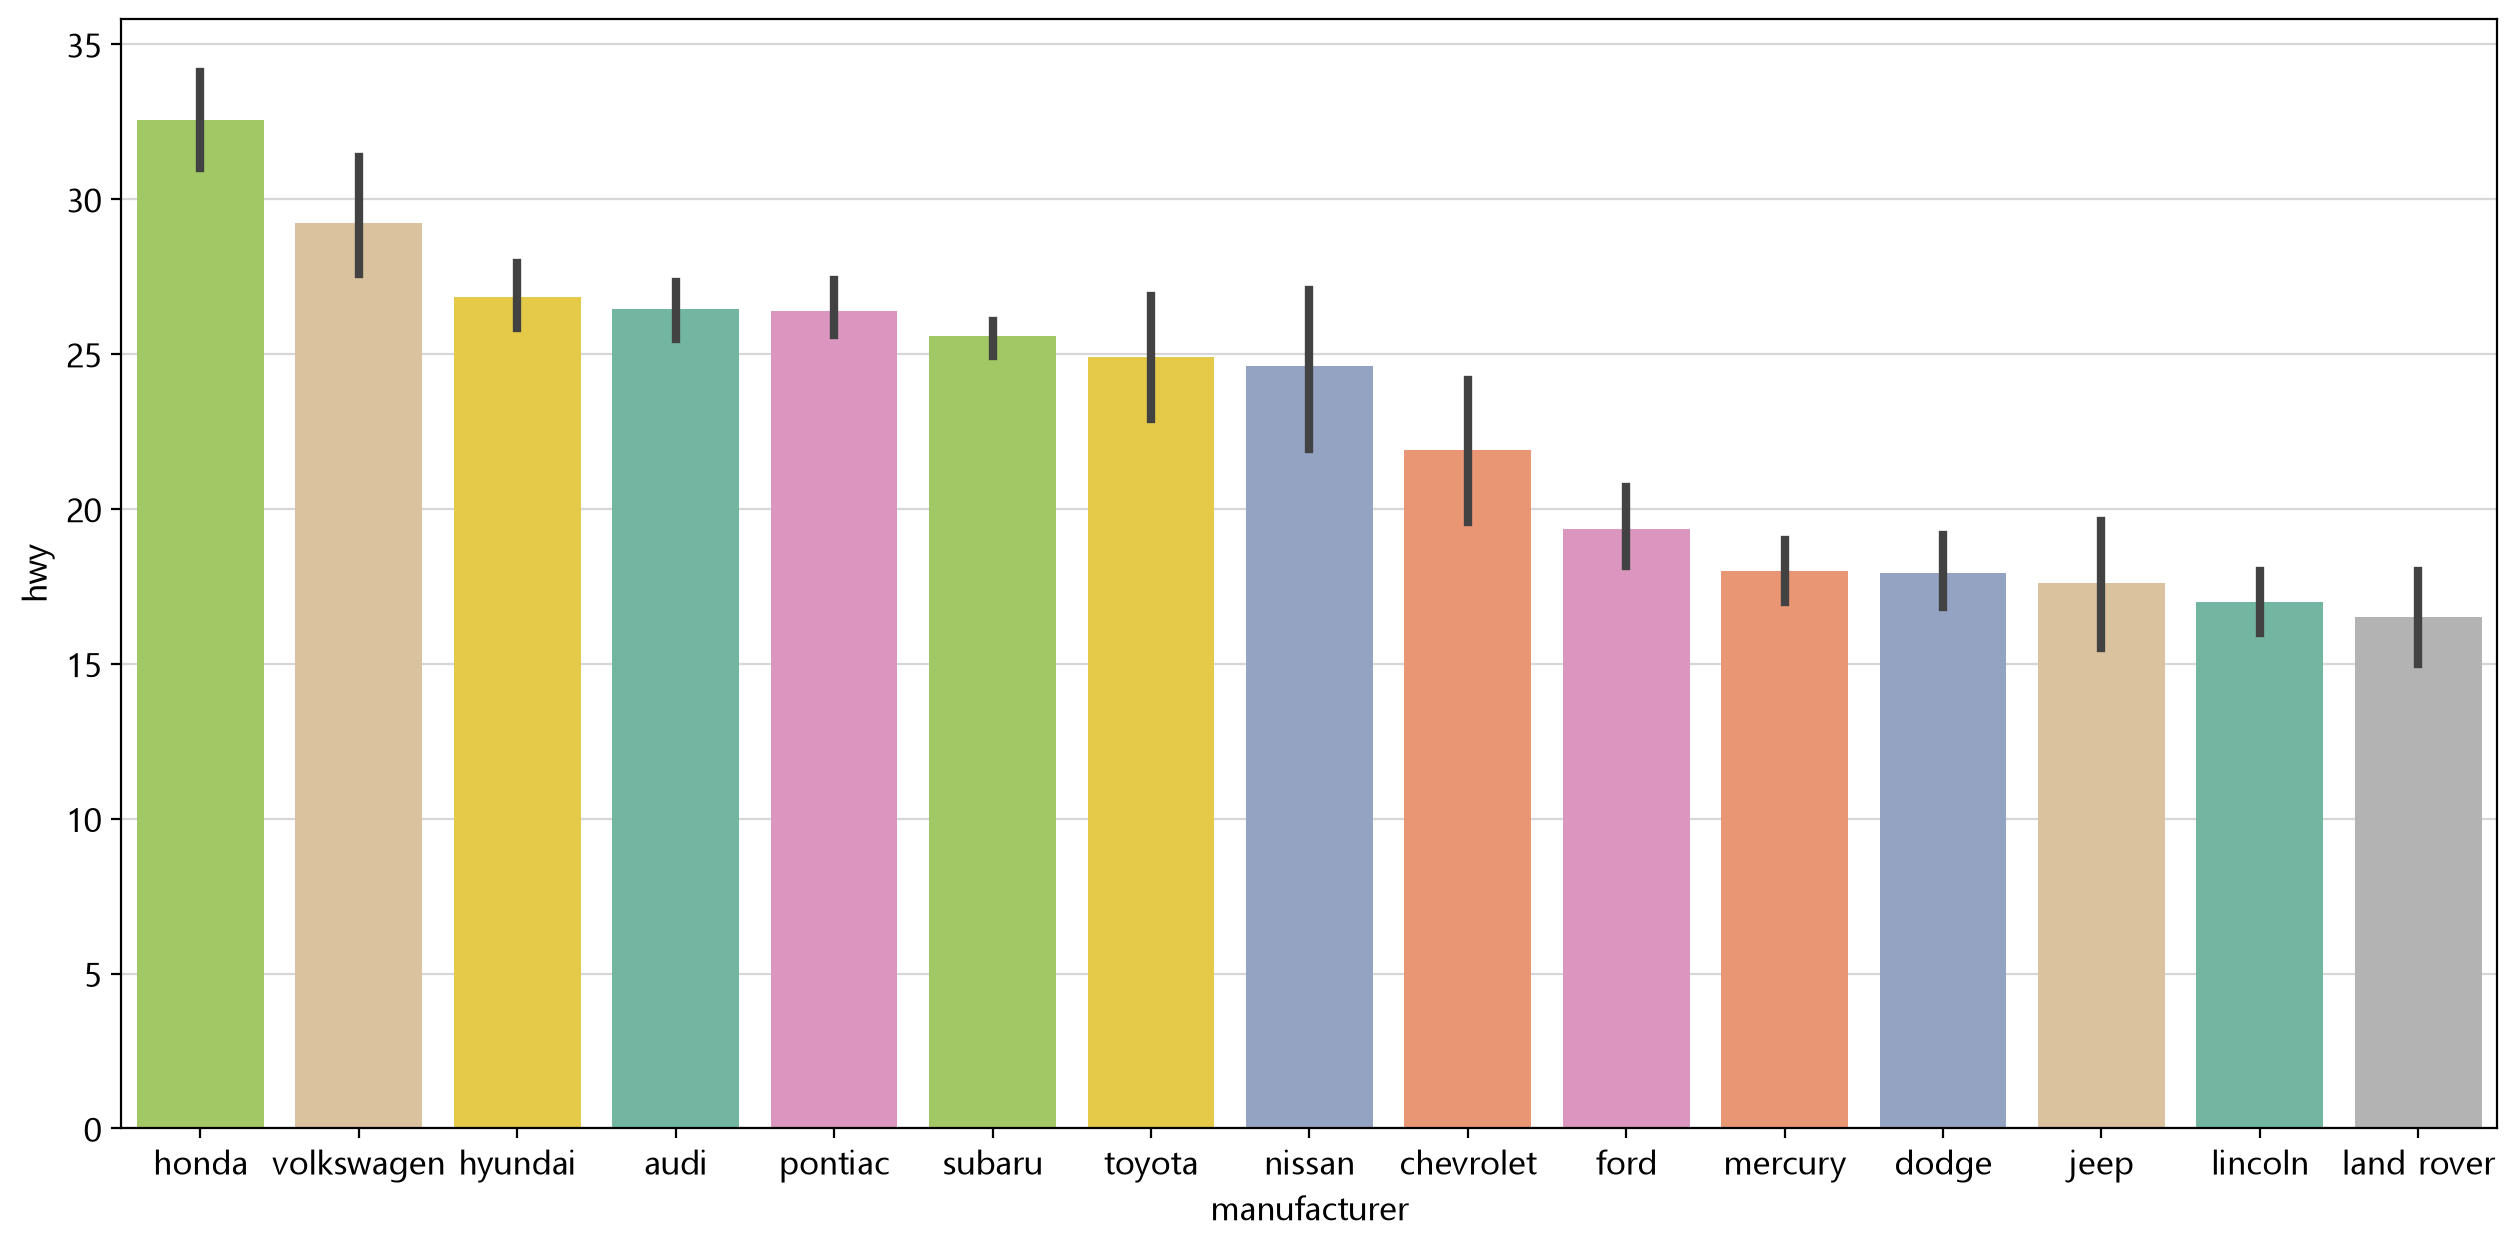

In [177]:
my_plot.barplot(data=df, x='manufacturer', y='hwy', hue='manufacturer', 
                palette='Set2', 
                order = df.groupby('manufacturer')['hwy'].mean().sort_values(ascending=False).index
)

## 문제 12. 변속기 종류(자동 vs 수동)에 따른 연비 비교로 옳은 것은?

① 자동이 수동보다 연비가 높다  ② 수동이 자동보다 연비가 높다  ③ 차이가 없다  ④ 도심은 자동, 고속도로는 수동이 높다

> 💡 **힌트**: 막대그래프 (`trans`를 auto/manual로 묶은 뒤 cty·hwy 평균)

- 내 답 : 수동이 자동보다 연비가 높다

In [178]:
df['trans_type'] = df['trans'].str.split('(').str[0]

In [179]:
df_cty = df.groupby('trans')['cty'].mean() 
df_cty

trans
auto(av)     20.000
auto(l3)     21.000
auto(l4)     15.940
auto(l5)     14.718
auto(l6)     13.667
auto(s4)     18.667
auto(s5)     17.333
auto(s6)     17.375
manual(m5)   19.259
manual(m6)   16.895
Name: cty, dtype: float64

In [180]:
df_hwy = df.groupby('trans')['hwy'].mean() 
df_hwy

trans
auto(av)     27.800
auto(l3)     27.000
auto(l4)     21.964
auto(l5)     20.718
auto(l6)     20.000
auto(s4)     25.667
auto(s5)     25.333
auto(s6)     25.188
manual(m5)   26.293
manual(m6)   24.211
Name: hwy, dtype: float64

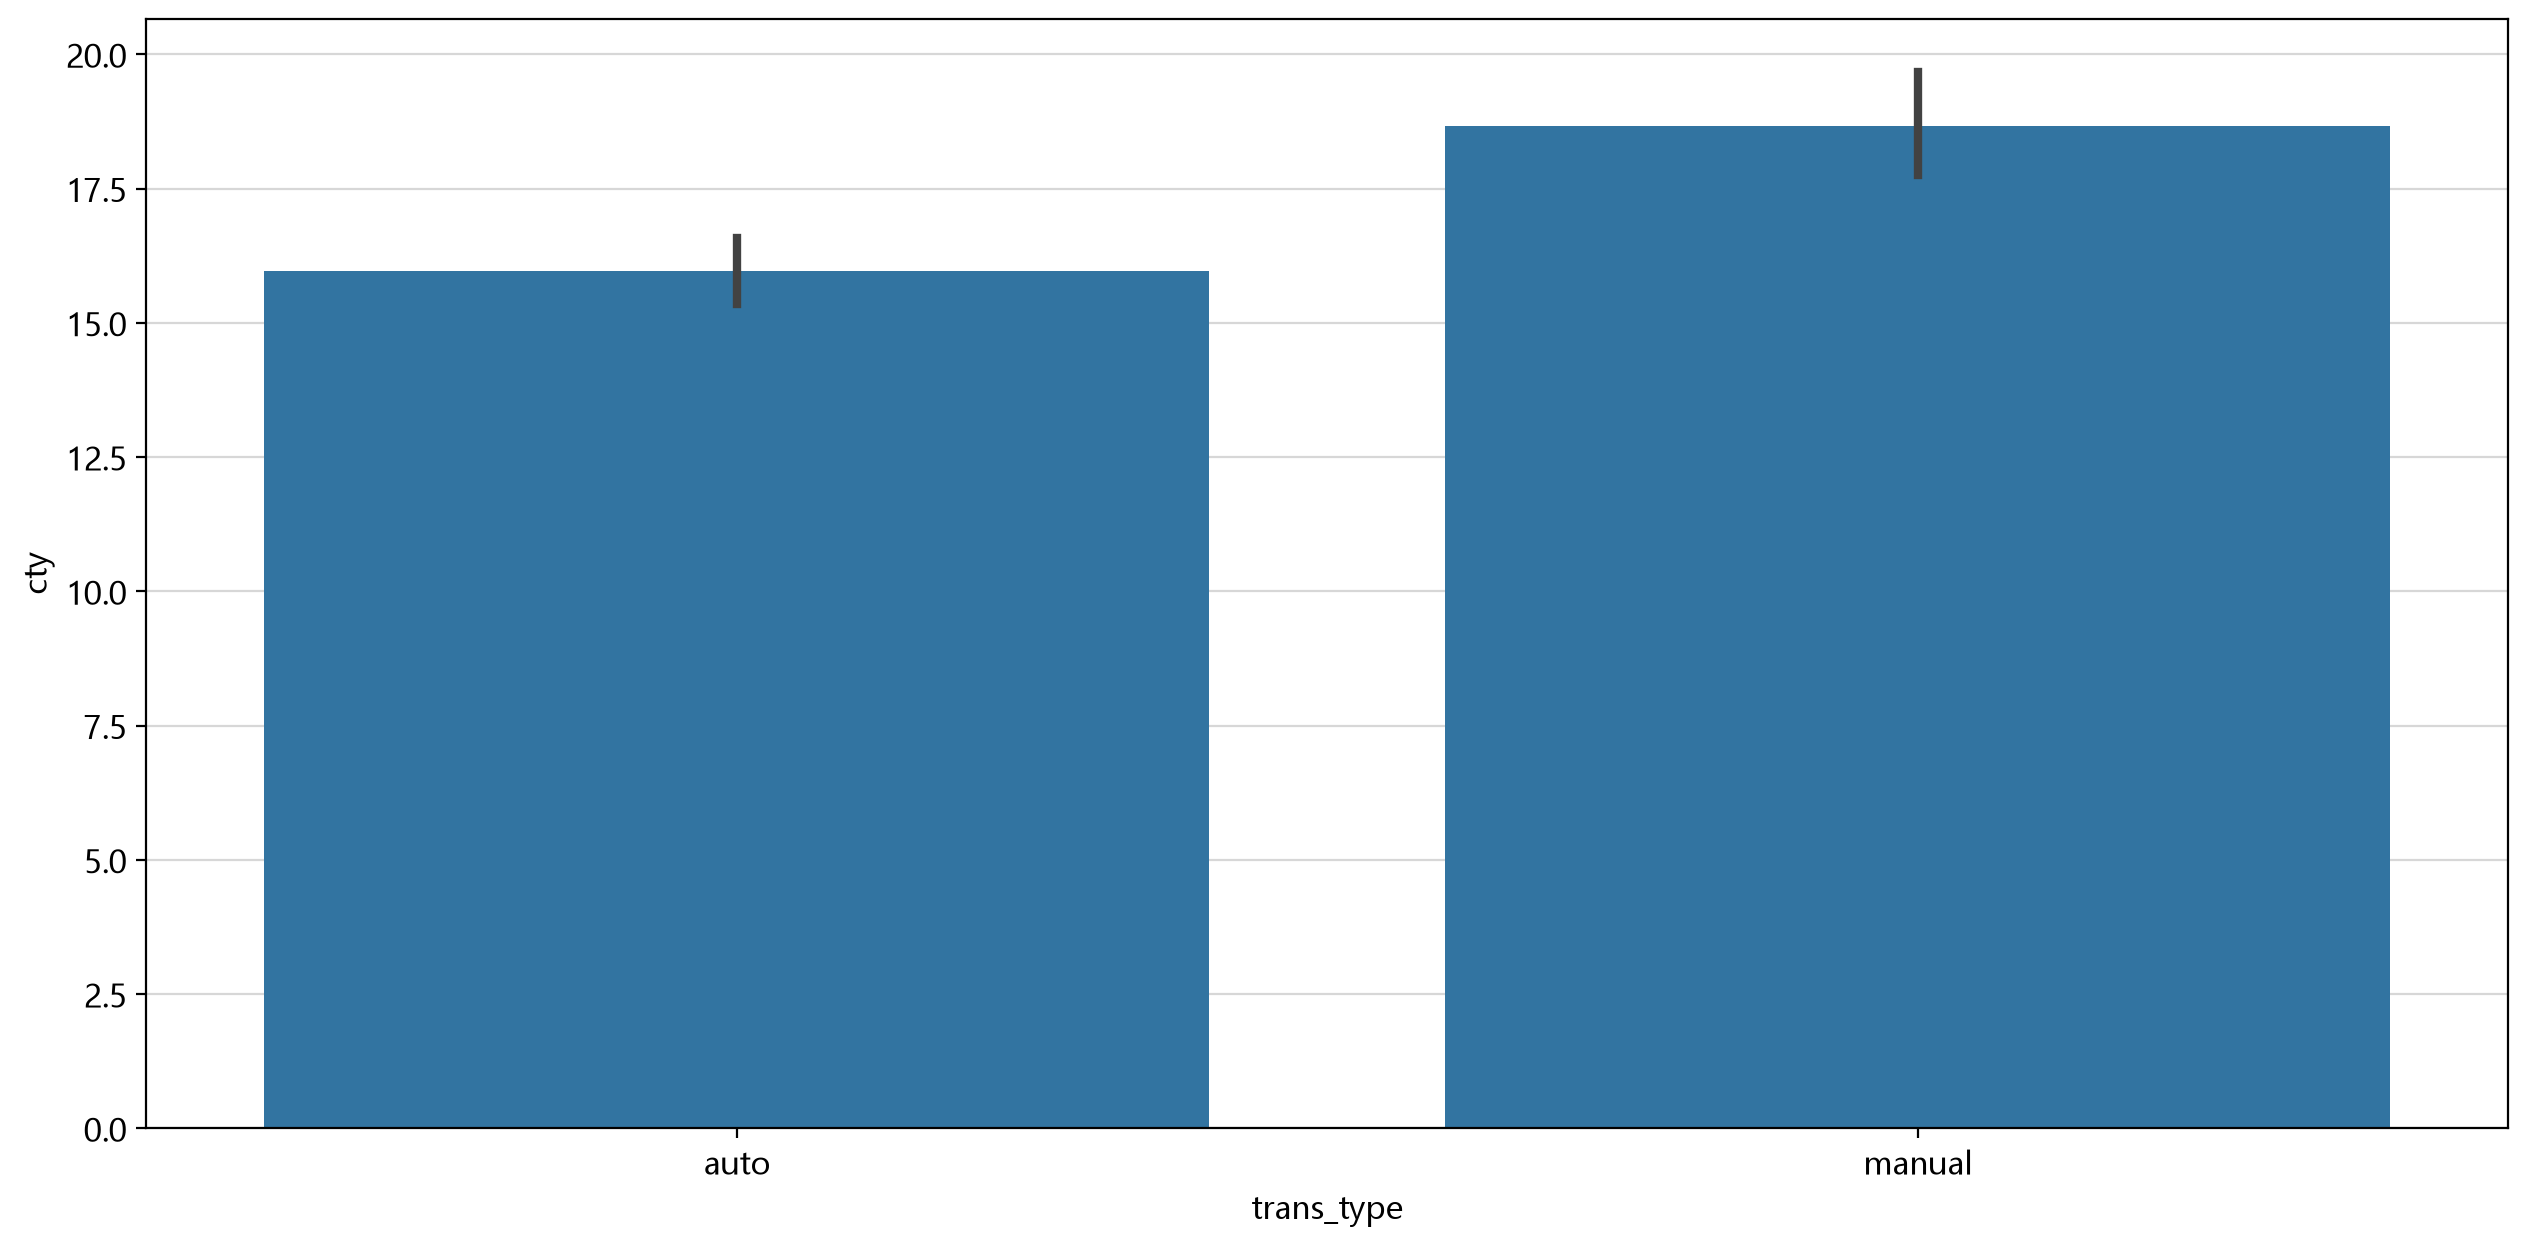

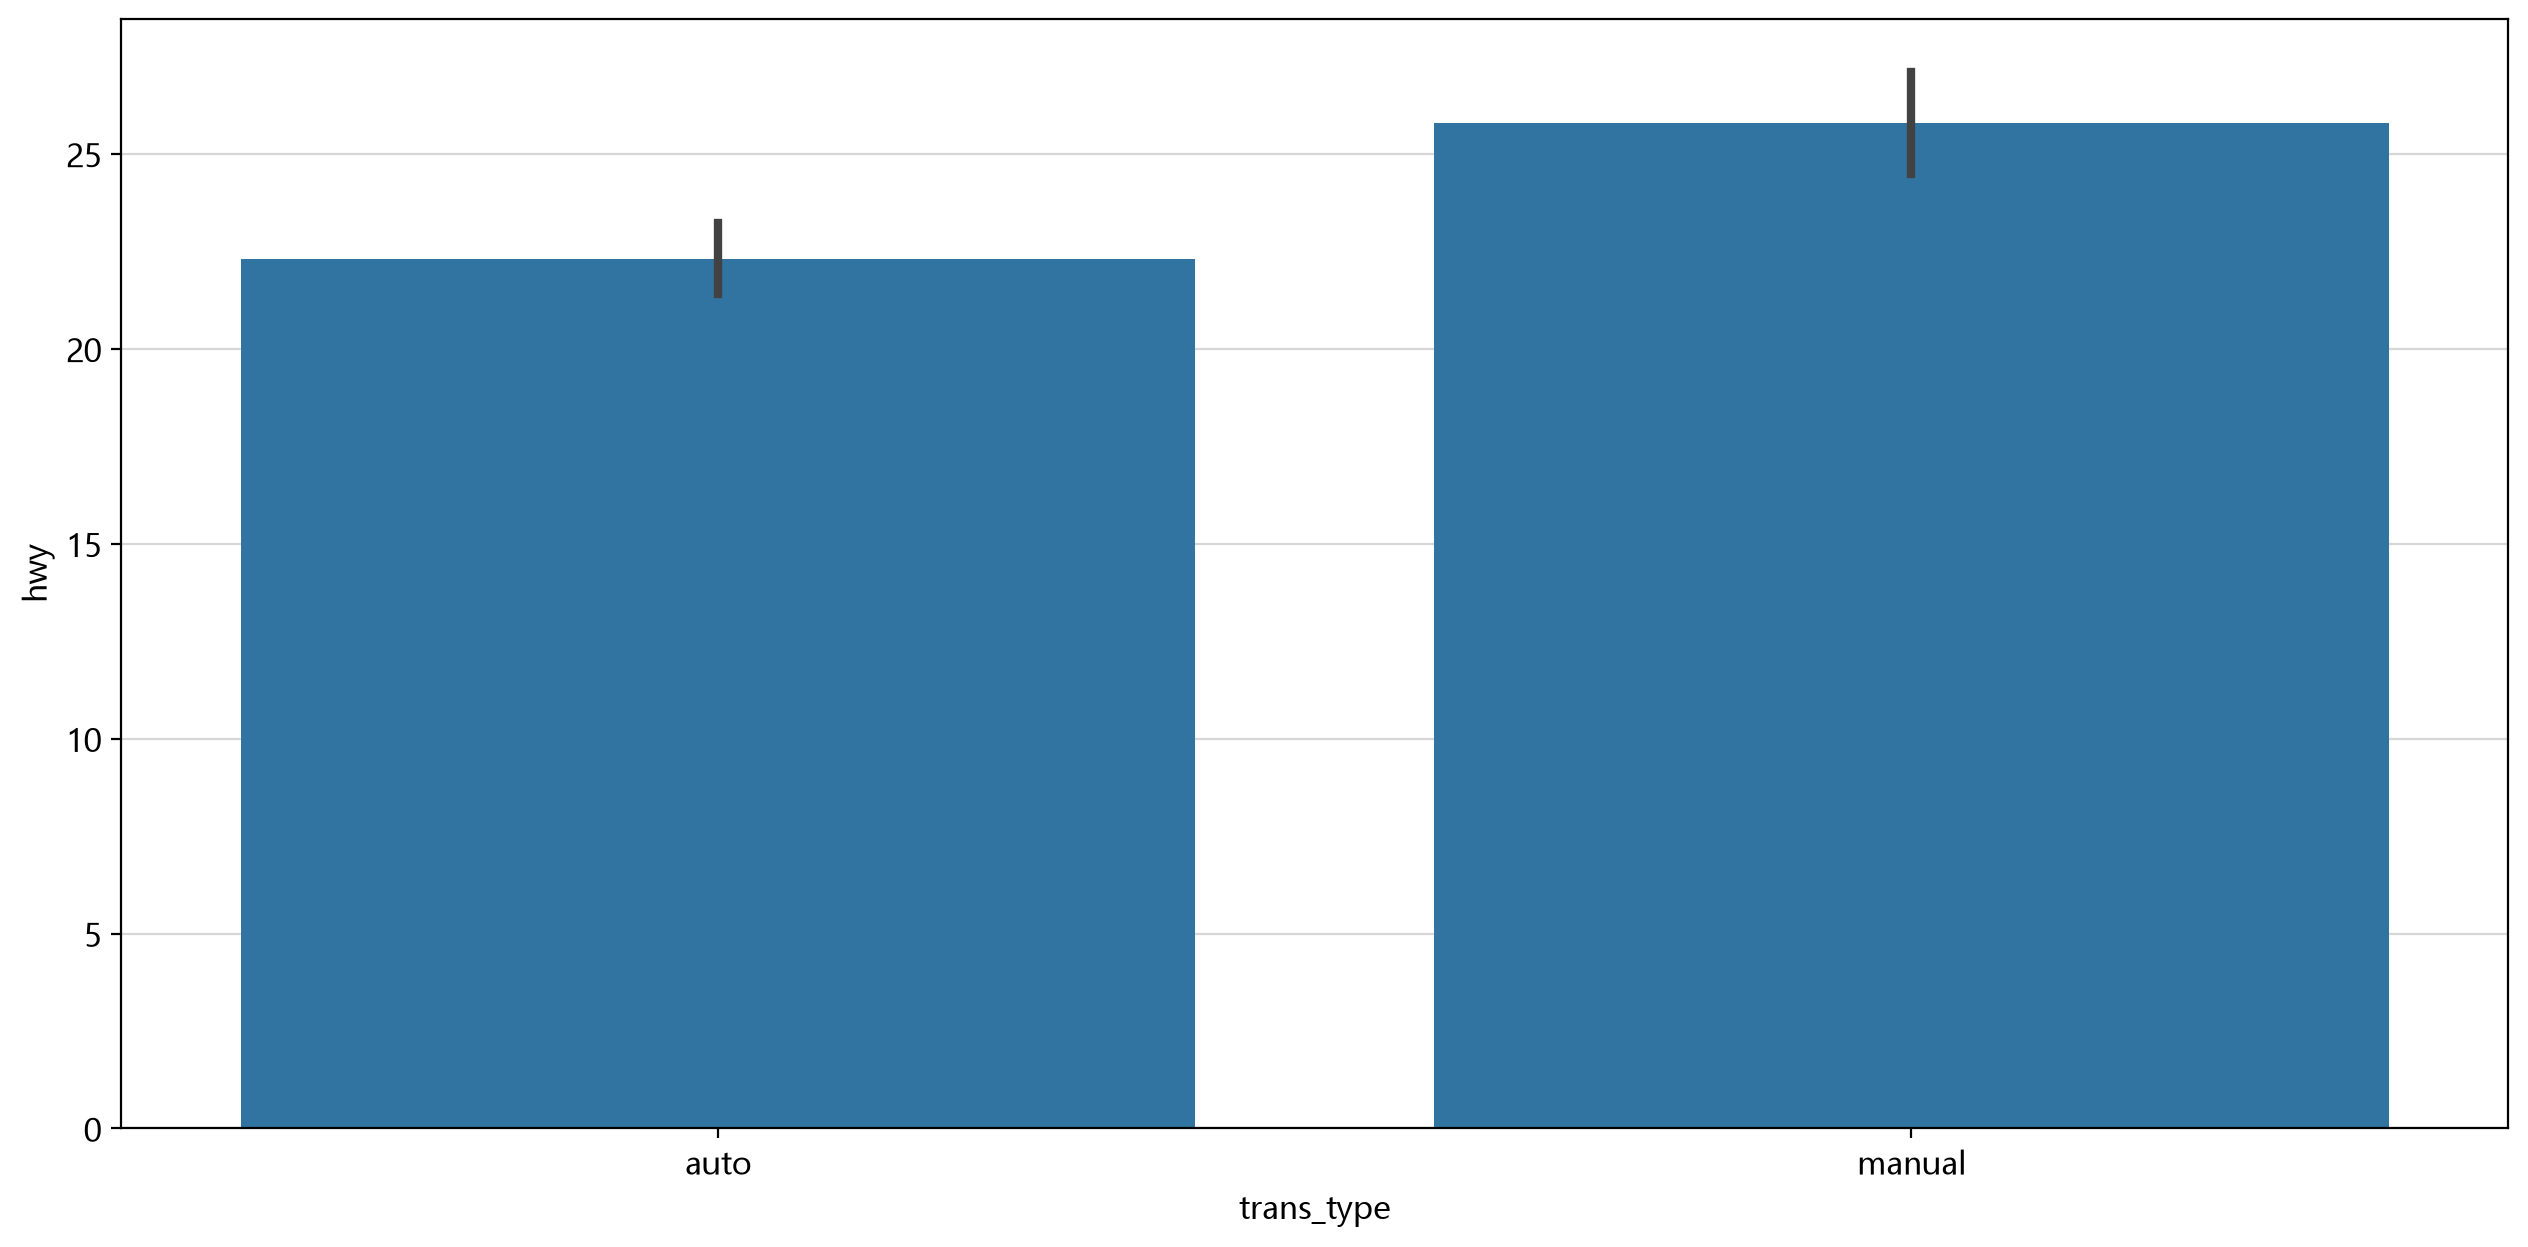

In [181]:
my_plot.barplot(data=df, x='trans_type', y='cty')
my_plot.barplot(data=df, x='trans_type', y='hwy')

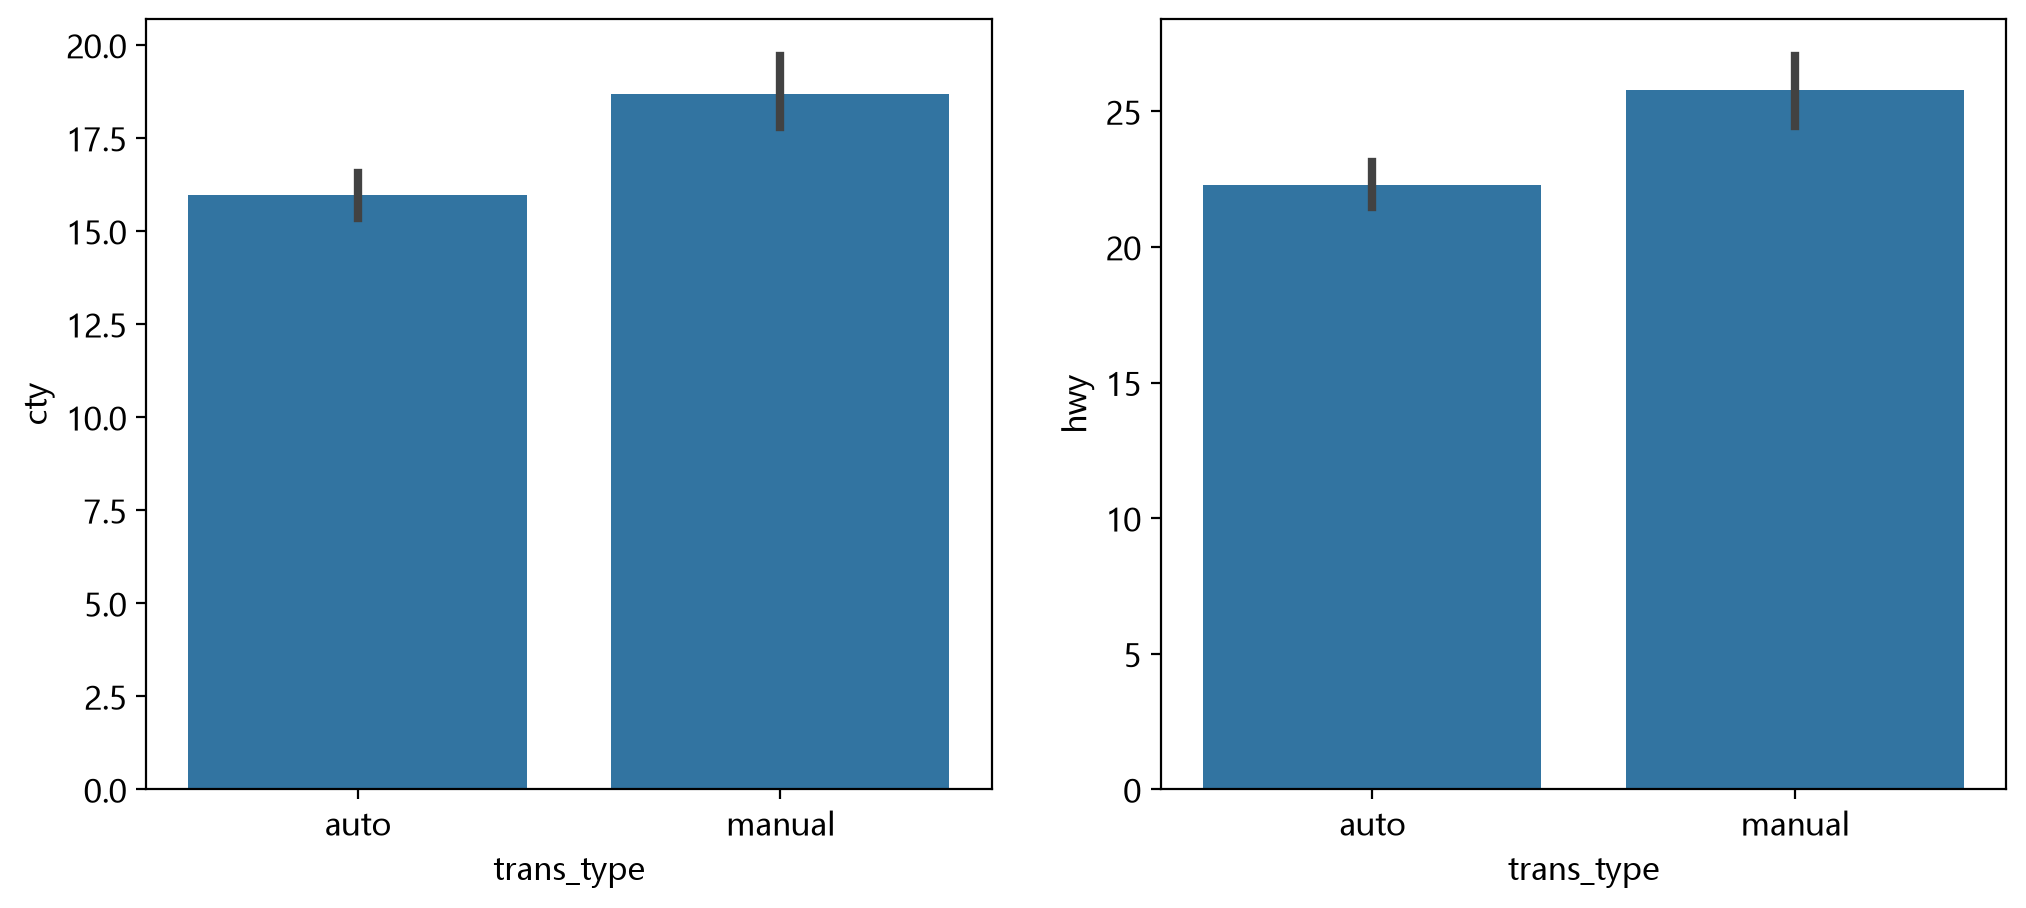

In [182]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

my_plot.barplot(data=df, x='trans_type', y='cty', ax=axes[0], title='연비(cty) 비교')
my_plot.barplot(data=df, x='trans_type', y='hwy', ax=axes[1], title='연비(hwy) 비교')

plt.show()

<Axes: xlabel='trans_type'>

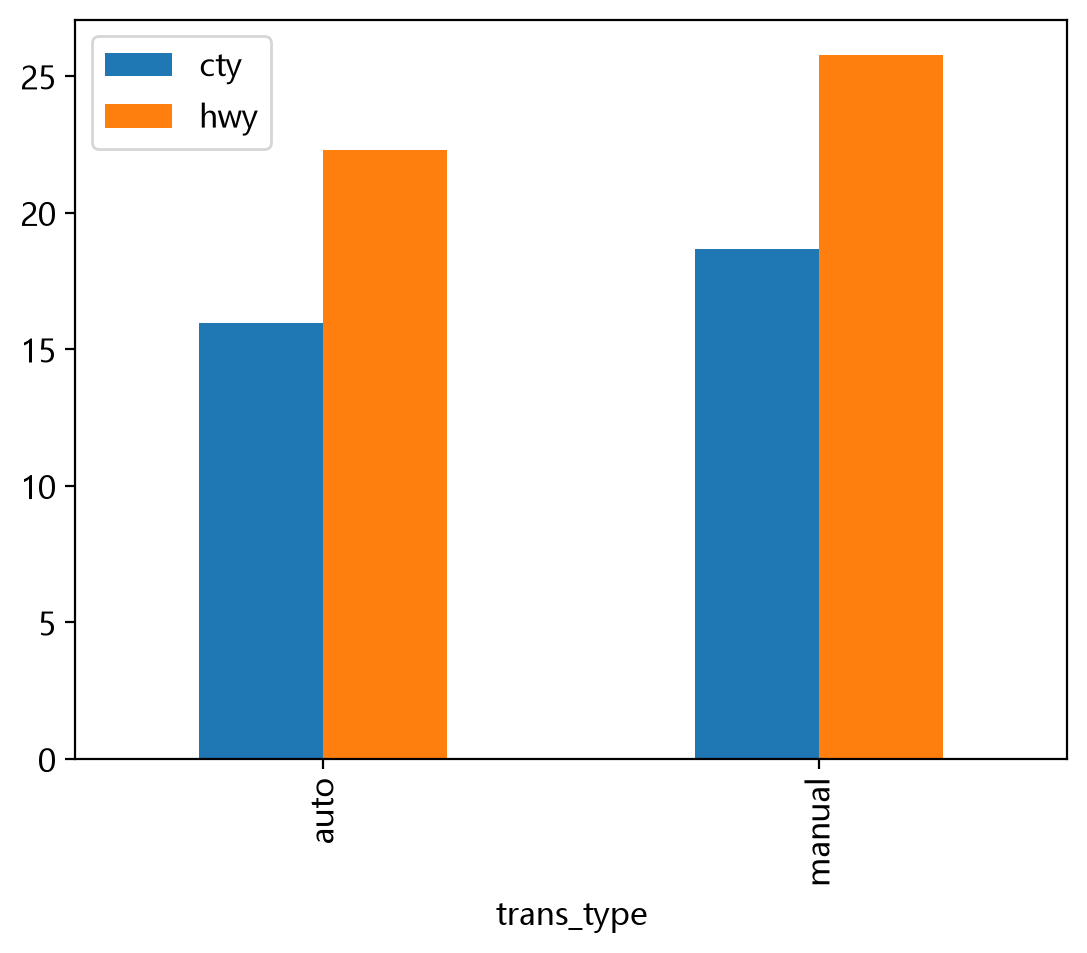

In [183]:
import pandas as pd

df_compare = pd.DataFrame({
    'cty': df.groupby('trans_type')['cty'].mean(),
    'hwy': df.groupby('trans_type')['hwy'].mean()
})

df_compare.plot(kind='bar')

## 문제 13. 가장 많이 사용된 연료(`fl`) 종류는?

① p (프리미엄)  ② r (레귤러)  ③ e (에탄올)  ④ d (디젤)

> 💡 **힌트**: 막대그래프 또는 원그래프 (연료별 빈도)

- 내 답 : r

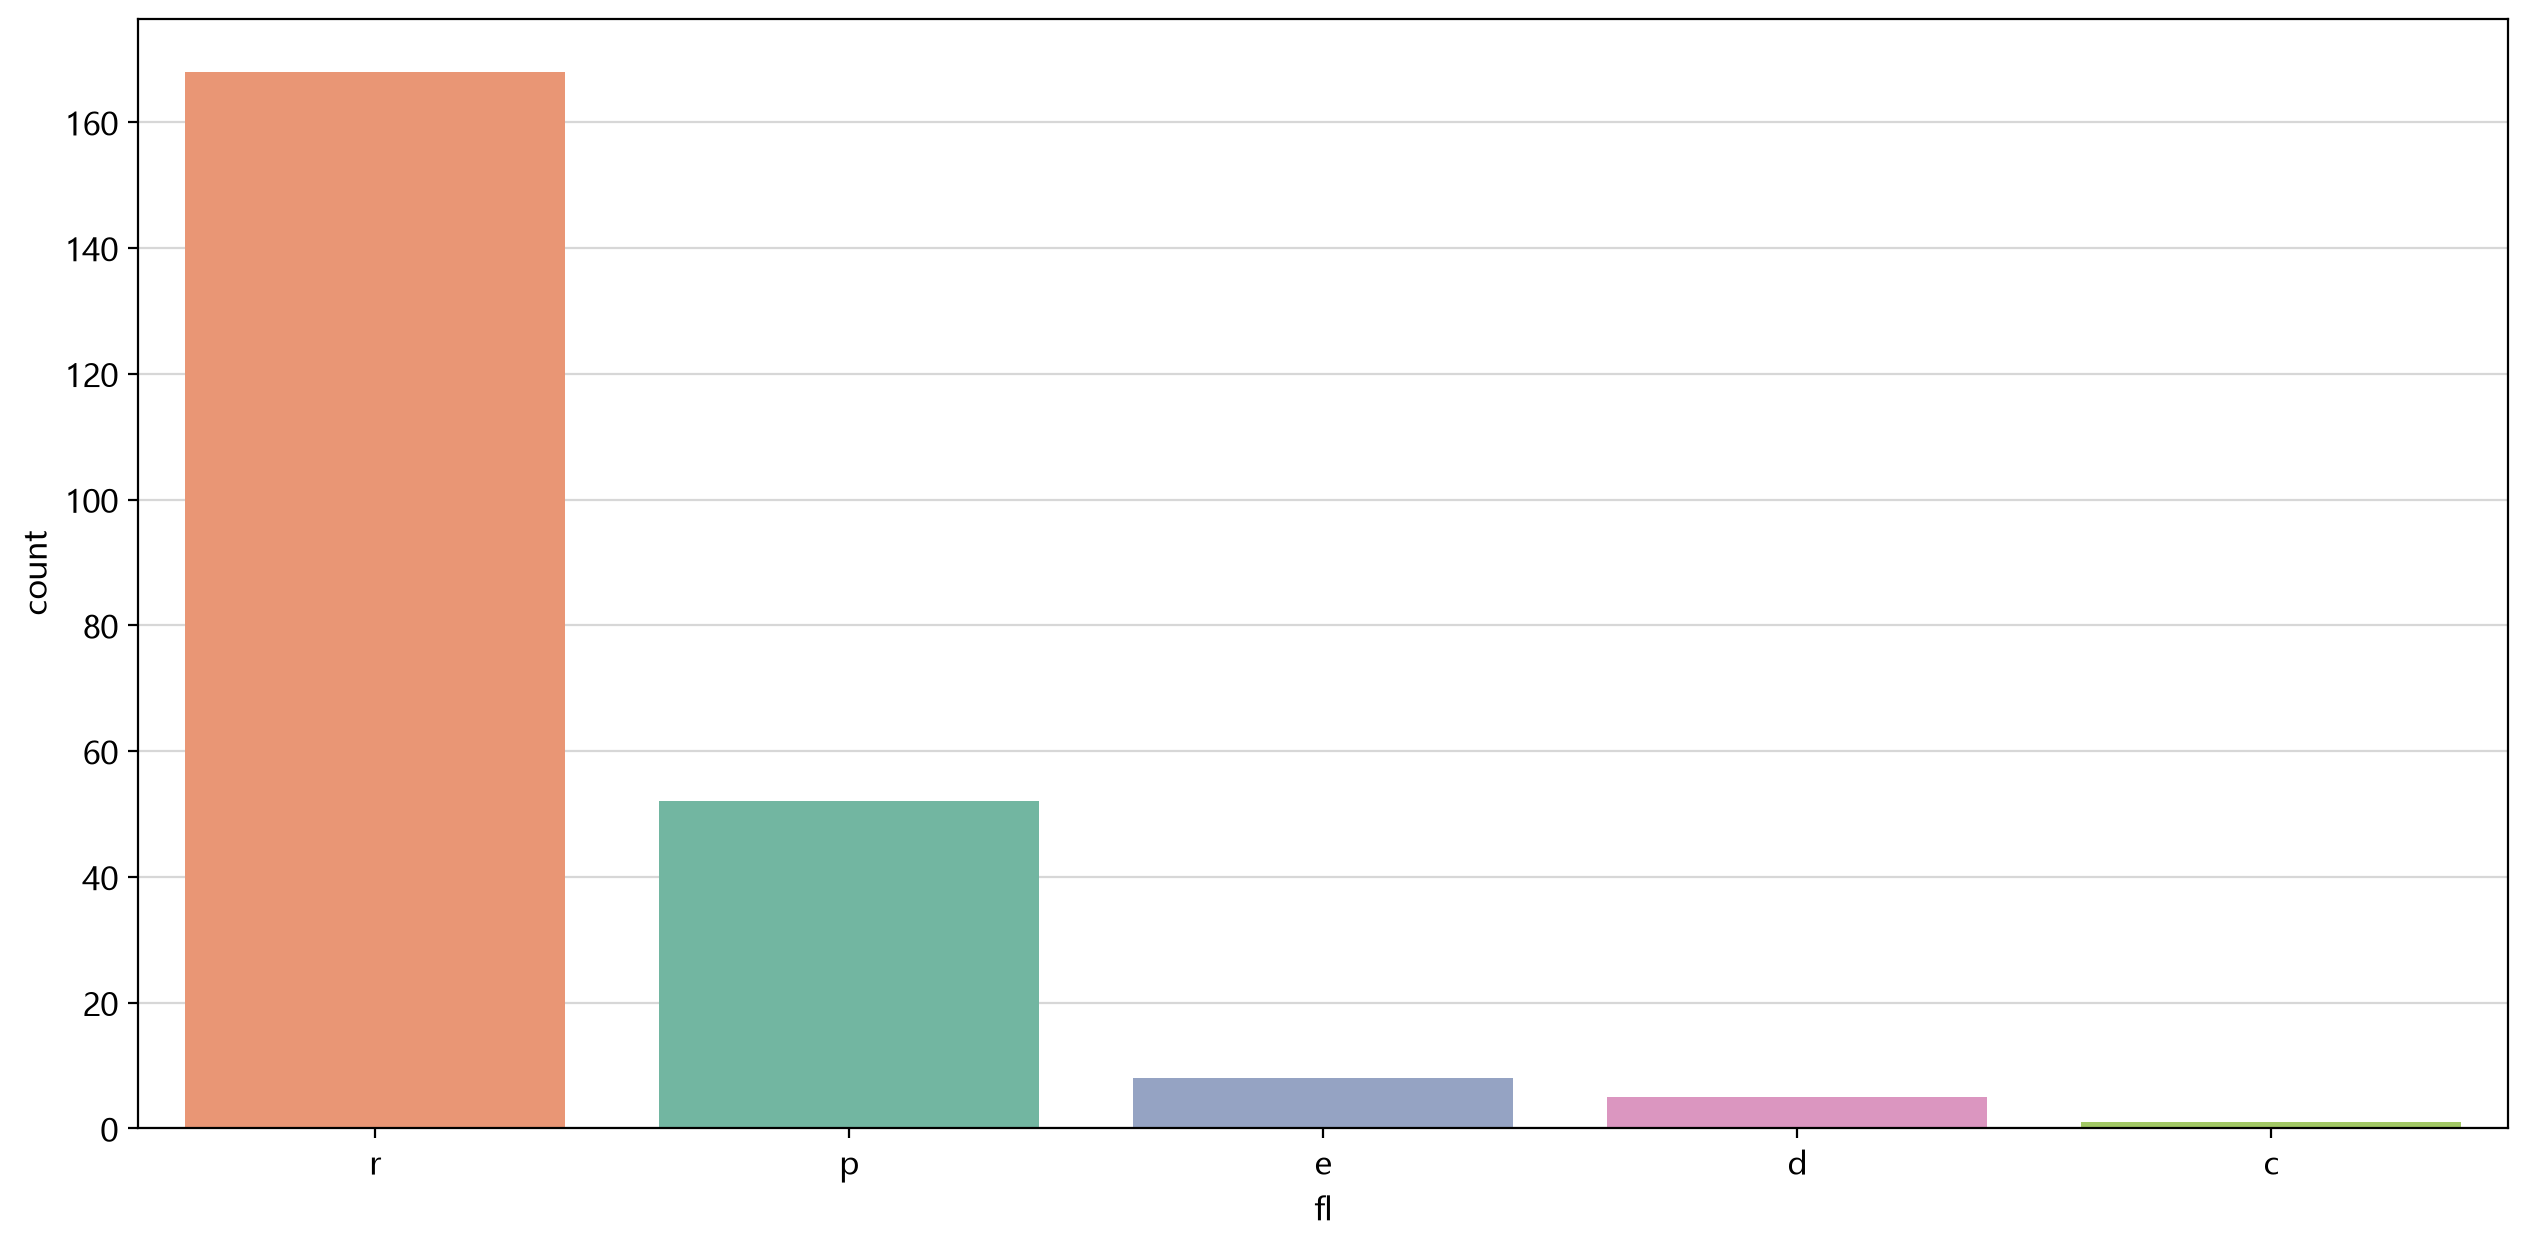

In [184]:
my_plot.countplot(data=df, x='fl', hue='fl', palette='Set2',
                order=df['fl'].value_counts().index,
                  ) 

## 문제 14. 1999년과 2008년의 평균 고속도로 연비(`hwy`)를 비교하면?

① 2008년이 크게 향상되었다  ② 1999년이 더 높다  ③ 거의 차이가 없다  ④ 2008년이 절반 수준이다

> 💡 **힌트**: 막대그래프 (연식별 hwy 평균)

- 내 답 : 거의 차이가 없다

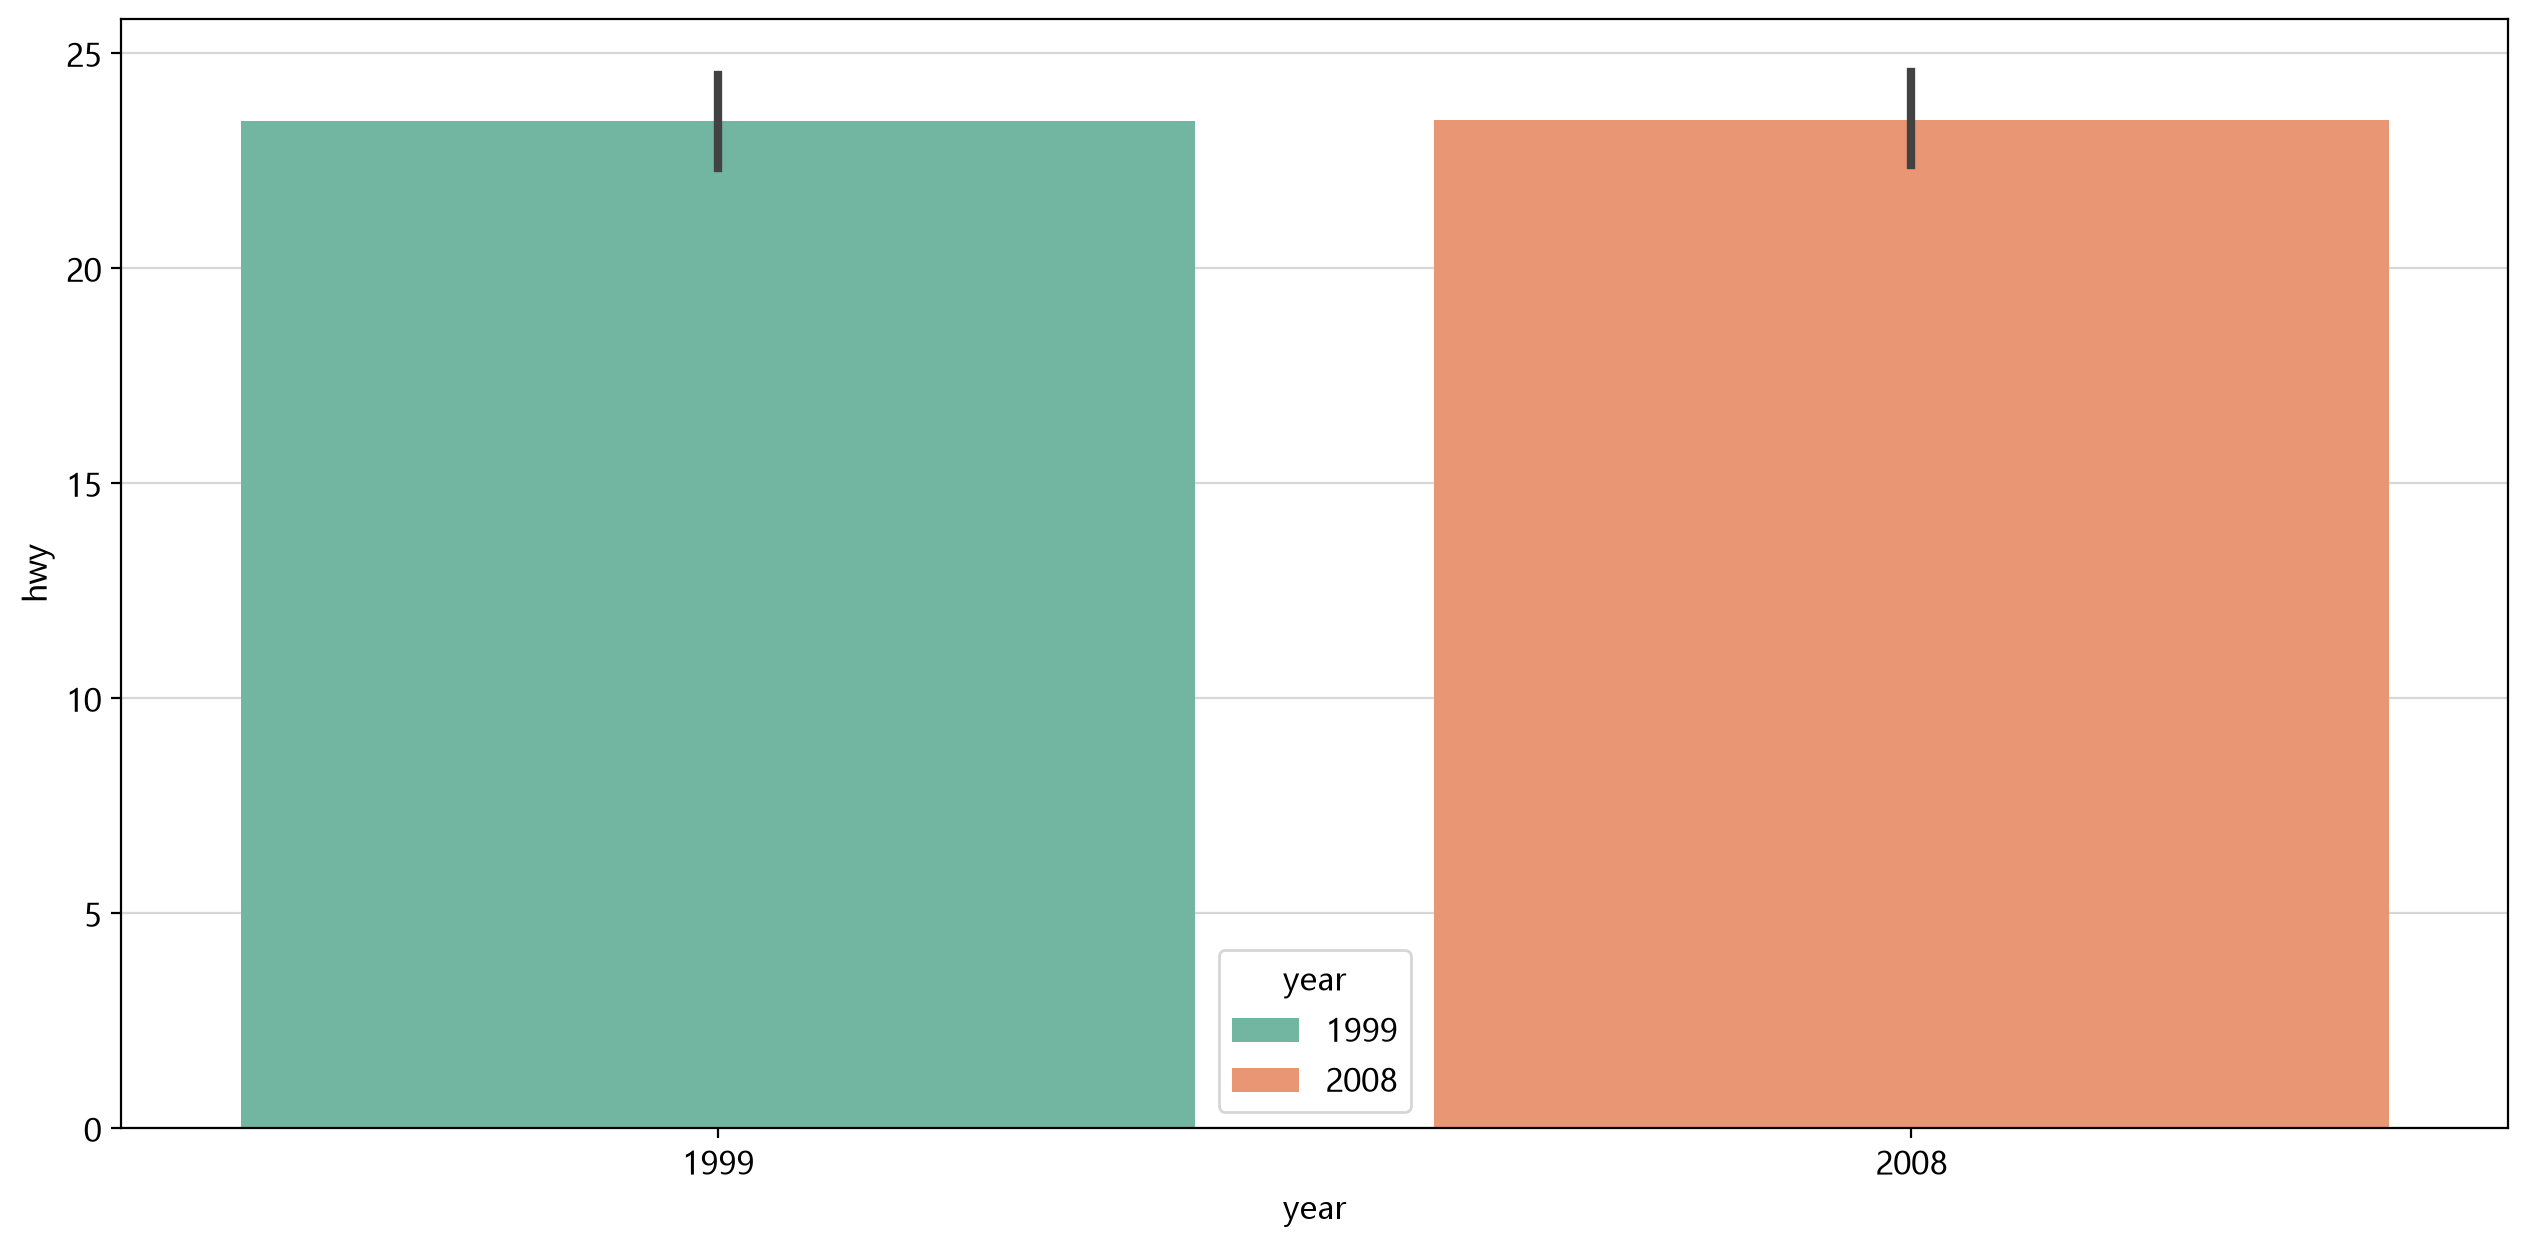

In [185]:
my_plot.barplot(data=df, x='year', y='hwy', hue='year', palette='Set2' #,order = df.groupby('year')['hwy'].mean().sort_values(ascending=False).index
)


In [186]:
df.groupby('year')['hwy'].mean()

year
1999   23.427
2008   23.453
Name: hwy, dtype: float64

## 문제 15. SUV 차종에는 존재하지 않는 구동방식은?

① 4륜구동  ② 후륜구동  ③ 전륜구동  ④ 모두 존재한다

> 💡 **힌트**: 막대그래프 (차종 SUV로 필터 후 구동방식별 빈도) 또는 교차표 시각화

- 내 답 : 모두 존재한다.

In [187]:
# 질문 문장을 조건절과 대상절로 쪼개는 습관을 들이면 이게 잡혀요:
# 조건절 (필터링 대상)대상절 (그 안에서 볼 것)SUV 차종에는존재하지 않는 구동방식은?
# "~에는"이라는 말이 나오면 그게 필터링 조건이에요.

# 일반화하면
# 앞으로 문제 읽을 때 이 순서로 가시면 돼요:

# 문장에서 "~에는", "~의", "~중" 같은 조건 표현을 찾는다 → 그게 필터링 대상
# 조건절과 대상절을 분리해서 표로 적어본다 (위 표처럼)
# 조건절부터 필터링 코드 짜고, 그 다음에 대상절 코드를 얹는다

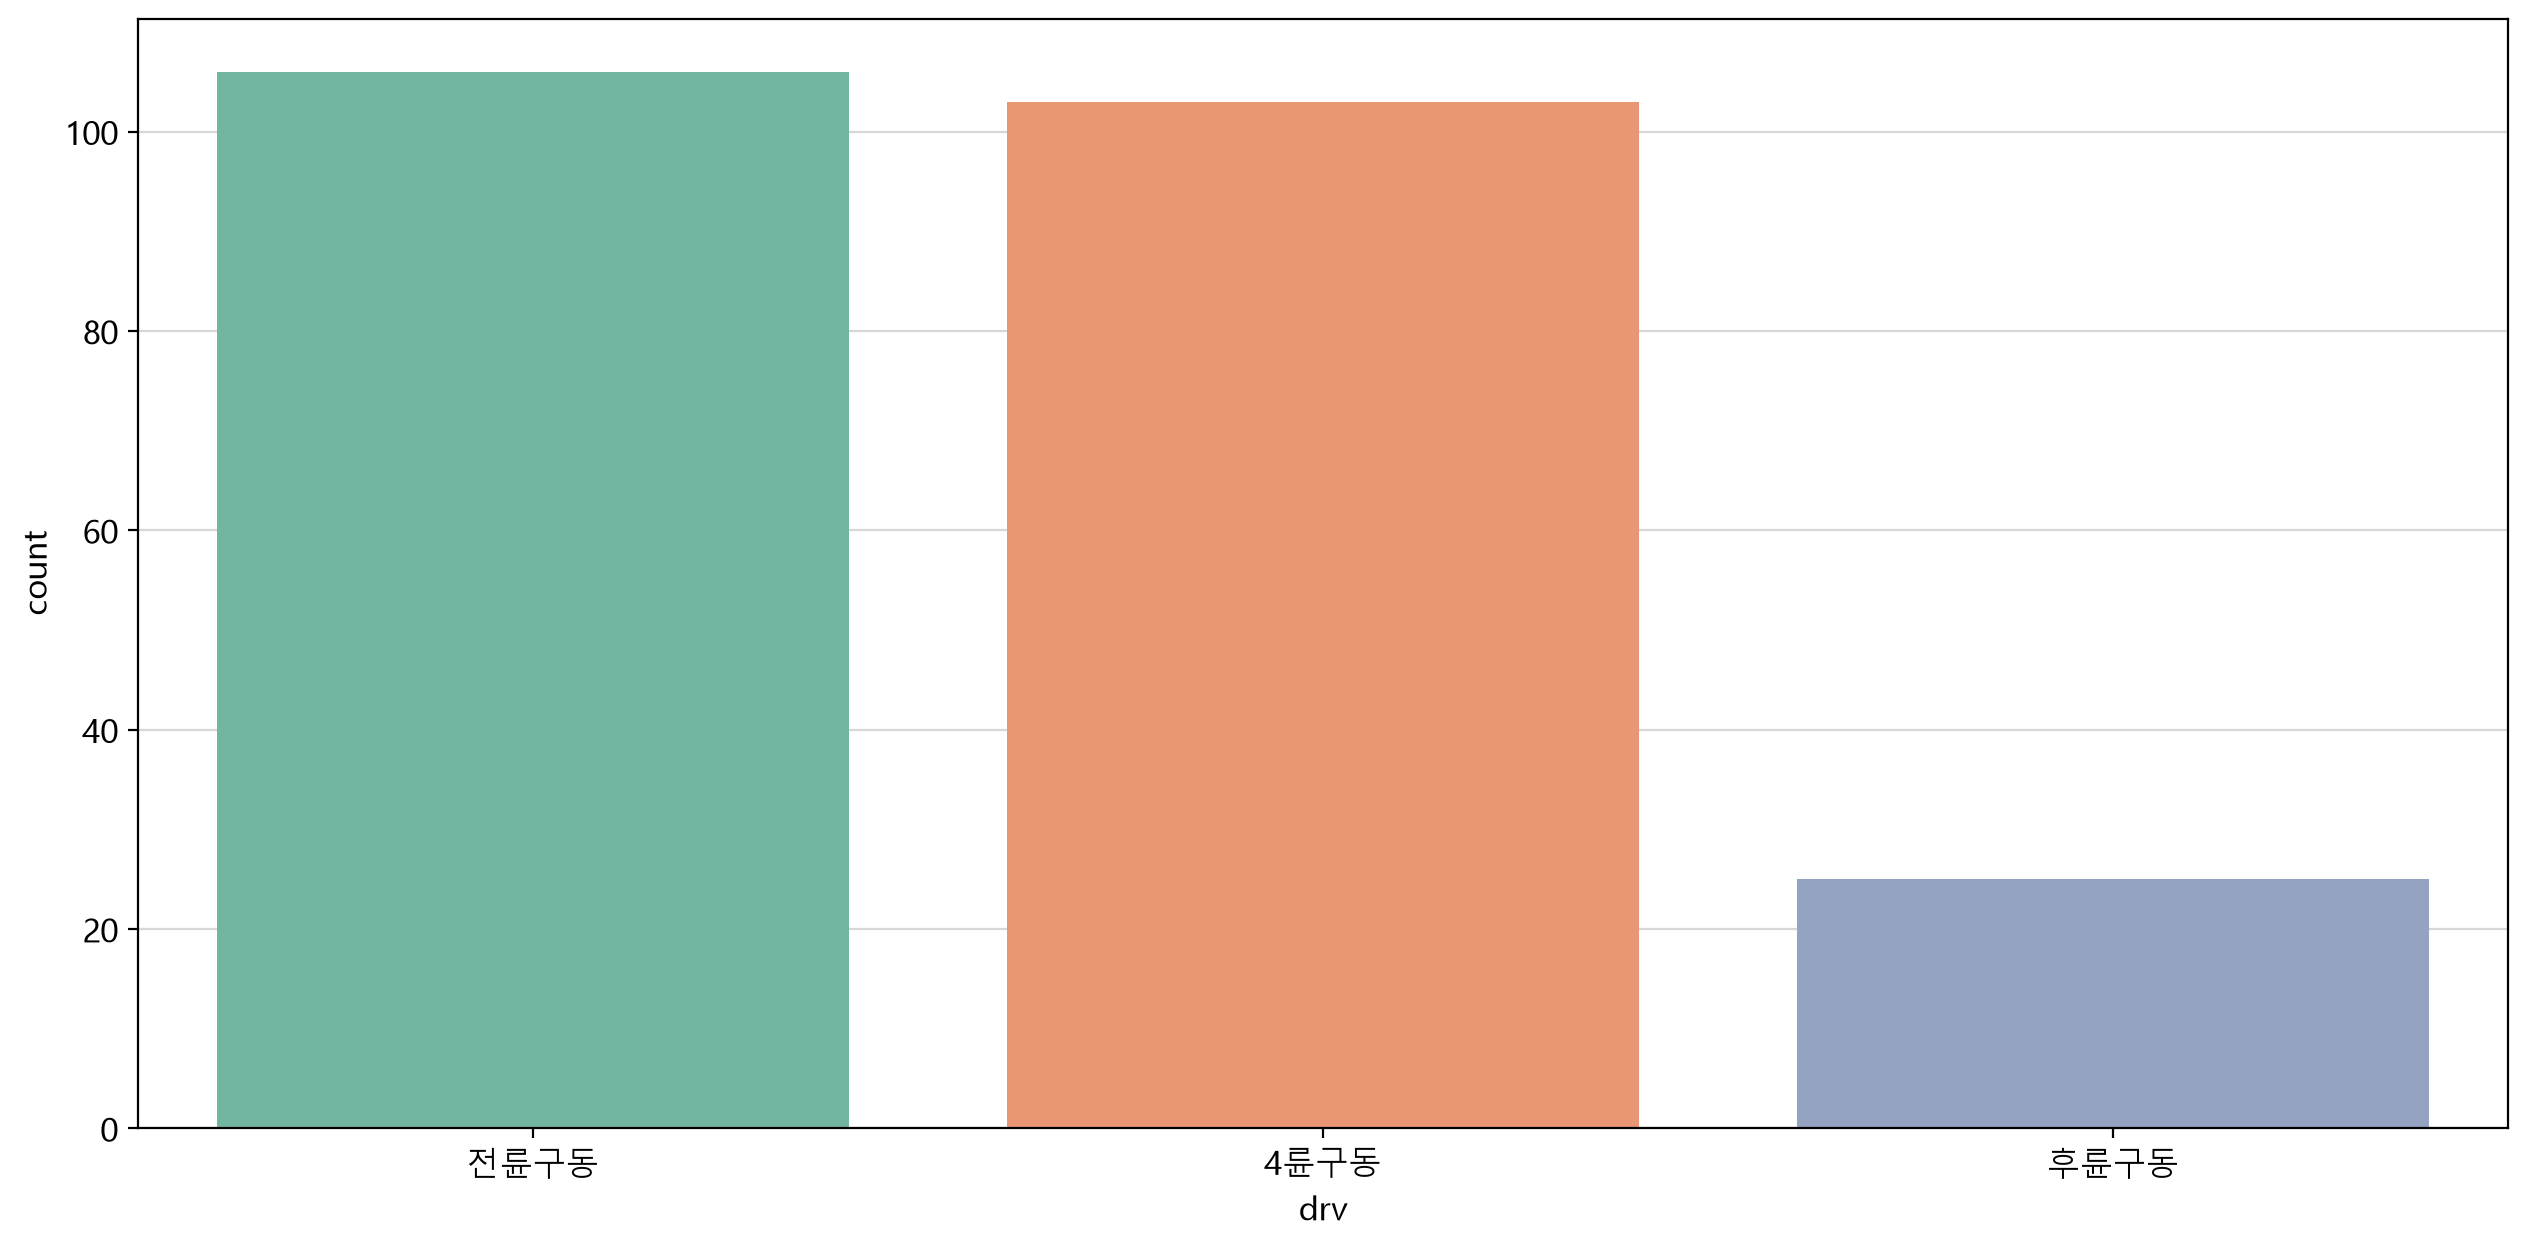

In [188]:
my_plot.countplot(data=df, x='drv', hue='drv', palette='Set2',
                order=df['drv'].value_counts().index,
                  ) 

## 문제 16. 픽업(pickup) 차종의 구동방식은?

① 모두 4륜구동  ② 모두 전륜구동  ③ 4륜·후륜 혼합  ④ 전륜·4륜 혼합

> 💡 **힌트**: 막대그래프 (차종 pickup으로 필터 후 구동방식별 빈도)

- 내 답 : 4륜 구동 

In [189]:
df1 =df[df['class']=='pickup'] # 바깥에 df[...]로 한 번 더 감싸야 실제로 그 조건에 맞는 행들만 뽑힌 DataFrame이 됨

In [190]:
df1['drv'].value_counts() # 그래프 그리기 전에 숫자로 먼저 확인해보는 습관 

drv
4륜구동    33
Name: count, dtype: int64

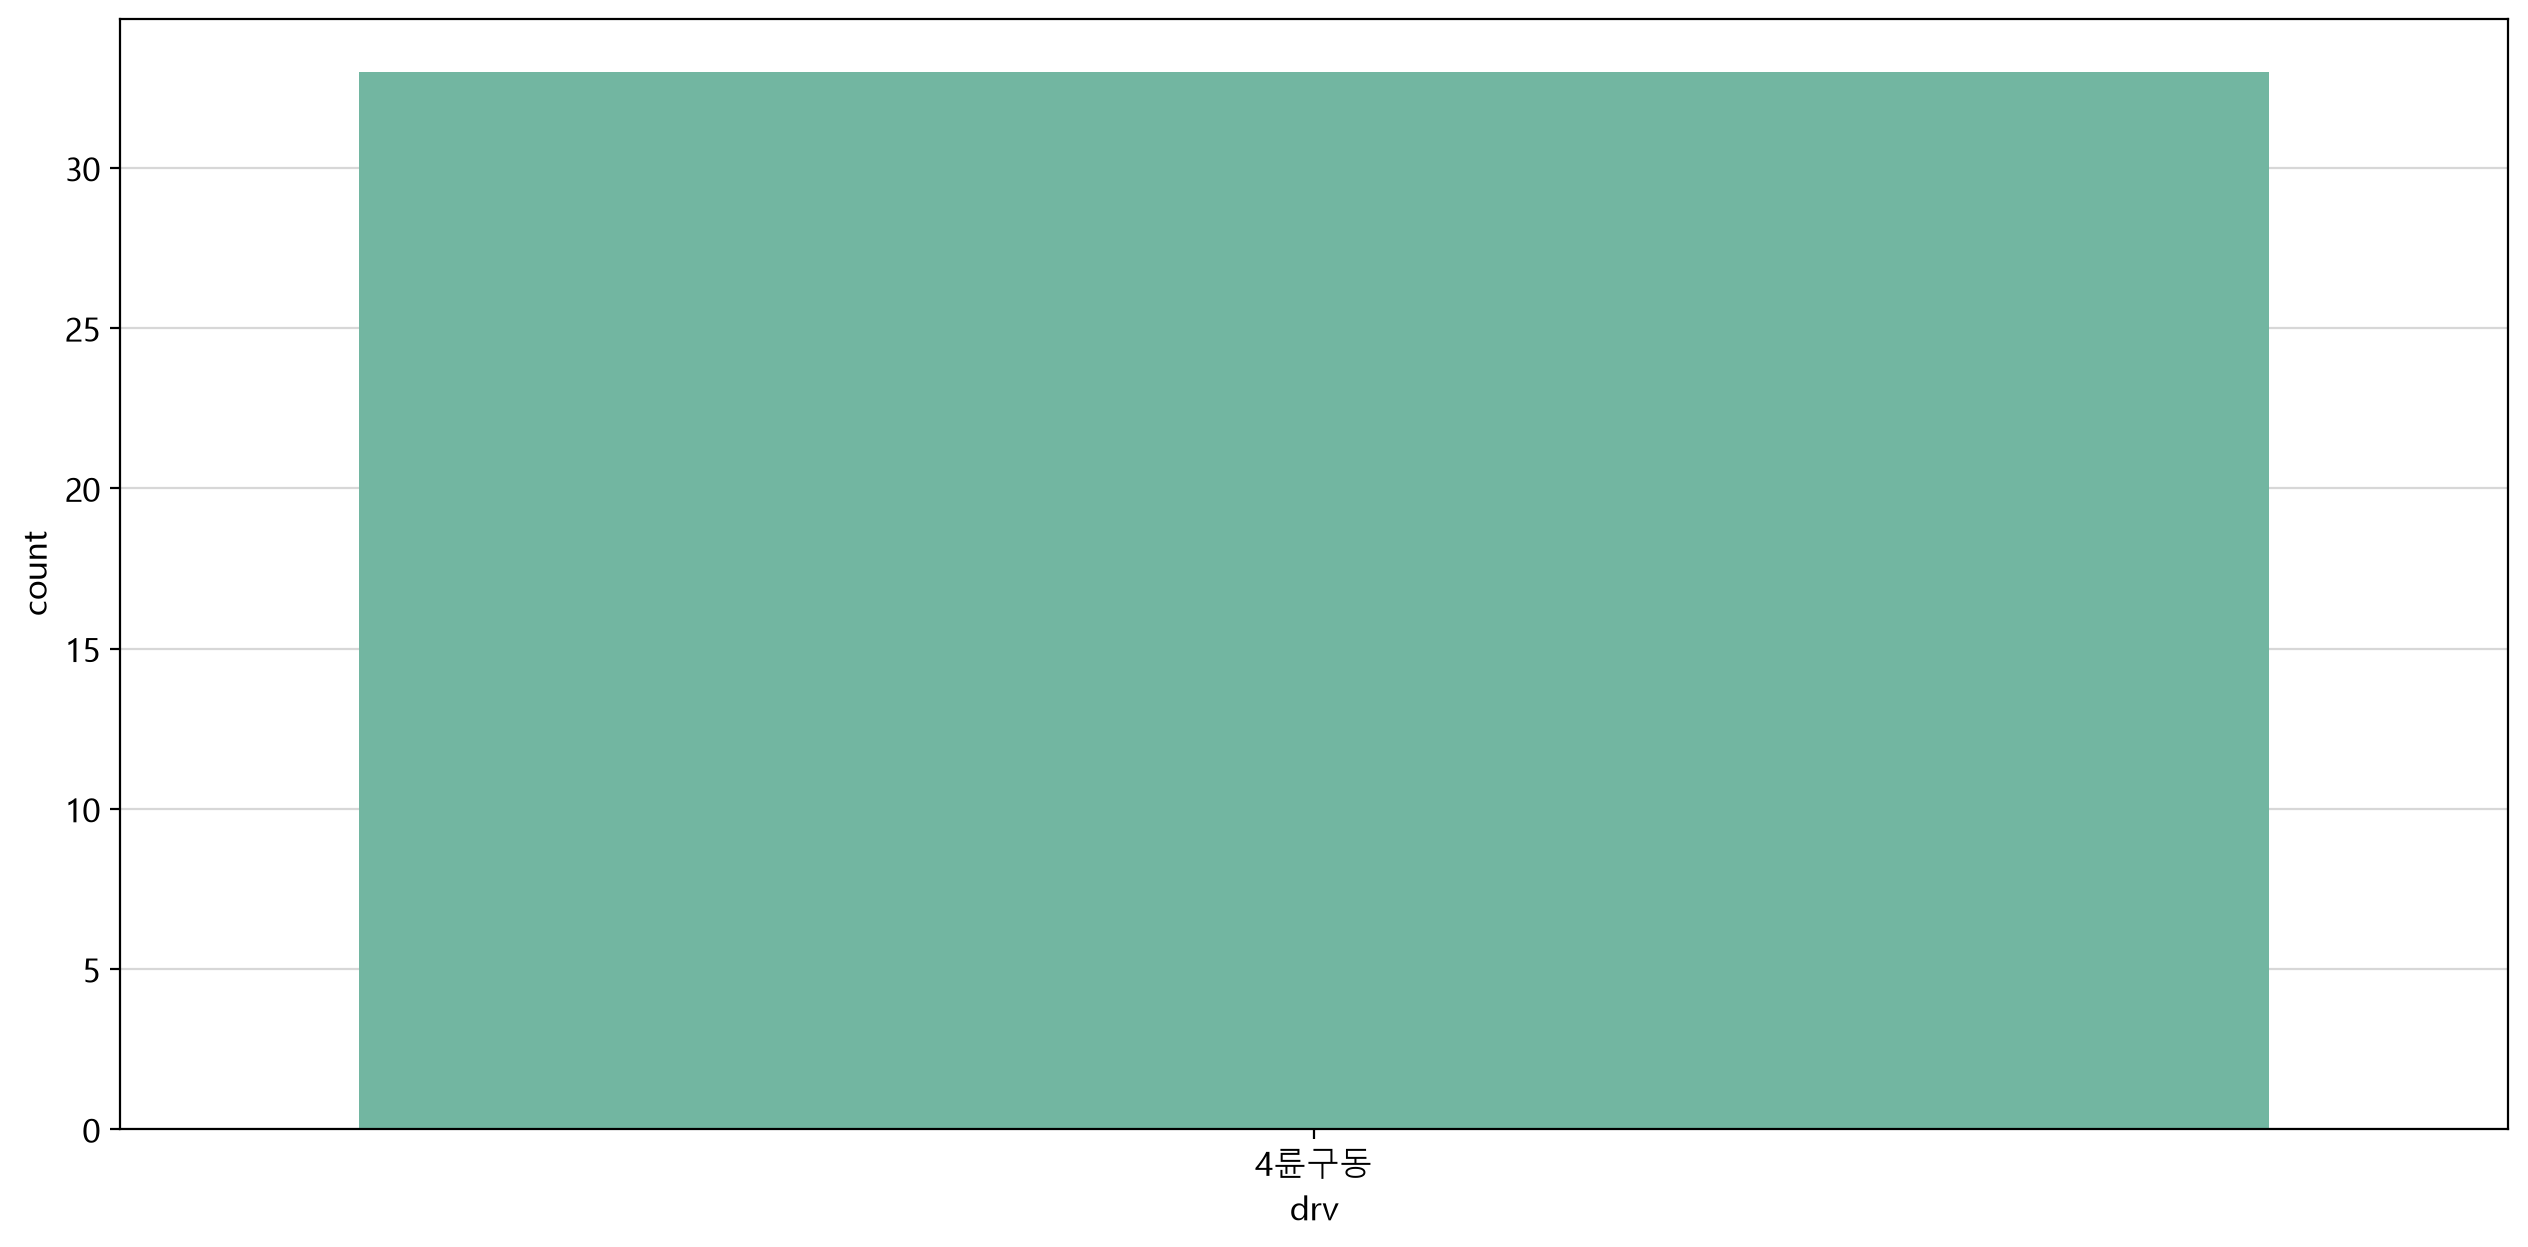

In [191]:
my_plot.countplot(data=df1, x='drv', hue='drv', palette='Set2',
                order=df1['drv'].value_counts().index,
                  ) 

## 문제 17. 평균연비 `(cty + hwy) / 2`가 전체 평균보다 높은(합격, Pass) 차량의 비율에 가장 가까운 값은?

① 약 25%  ② 약 47%  ③ 약 53%  ④ 약 75%

> 💡 **힌트**: 원그래프 (Pass/Fail 비율)

In [ ]:
# 결론
# 로직·정답 모두 정확해요. 다음 두 개만 습관으로 챙기시면 됩니다:

# 경계값(이상/초과) 기준은 문제 의도에 맞게 의식적으로 선택하기
# 후속 분석 가능성이 있는 판정 결과는 원본 df에 컬럼으로 붙여서 관리하기

In [192]:
# 평균연비 (cty+hwy)/2가 전체 평균보다 높은(합격, Pass) 차량의 비율

In [193]:
df1 = (df['cty'] + df['hwy']) /2 
df1

id
1     23.500
2     25.000
3     25.500
4     25.500
5     21.000
       ...  
230   23.500
231   25.000
232   21.000
233   22.000
234   21.500
Length: 234, dtype: float64

In [194]:
overall_mean = df1.mean()
overall_mean

np.float64(20.14957264957265)

In [195]:
df2 = df1 > overall_mean
df2

id
1      True
2      True
3      True
4      True
5      True
       ... 
230    True
231    True
232    True
233    True
234    True
Length: 234, dtype: bool

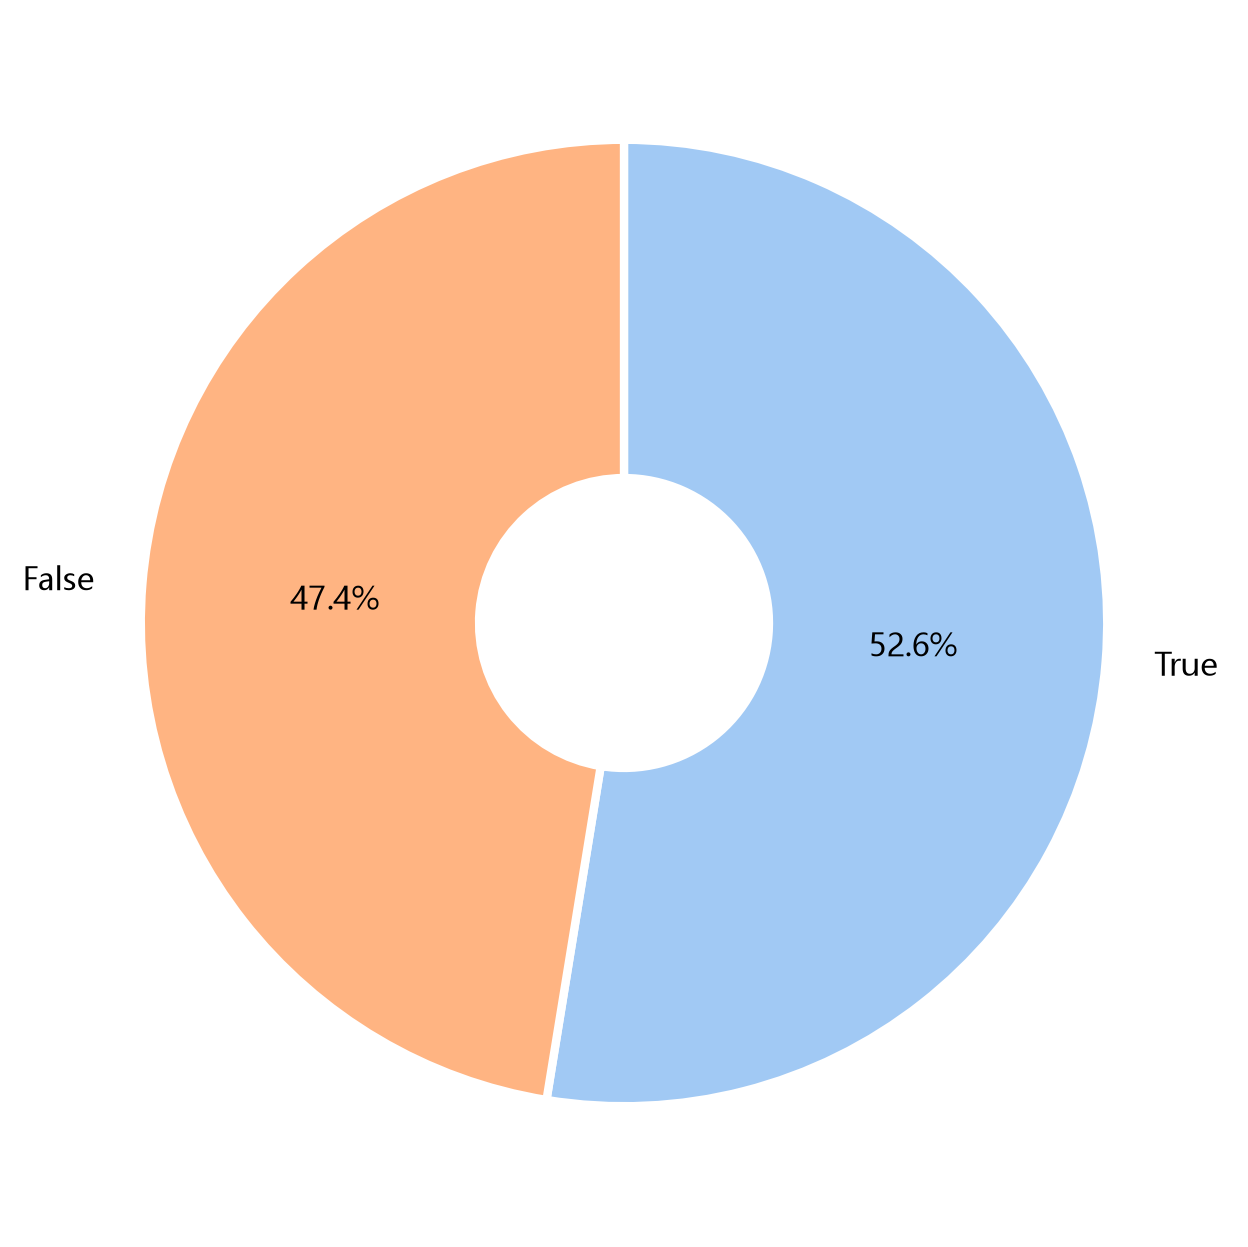

In [196]:
counts = df2.value_counts()  # True/False별 개수

my_plot.pieplot(x=counts, labels=counts.index, palette='pastel',
                donutchart=True, wedge_width=0.7)

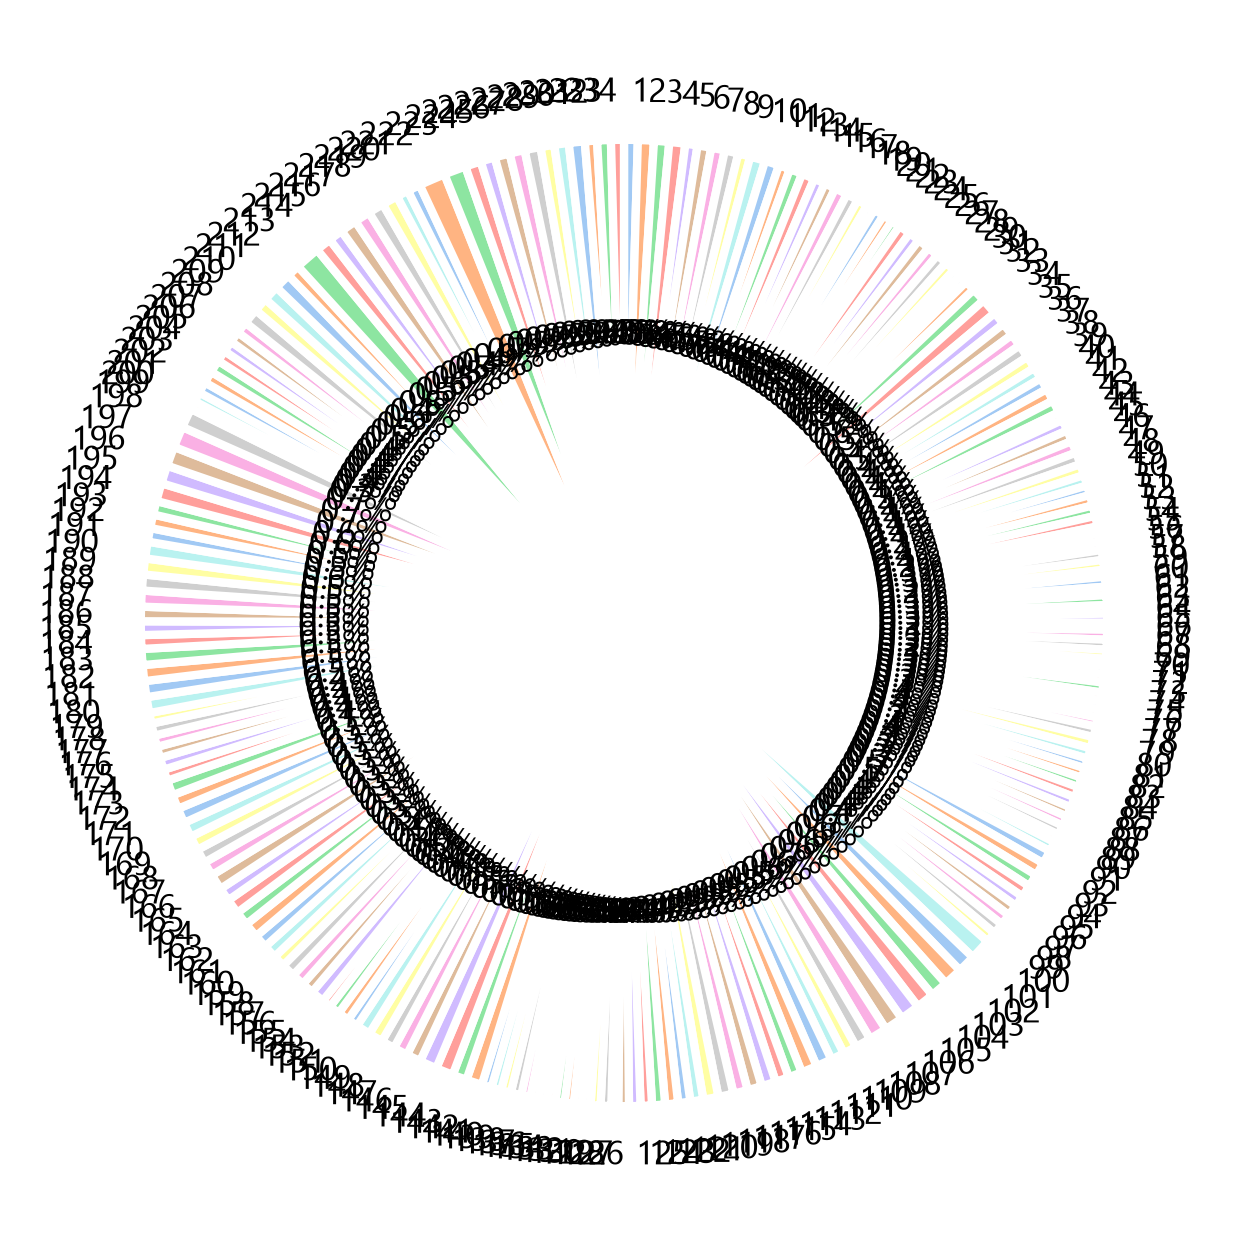

In [197]:
#  원래 목적(Pass/Fail 비율)이랑 상관없는 그래프. cty 값 하나하나를 파이차트로 그리는 거라 234개 조각이 생겨서 못 알아봄
my_plot.pieplot(x=df['cty'], labels=df.index, palette='pastel',
                 donutchart=True, wedge_width=0.7)    

## 문제 18. 배기량(`displ`) 분포의 중앙값(median)에 가장 가까운 값은?

① 2.4  ② 3.3  ③ 3.5  ④ 4.6

> 💡 **힌트**: 히스토그램 또는 박스플롯 (displ 분포)

In [198]:
df['displ'].median()

np.float64(3.3)

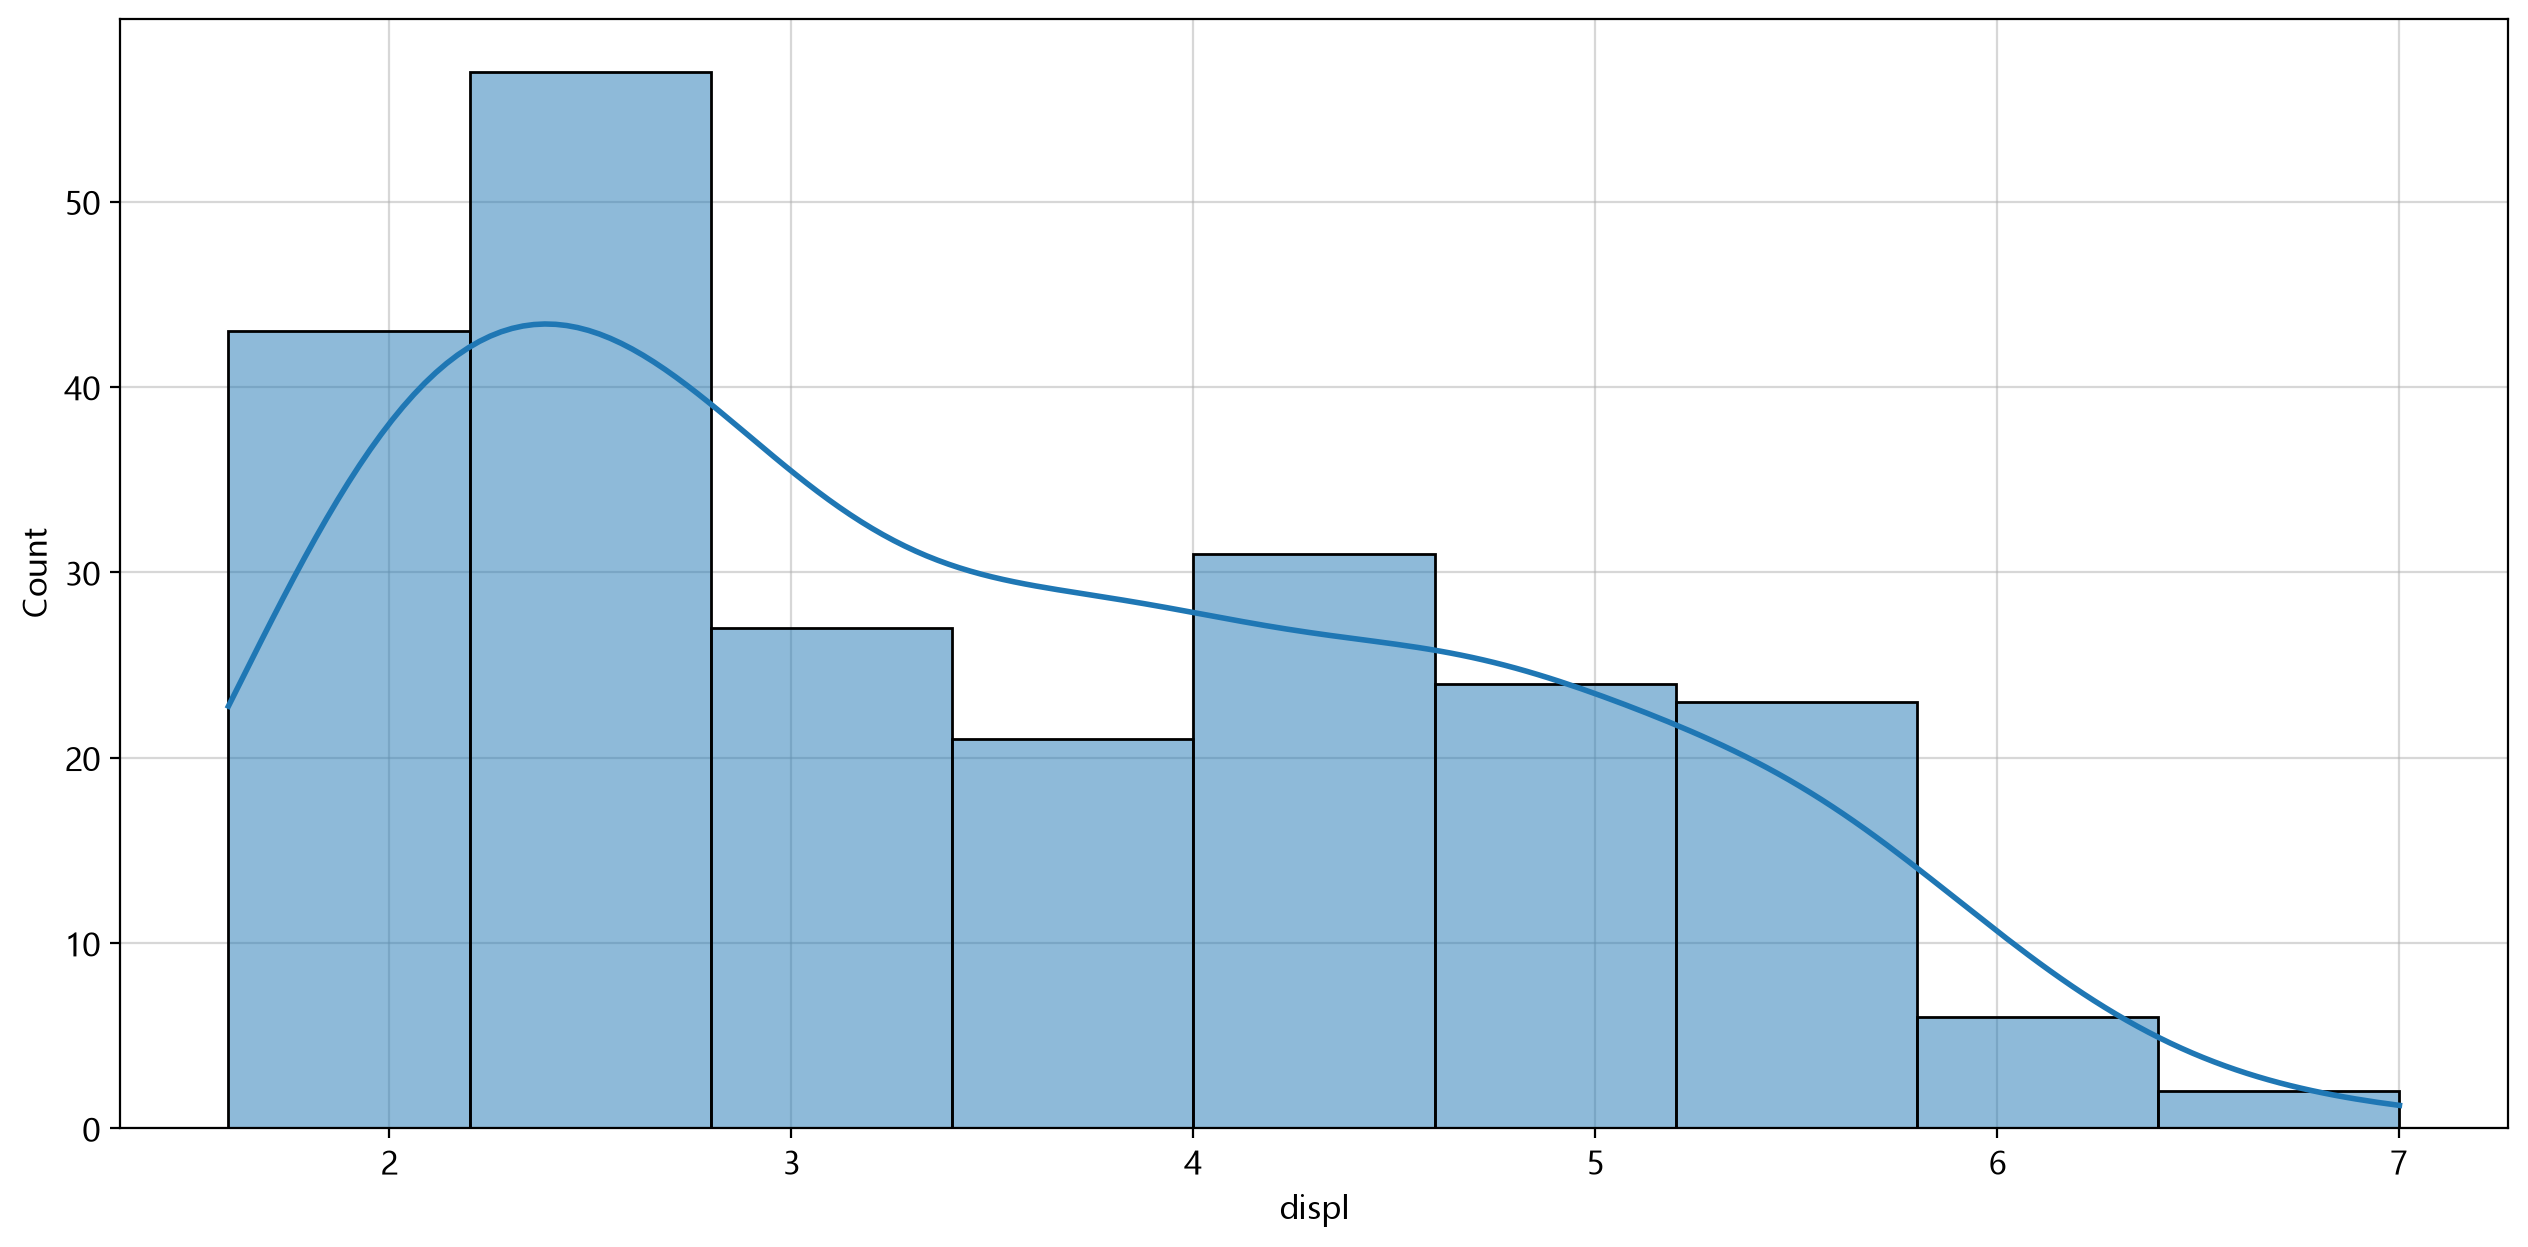

In [199]:
my_plot.histplot(data=df, x="displ", kde=True)

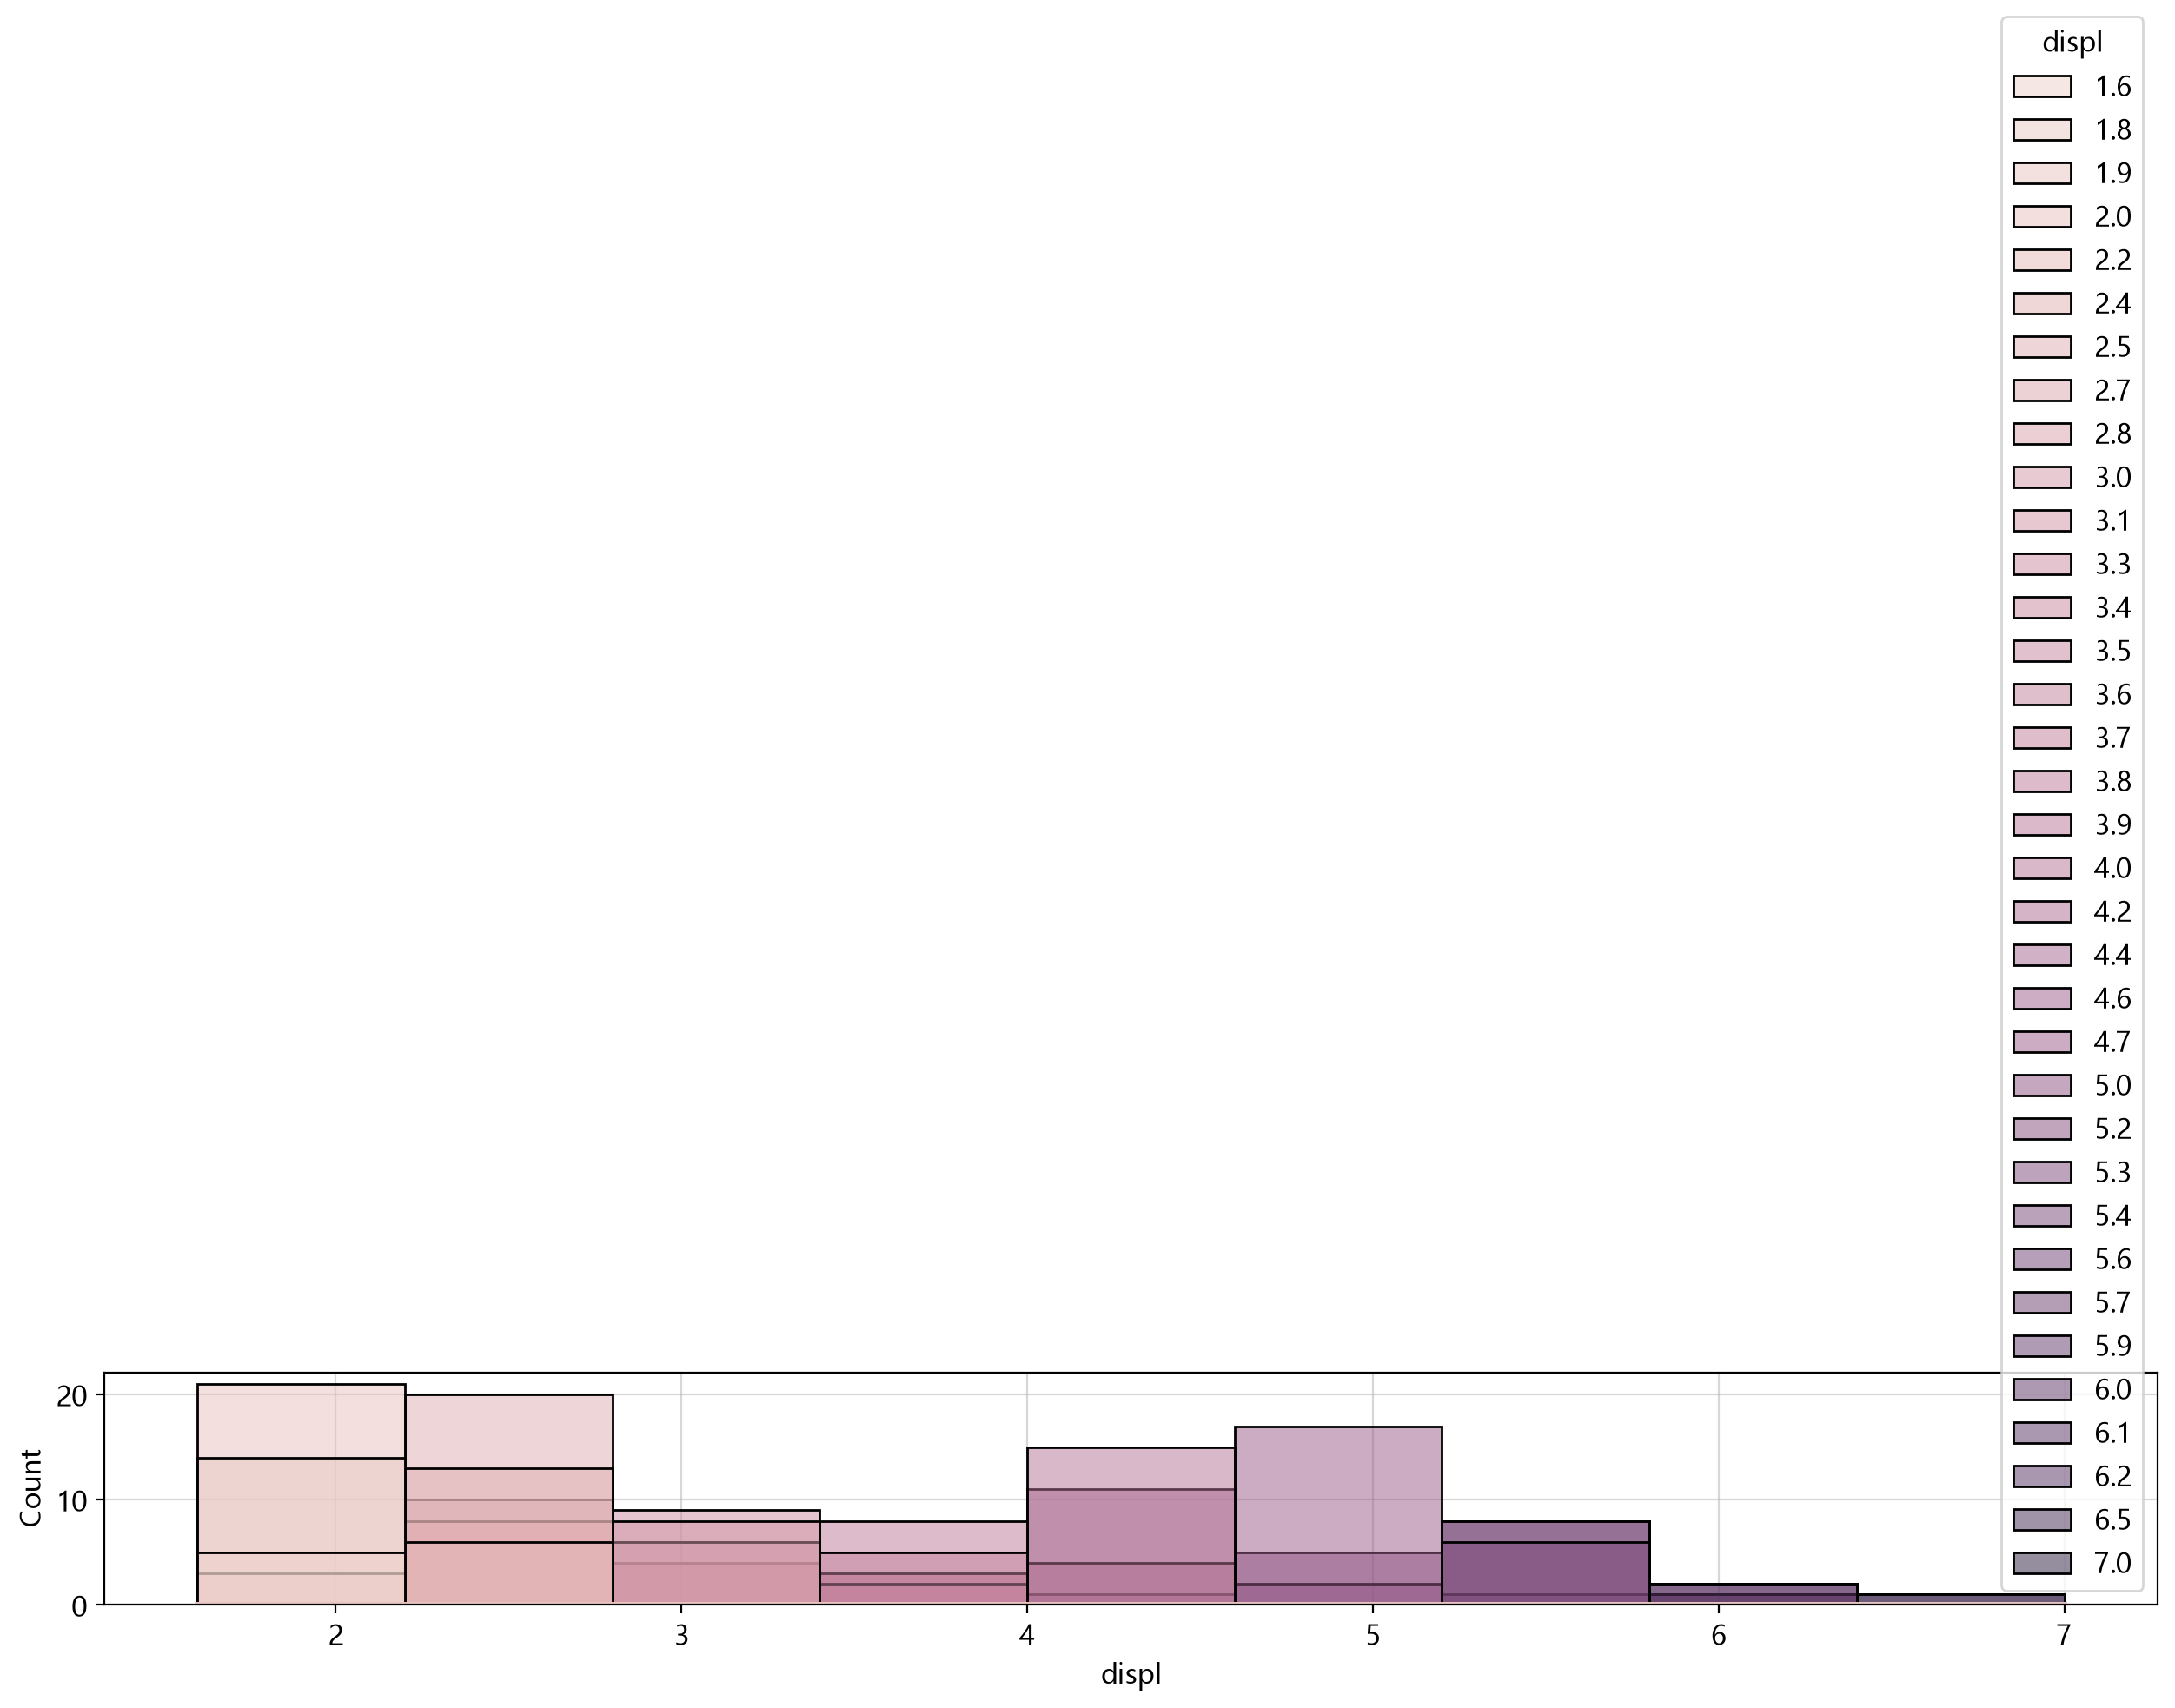

In [200]:
my_plot.histplot(data=df, x="displ", hue="displ", kde=True)

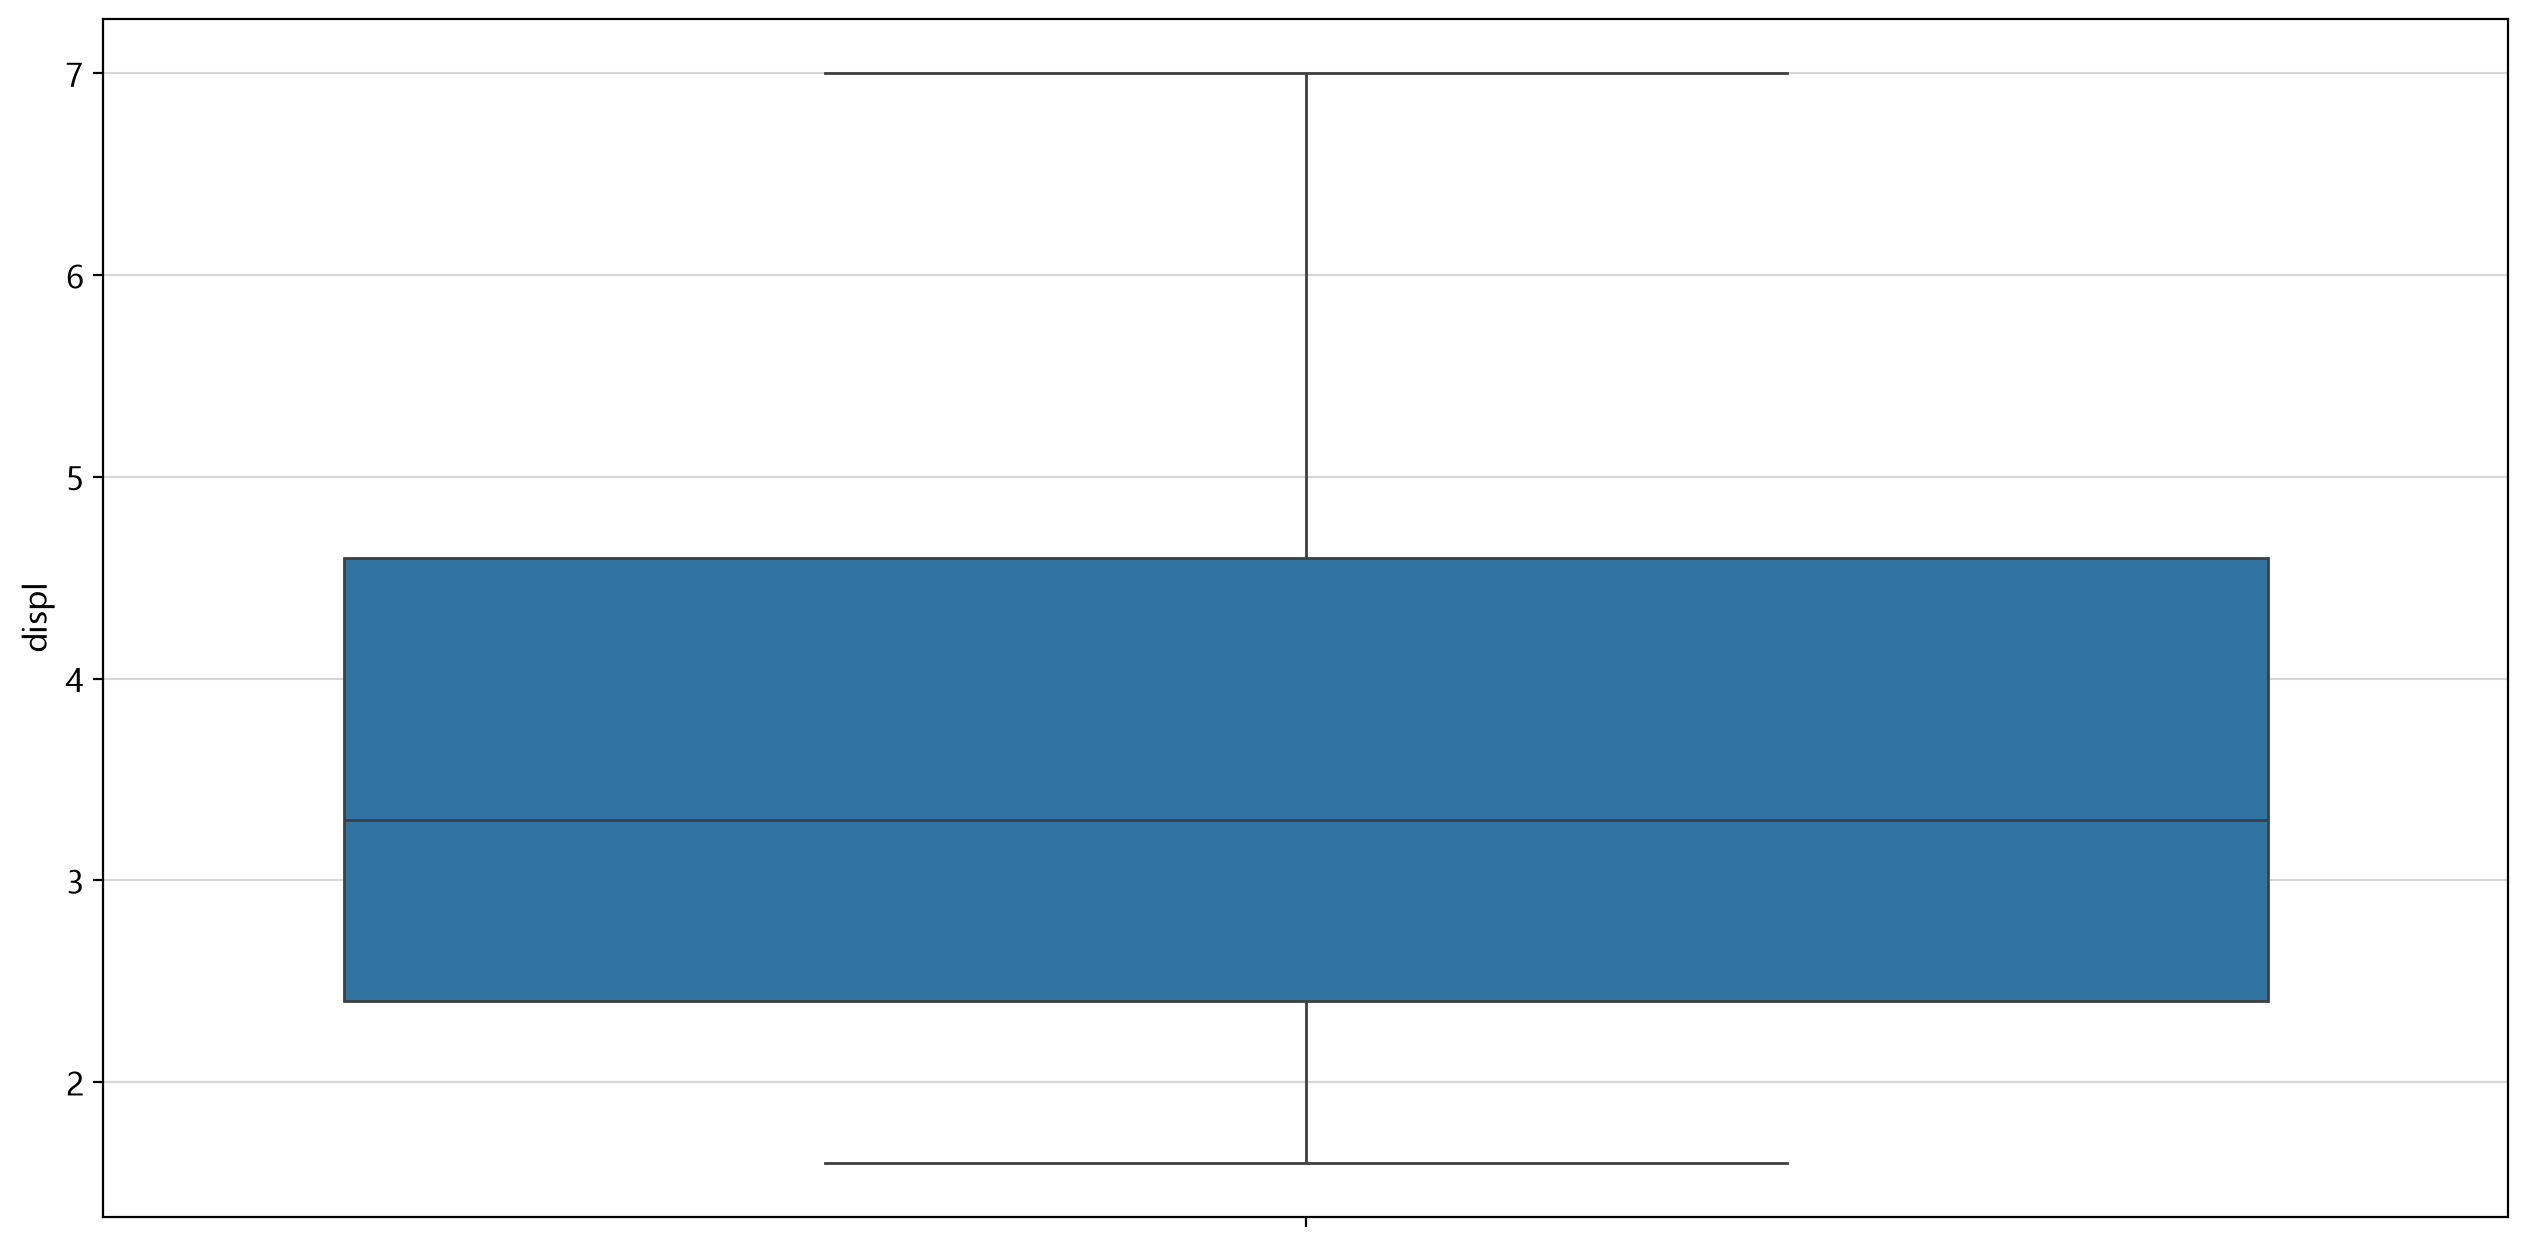

In [201]:
my_plot.boxplot(data=df, y='displ')

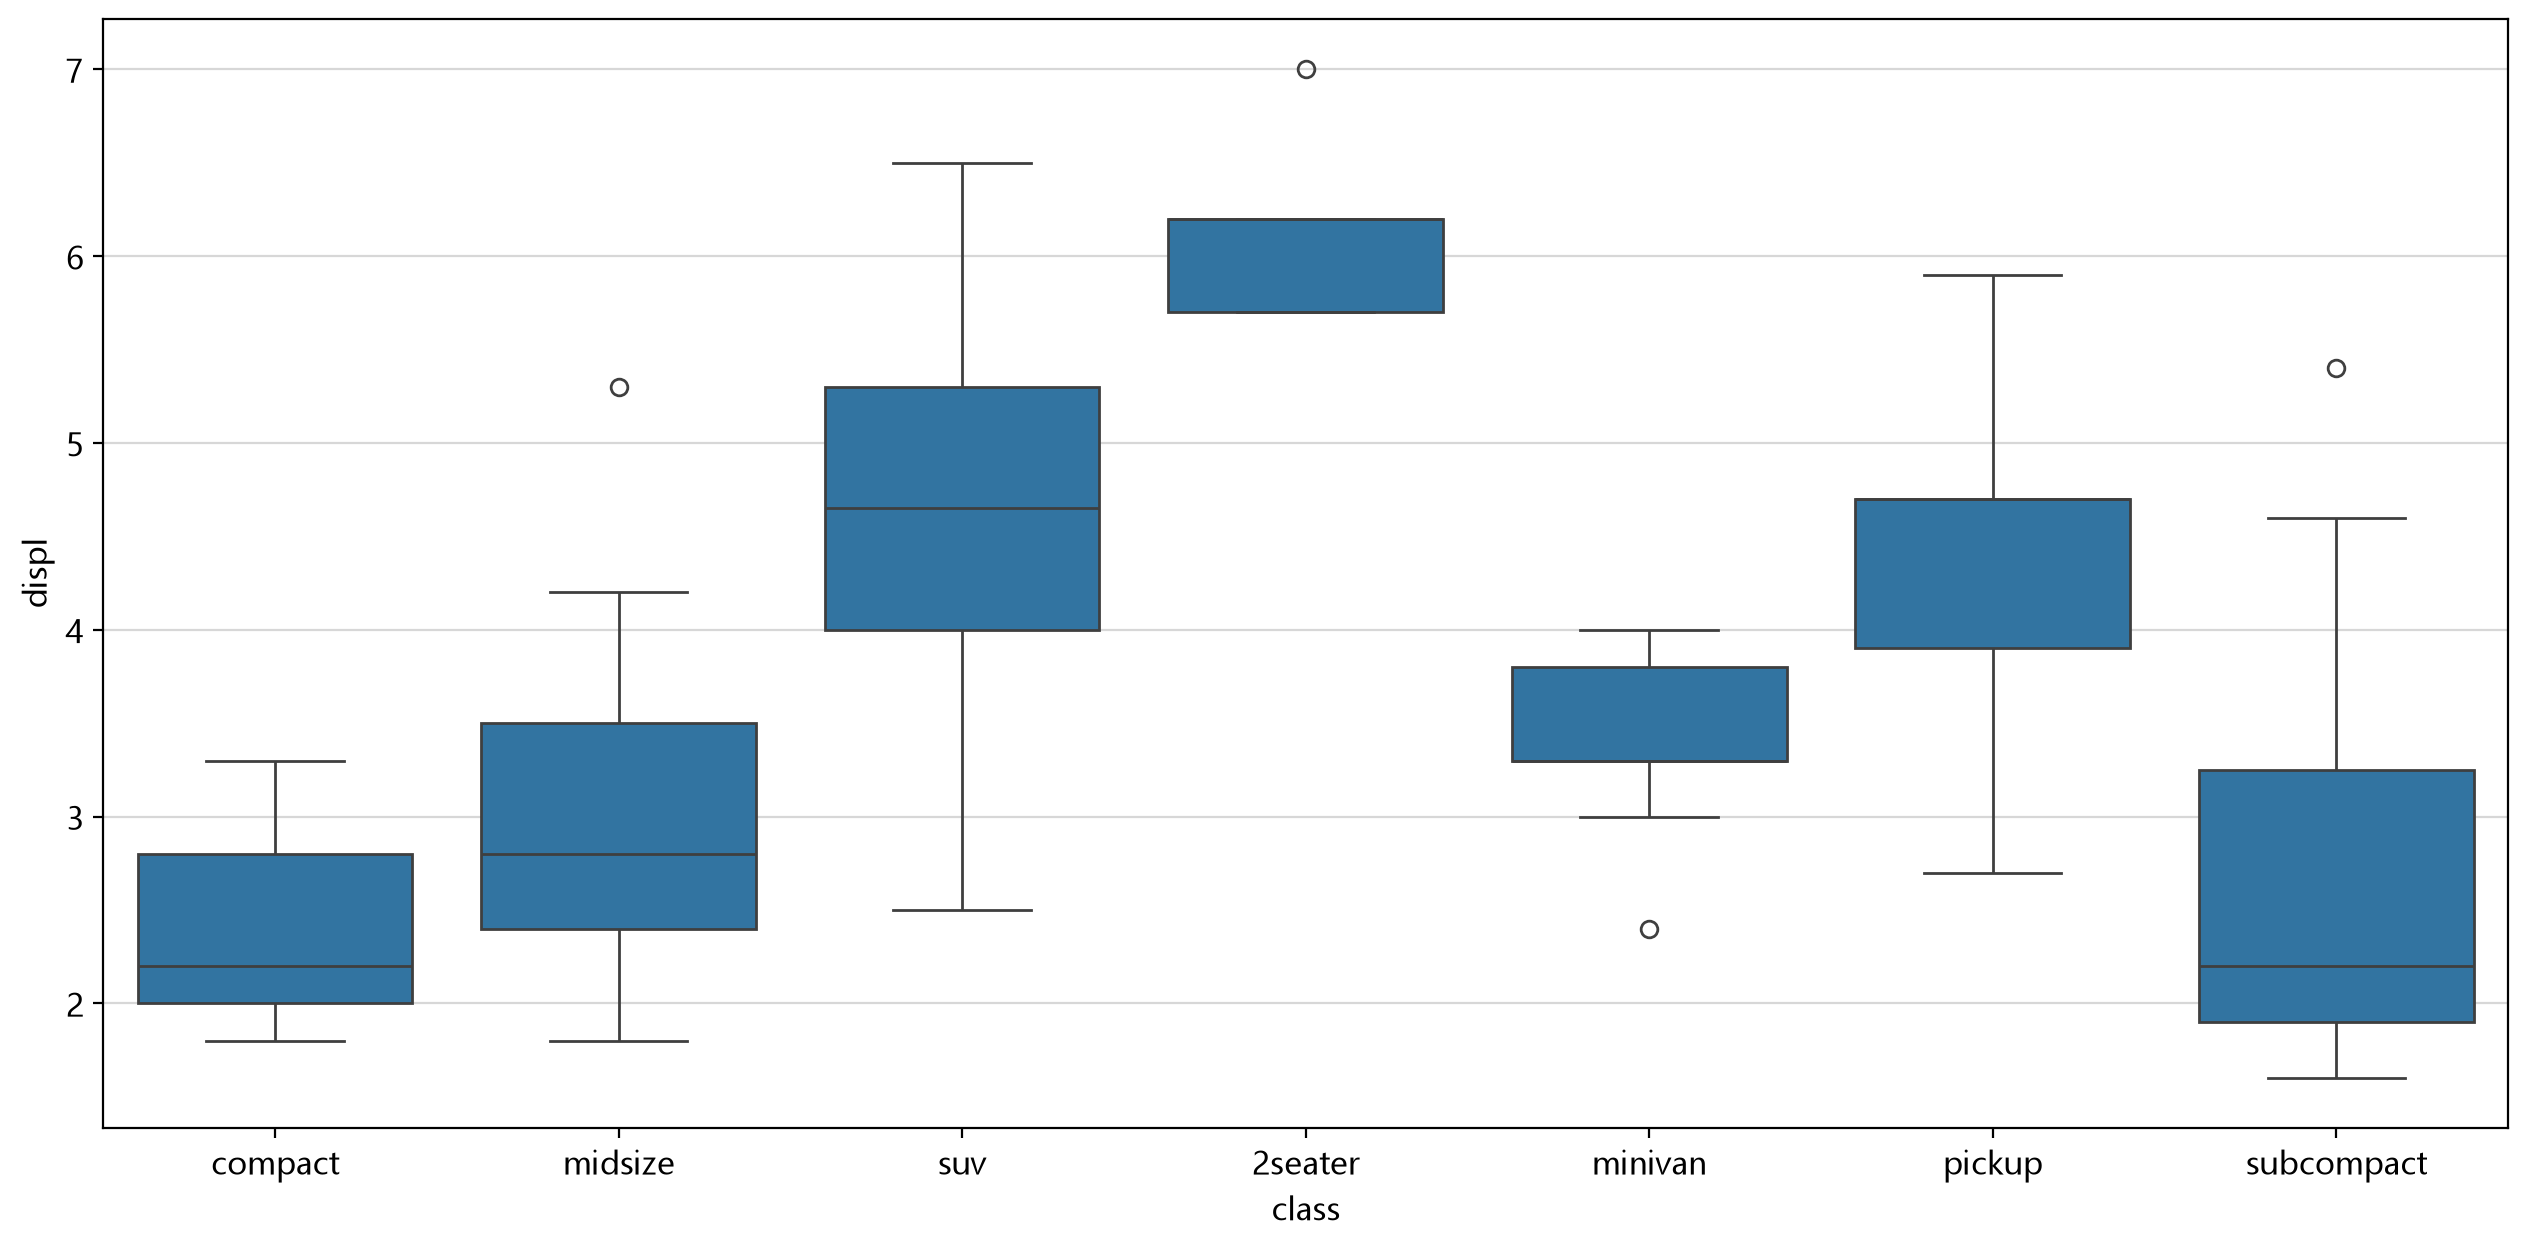

In [202]:
my_plot.boxplot(data=df, x="class", y="displ")

In [203]:
import os
print(os.getcwd())

g:\다른 컴퓨터\내 컴퓨터\15_LAB\[LAB-06] 그래프 기본 구조
